# Graph-Based Relational Learning for Clinical Outcome Prediction in the ICU
### Big Data Analytics and Text Mining | University of Bologna | Hilina Fissha Woreta

The contents of this notebook are organized into the following three sections:

1. I use the eICU database to predict **acute kidney injury (AKI)**: given the first 12 hours of an ICU stay, the model predicts whether the patient will develop new or worsening AKI in the following 48 hours, using a KDIGO creatinine-based label. I also extend this to an **ordinal staging task**, predicting the severity of AKI across three KDIGO stages, and run an **ablation removing the `apachePatientResult` table**, whose severity score is computed over the first 24 hours and therefore extends beyond the 12-hour observation window.

2. Still on eICU, I predict **vasopressor initiation**: given the first 6 hours, the model predicts whether the patient will require a vasopressor in the next 12 hours. I also run a subgroup analysis examining model performance across age groups, ICU unit types, and admission categories.

3. I switch to MIMIC-IV to predict **ICD discharge codes** as a multi-label classification task over the 50 most common codes. The main model predicts at **admission time**, using only the information available when the patient arrives plus their prior hospitalization history; I then run an experiment extending the observation window to **discharge time** to measure how much the in-stay data adds. I also run two further ablations, one scaling the label space from top-50 to top-100 and top-200 codes, and one reframing the task as single-label principal diagnosis prediction.

All three tasks use the same HeteroGraphSAGE architecture from RelBench, treating each clinical database as a heterogeneous graph where tables are node types and foreign-key relationships are edges.

**Running this notebook:** the only paths that need changing are `EICU_DIR` and `MIMIC_DIR` in the configuration cell below. 

## Setting up the required dependencies


In [1]:
import os, sys, subprocess
def run(cmd): subprocess.run(cmd, shell=True, check=False)

def check_gpu():
    if os.path.exists('/dev/nvidia0'): return True
    if os.environ.get('COLAB_GPU', '') not in ('', '0'): return True
    return subprocess.run('/usr/bin/nvidia-smi', shell=True, capture_output=True).returncode == 0

has_gpu = check_gpu()
print('gpu found:', has_gpu)

run('pip uninstall -y torch torchvision torchaudio torchcodec')

if has_gpu:
    run('pip install -q torch==2.5.1 torchvision==0.20.1 '
        '--index-url https://download.pytorch.org/whl/cu124')
    run('pip install -q pyg-lib torch-scatter torch-sparse torch-cluster '
        'torch-spline-conv -f https://data.pyg.org/whl/torch-2.5.1+cu124.html')
else:
    run('pip install -q torch==2.5.1 torchvision==0.20.1 '
        '--index-url https://download.pytorch.org/whl/cpu')
    run('pip install -q torch-scatter torch-sparse torch-cluster '
        'torch-spline-conv -f https://data.pyg.org/whl/torch-2.5.1+cpu.html')

run('pip install -q torch-geometric')
run('pip install -q relbench[full]')
run('pip install -q sentence-transformers')

print('All packages installed')


gpu found: True
Found existing installation: torch 2.5.1+cu124
Uninstalling torch-2.5.1+cu124:
  Successfully uninstalled torch-2.5.1+cu124
Found existing installation: torchvision 0.20.1+cu124
Uninstalling torchvision-0.20.1+cu124:
  Successfully uninstalled torchvision-0.20.1+cu124


All packages installed


In [2]:
import torch, torchvision
print('torch', torch.__version__, '| torchvision', torchvision.__version__)
assert torch.__version__.startswith('2.5.1')

torch 2.5.1+cu124 | torchvision 0.20.1+cu124


## Importing Necessary Libraries

In [3]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import copy, math, warnings, shutil
import random, numpy as np, torch
import pandas as pd
import duckdb

import torch.nn as nn
from collections import Counter
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, brier_score_loss,
    confusion_matrix, precision_recall_curve
)
from tqdm import tqdm

from relbench.base import Database, Dataset, Table, TaskType
from relbench.base.task_entity import EntityTask
from relbench.metrics import roc_auc, average_precision, accuracy, f1
from relbench.modeling.graph import make_pkey_fkey_graph, get_node_train_table_input
from relbench.modeling.utils import get_stype_proposal
from relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder
from torch_geometric.data import HeteroData
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MLP
from torch_geometric.seed import seed_everything
from torch_frame import stype
from torch_frame.config.text_embedder import TextEmbedderConfig
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

def make_reproducible(seed: int = 42) -> None:
    
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.default_generator.manual_seed(seed)
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    seed_everything(seed)

make_reproducible(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cpu":
    print("GPU not detected")
else:
    print(f"Device: {device}  ({torch.cuda.get_device_name(0)})")

Device: cuda  (Tesla T4)


### Note on data access and credentialing time

Both datasets are hosted on PhysioNet and require credentialed access, so
anyone reproducing this work needs to go through the same process. Reporting
the timeline here since it affects how far in advance the data has to be
requested.

The process was the same for both datasets: create a PhysioNet account,
complete the required human-subjects research training, and submit a
credentialing application listing a supervisor as reference, who is then
contacted directly. Each dataset also requires signing its own data use
agreement. In my case the training took about two to three days to complete,
and the full process from starting the application to having access to the
files took roughly **two weeks**, most of which was waiting for the
credentialing review and the supervisor reference to be processed.

Both datasets were requested as part of the same application, so I did not
observe a meaningful difference in waiting time between eICU and MIMIC-IV,
the bottleneck was the one-time credentialing review rather than the
individual dataset approvals. Practically, this means the two-week lead time
should be planned for at the start of a project like this.

### Data provenance and reproducibility

Both datasets were downloaded directly from PhysioNet under credentialed
access. The exact versions used are:

- **eICU Collaborative Research Database v2.0** (published 15 April 2019).
  Pollard T., Johnson A., Raffa J., Celi L.A., Badawi O., Mark R.
- **MIMIC-IV v3.1** (published 11 October 2024). Johnson A., Bulgarelli L.,
  Pollard T., Gow B., Moody B., Horng S., Celi L.A., Mark R.

The files are the original PhysioNet distributions, decompressed from
`.csv.gz` and otherwise unmodified. Apart from decompression, no
preprocessing or filtering was applied before use — every transformation
described in this notebook happens at load time inside the dataset classes,
so the pipeline is reproducible from the raw PhysioNet files.

**Files used.** From eICU: `patient`, `apachePatientResult`, `diagnosis`,
`treatment`, `medication`, `lab`, `vitalPeriodic`, `vitalAperiodic`,
`intakeOutput`, `nurseCharting`, `admissionDrug`, `respiratoryCare`, and
`infusionDrug` (used only to build the vasopressor labels, never part of the
graph). From MIMIC-IV: `patients`, `admissions`, `transfers`, `icustays`,
`procedureevents`, `labevents`, `diagnoses_icd`, `d_icd_diagnoses`,
`d_items`, `d_labitems`.

**Note on `discharge.csv`.** The MIMIC-IV discharge summaries are present in
the data folder but are deliberately **not** loaded anywhere in this notebook.
Discharge summaries state the patient's diagnoses in free text, so using them
in the ICD task would be direct label leakage. The table is absent from
`MimicDataset.file_names` and therefore never enters the graph.

**Paths.** All tables are plain CSV files in a single directory per dataset.
Both locations are set once near the top of the notebook, in `EICU_DIR` and
`MIMIC_DIR`; to run the notebook elsewhere, change those two lines and nothing
else needs to be modified. Under the PhysioNet data use agreement, these files
cannot be redistributed publicly and can only be shared privately between
credentialed users.

## Overview of the eICU and MIMIC-IV Datasets

**eICU Collaborative Research Database** is a multi-centre ICU database assembled by Philips Healthcare and made available through PhysioNet. It covers approximately 200,000 ICU admissions across 208 hospitals in the United States, collected between 2014 and 2015. Because it spans many sites with different care protocols, it provides a diverse and realistic picture of critical care practice.

**MIMIC-IV** (Medical Information Mart for Intensive Care, version IV) is a single-centre database from Beth Israel Deaconess Medical Center in Boston, available on PhysioNet under a data use agreement. It contains over 300,000 hospital admissions and roughly 70,000 ICU stays spanning 2008 to 2022, making it one of the richest sources of longitudinal clinical data available for research.

Before we proceed to the implementation of the tasks, let's examine the distributional properties of both datasets to understand what we are working with.

In [ ]:
# Change these two paths to point at your local copies of the CSVs.
EICU_DIR  = '/kaggle/input/datasets/hilinafissha16/e-icu-data'
MIMIC_DIR = '/kaggle/input/datasets/hilinafissha16/mimic-iv'

In [3]:
import pandas as pd
import os

eicu_dir = EICU_DIR
mimic_dir = MIMIC_DIR

tables = {
    'eICU - patient': os.path.join(eicu_dir, 'patient.csv'),
    'eICU - lab': os.path.join(eicu_dir, 'lab.csv'),
    'eICU - medication': os.path.join(eicu_dir, 'medication.csv'),
    'eICU - diagnosis': os.path.join(eicu_dir, 'diagnosis.csv'),
    'eICU - treatment': os.path.join(eicu_dir, 'treatment.csv'),
    'MIMIC - admissions': os.path.join(mimic_dir, 'admissions.csv'),
    'MIMIC - patients': os.path.join(mimic_dir, 'patients.csv'),
    'MIMIC - labevents': os.path.join(mimic_dir, 'labevents.csv'),
    'MIMIC - icustays': os.path.join(mimic_dir, 'icustays.csv'),
    'MIMIC - diagnoses_icd': os.path.join(mimic_dir, 'diagnoses_icd.csv'),
}

for name, path in tables.items():
    if not os.path.exists(path):
        print(f"{name}: FILE NOT FOUND")
        continue
    df = pd.read_csv(path, nrows=2)
    print(f"\n{name} ({len(df.columns)} columns)")
    for col in df.columns:
        vals = ' | '.join(str(v)[:40] for v in df[col].tolist())
        print(f"  {col}: {vals}")


eICU - patient (29 columns)
  patientunitstayid: 141168 | 141178
  patienthealthsystemstayid: 128919 | 128927
  gender: Female | Female
  age: 70 | 52
  ethnicity: Caucasian | Caucasian
  hospitalid: 59 | 60
  wardid: 91 | 83
  apacheadmissiondx: Rhythm disturbance (atrial, supraventric | nan
  admissionheight: 152.4 | 162.6
  hospitaladmittime24: 15:54:00 | 08:56:00
  hospitaladmitoffset: 0 | -14
  hospitaladmitsource: Direct Admit | Emergency Department
  hospitaldischargeyear: 2015 | 2015
  hospitaldischargetime24: 03:50:00 | 19:20:00
  hospitaldischargeoffset: 3596 | 2050
  hospitaldischargelocation: Death | Home
  hospitaldischargestatus: Expired | Alive
  unittype: Med-Surg ICU | Med-Surg ICU
  unitadmittime24: 15:54:00 | 09:10:00
  unitadmitsource: Direct Admit | Emergency Department
  unitvisitnumber: 1 | 1
  unitstaytype: admit | admit
  admissionweight: 84.3 | 54.4
  dischargeweight: 85.8 | 54.4
  unitdischargetime24: 03:50:00 | 09:18:00
  unitdischargeoffset: 3596 | 8
  uni

In [4]:
import os, glob, subprocess
import pandas as pd
import numpy as np
import duckdb

eicu_dir = EICU_DIR
mimic_dir = MIMIC_DIR

def build_path_dict(directory):
    paths = {}
    for p in glob.glob(os.path.join(directory, '*.csv')) + glob.glob(os.path.join(directory, '*', '*.csv')):
        stem = os.path.basename(p).replace('.csv', '').lower()
        paths[stem] = p
    return paths

eicu_paths = build_path_dict(eicu_dir)
mimic_paths = build_path_dict(mimic_dir)

pat = pd.read_csv(os.path.join(eicu_dir, 'patient.csv'),
                  usecols=lambda c: c.lower() in {
                      'uniquepid','patientunitstayid','hospitalid','hospitaladmityear',
                      'unitdischargeoffset','age','gender','hospitaldischargestatus'})
pat.columns = [c.lower() for c in pat.columns]

adm = pd.read_csv(os.path.join(mimic_dir, 'admissions.csv'),
                  usecols=['subject_id','hadm_id','admittime','dischtime','hospital_expire_flag'])
adm['admittime'] = pd.to_datetime(adm['admittime'])
adm['dischtime']  = pd.to_datetime(adm['dischtime'])

icu_path = os.path.join(mimic_dir, 'icustays.csv')
icu = pd.read_csv(icu_path, usecols=['stay_id','los']) if os.path.exists(icu_path) else None

eicu_years = (f"{int(pat['hospitaladmityear'].min())}-{int(pat['hospitaladmityear'].max())}"
              if 'hospitaladmityear' in pat.columns else '2014-2015')
mimic_years = f"{adm['admittime'].dt.year.min()}-{adm['admittime'].dt.year.max()}"

print("Dataset overview:")
print(f"  eICU  - {pat['patientunitstayid'].nunique():,} stays, {pat['uniquepid'].nunique():,} patients, 208 hospitals, {eicu_years}")
print(f"  MIMIC - {adm['hadm_id'].nunique():,} admissions, {adm['subject_id'].nunique():,} patients, 1 hospital, {mimic_years}")
print()
print("Time format:")
print("  eICU uses minute offsets from ICU admission (no real dates)")
print("  MIMIC-IV uses real timestamps")

Dataset overview:
  eICU  - 200,859 stays, 139,367 patients, 208 hospitals, 2014-2015
  MIMIC - 546,028 admissions, 223,452 patients, 1 hospital, 2105-2214

Time format:
  eICU uses minute offsets from ICU admission (no real dates)
  MIMIC-IV uses real timestamps


From the above two cells' outputs, we can see that the eICU dataset does not store real calendar dates at all. Instead, every event is recorded as an offset in minutes relative to ICU admission time. Looking at the raw values, fields such as `unitdischargeoffset` are simply integers; for example, a value of `720` means the event happened 12 hours after ICU admission. The only real temporal information preserved is the admission year stored in `hospitaladmityear` (2014–2015).

MIMIC-IV handles timestamps differently. It stores full datetime values, but the dates are shifted by several years for de-identification purposes. This is why timestamps in the dataset appear with years like `2150–2214`. These are not the actual collection years, the real data covers **2008–2022**, which can be inferred from the `anchor_year_group` column in `patients.csv`. Although the dates are shifted, the relative timing between events remains accurate, so feature engineering and train/validation/test splits are still reliable. We can see in the next cell how the temporal span is handled in both datasets.

In [5]:
print("eICU  unitdischargeoffset (first 10 values, in minutes since ICU admission):")
print(pat['unitdischargeoffset'].head(10).tolist())
print()
print("MIMIC-IV  admittime (first 5 values):")
print(adm['admittime'].head(5).tolist())

eICU  unitdischargeoffset (first 10 values, in minutes since ICU admission):
[3596, 8, 2042, 4813, 1463, 74, 1869, 720, 1652, 166]

MIMIC-IV  admittime (first 5 values):
[Timestamp('2180-05-06 22:23:00'), Timestamp('2180-06-26 18:27:00'), Timestamp('2180-08-05 23:44:00'), Timestamp('2180-07-23 12:35:00'), Timestamp('2160-03-03 23:16:00')]


In [6]:
def age_to_float(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    if '>' in s: return 90.0
    try: return float(s)
    except: return np.nan

def count_rows(path):
    try:
        con = duckdb.connect()
        n = con.execute(f"SELECT COUNT(*) FROM read_csv_auto('{path}')").fetchone()[0]
        con.close()
        return int(n)
    except:
        return None

eicu_los = pat['unitdischargeoffset'] / 60
eicu_age = pat['age'].apply(age_to_float) if 'age' in pat.columns else pd.Series(dtype=float)
eicu_mort = (pat['hospitaldischargestatus'].str.lower()=='expired').mean()*100 if 'hospitaldischargestatus' in pat.columns else None

mimic_mort = adm['hospital_expire_flag'].mean() * 100
pts = pd.read_csv(os.path.join(mimic_dir, 'patients.csv'), usecols=['subject_id','gender','anchor_age'])
mimic_age = pts['anchor_age']
mimic_los = icu['los'] * 24 if icu is not None else (adm['dischtime'] - adm['admittime']).dt.total_seconds() / 3600

print("Patient statistics:")
print(f"  Median age       - eICU: {eicu_age.median():.0f} yrs  |  MIMIC-IV: {mimic_age.median():.0f} yrs")
print(f"  Mortality        - eICU: {eicu_mort:.1f}%  |  MIMIC-IV: {mimic_mort:.1f}%")
print(f"  Median LOS (hrs) - eICU: {eicu_los.median():.1f}  |  MIMIC-IV: {mimic_los.median():.1f}")
print()

print("MIMIC-IV table sizes:")
for t in ['labevents','icustays','transfers','procedureevents','diagnoses_icd']:
    path = mimic_paths.get(t)
    cnt = count_rows(path) if path else None
    if cnt: print(f"  {t}: {cnt:,}")

Patient statistics:
  Median age       - eICU: 65 yrs  |  MIMIC-IV: 48 yrs
  Mortality        - eICU: 9.0%  |  MIMIC-IV: 2.2%
  Median LOS (hrs) - eICU: 37.8  |  MIMIC-IV: 47.2

MIMIC-IV table sizes:


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  labevents: 158,374,764
  icustays: 94,458
  transfers: 2,413,581
  procedureevents: 808,706
  diagnoses_icd: 6,364,488


### Main differences between the databases

- **eICU** is a multi-centre dataset collected from 208 hospitals, while **MIMIC-IV** comes from a single academic medical centre.
- Patients in eICU are generally older (median age 65 vs 48) and have higher in-hospital mortality rates (9% vs 2.2%)
- Hospital stays in MIMIC-IV tend to be longer overall, with more admissions lasting 1–3 days and a larger number of stays extending beyond 14 days.

**And another thing to notice is**  
eICU contains 31 tables on PhysioNet, while MIMIC-IV has 30+ tables. The numbers mentioned above **only** refer to the subset of tables included in the notebook.


In [7]:
import gc

for v in ['pat', 'adm', 'icu', 'pts', 'eicu_paths', 'mimic_paths',
          'eicu_los', 'eicu_age', 'eicu_gender', 'mimic_age', 'mimic_gender', 'mimic_los']:
    if v in globals():
        del globals()[v]

gc.collect()

315

## Building the shared text embedder

Several columns in both databases contain free-text values like drug names, diagnosis strings, lab test names, and nursing notes, etc. To include these as features, I need to turn each string into a numeric vector.

I use a **GloVe word-vector model** (`average_word_embeddings_glove.6B.300d` via sentence-transformers). GloVe works by averaging pre-trained word vectors, which makes it very fast and processes a string in microseconds regardless of length. The output is a 300-dimensional vector per string.

This embedder is defined once here and reused unchanged across all three tasks.

In [3]:
class GloveTextEmbedding:
    def __init__(self):
        self.model = SentenceTransformer("average_word_embeddings_glove.6B.300d")
    def __call__(self, sentences):
        return self.model.encode(
            sentences, show_progress_bar=False,
            convert_to_tensor=True, device="cpu")

text_embedder_cfg = TextEmbedderConfig(
    text_embedder=GloveTextEmbedding(), batch_size=256)

modules.json:   0%|          | 0.00/248 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

wordembedding_config.json:   0%|          | 0.00/164 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Data Filtering and Sampling Choices (eICU)

Since eICU contains 31 tables and hundreds of millions of rows, I had to make
several filtering choices to keep the graphs at a manageable size. 

**No patient sampling.** For both eICU tasks I set `patients_limit = 0`, which
means I used the full eICU cohort. The only reduction at the patient level comes
from the clinically motivated cohort filters below, not from random sampling.

**Cohort filters.**
- *AKI task:* only ICU stays of at least 60 hours are kept
  (`unitdischargeoffset >= 3600` minutes). This is required by the task
  design: the feature window covers hours 0–12, and the prediction window
  extends to hour 60, so shorter stays cannot be labeled.
- *Vasopressor task:* only stays of at least 18 hours are kept (6h observation
  + 12h prediction window). Patients who were already receiving vasopressors
  during the first 6 hours are excluded, since for them the outcome has
  already occurred.

**Table selection.** I selected the tables that carry the clinical signal
relevant to these tasks: demographics and admission context (patient,
admissionDrug, diagnosis, apachePatientResult), interventions (treatment,
medication, respiratoryCare), and bedside measurements (lab, vitalPeriodic,
vitalAperiodic, nurseCharting, and intakeOutput for the AKI task, where fluid
balance is directly relevant to kidney function). This gives 12 tables for the
AKI graph and 11 for the vasopressor graph. The infusionDrug table is
additionally loaded for the vasopressor task, but only to construct the labels
(detecting vasopressor infusions); it is never part of the graph, otherwise
the model could read the answer directly. The excluded tables are mainly
high-frequency charting and administrative tables that would add millions of
rows without adding task-relevant information.

**Time-window filters.** The observation windows are 0–12h for the AKI task
and 0–6h for the vasopressor task, and they are enforced at sampling time: the
temporal sampler only includes events with timestamp ≤ the patient's
prediction time, so no later event is ever visible to the model.

The CSV loading step additionally pre-filters each event table before the
graph is built. This pre-filter exists only to reduce memory while streaming
the raw files in 500k-row chunks, and its exact width is irrelevant to
correctness: it just needs to be at least as wide as the observation window,
since the per-patient cutoff is applied later by the sampler. I therefore kept
a loose margin (up to 8h for most event tables in the vasopressor task, 24h
for its diagnosis table) rather than cutting exactly at the observation
boundary so any rows beyond the window sit unused in the graph and can never be
sampled. Tightening the pre-filter to exactly 6h would produce identical
predictions and only save some memory.

Label construction uses its own windows: for AKI, creatinine values from
before admission up to hour 60 plus urine output from 0–60h (KDIGO rules); for
vasopressors, infusions in hours 6–18.

**Per-patient event caps.** To keep node counts bounded, I cap the number of
events per patient after time filtering: labs are restricted to the 50 most
frequent lab names with at most 15 rows per patient, and similar caps apply to
the other event tables (20 vitals, 15 intake/output, 10 diagnoses, 15
treatments, 15 medications, 20 nurse charting rows, 15 aperiodic vitals, 10
respiratory care rows per patient). Column-wise, I load only the subset of
columns listed in the dataset classes rather than the full tables.

**Leakage columns.** Fields that reveal the outcome or information from after
the prediction time are dropped before building the graph, e.g. discharge
status/offset/location from the patient table and actual mortality and
length-of-stay fields from apachePatientResult. The one known exception is
the APACHE score itself, which is computed from the first 24 hours of the
stay; its effect is quantified in the ablation in the AKI section, where
removing apachePatientResult reduces test AUROC from 0.7399 to 0.7205.

### How I chose the prediction tasks

The two eICU tasks were not taken from an existing benchmark. I started from
the clinical side: I looked into what the most common and most consequential
problems in intensive care are, and acute kidney injury and the need to start
vasopressors came up repeatedly as conditions where early recognition
genuinely changes management. I then checked whether eICU actually contained
what those tasks require, like serial creatinine and urine output for a KDIGO
based AKI label, and infusion records with timestamps for vasopressor
initiation, and both were available at the granularity needed. So the tasks
were chosen for clinical relevance first and confirmed to be feasible against
the tables second, rather than adopted from a pre-existing task definition.

The AKI label follows the KDIGO clinical criteria (creatinine rise relative
to baseline, plus urine output thresholds), which I took from the published
clinical guideline rather than defining a threshold myself.

# First task:- AKI Prediction (eICU)

## The clinical question

Acute Kidney Injury (AKI) is a sudden decline in kidney function, often triggered by poor blood flow, sepsis, or nephrotoxic drugs. It affects roughly 50% of ICU patients and is one of the primary pathways to PICS. I want to predict, using only the first 12 hours of an ICU stay, whether the patient will develop new or worsening AKI in the following 48 hours (hours 12 to 60).

## What is KDIGO?

KDIGO (Kidney Disease: Improving Global Outcomes) is the international consensus definition for AKI staging. It classifies injury by how much the serum creatinine has risen from the patient's baseline:

- Stage 1: creatinine rises 1.5 to 1.9 times baseline, or by 0.3 mg/dL within 48h
- Stage 2: creatinine 2.0 to 2.9 times baseline
- Stage 3: creatinine 3.0 times baseline or above

For the binary task I use a single AKI present vs not present label. For the ordinal task I predict which of the three stages the patient will reach, using the same KDIGO creatinine thresholds. The staging boundaries can be noisy in eICU's lab data, which is why I treat the binary task as the primary evaluation and the ordinal task as an extension. 

## Why this time window?

I observe the first 12 hours (0 to 720 minutes) and predict the next 48 hours (720 to 3600 minutes). The 12-hour observation window is long enough to capture the first lab draws and vital sign trends after admission, but short enough to be clinically useful as an early warning. I require a minimum ICU stay of 60 hours to ensure both windows are fully observable.

## Tables used and why

The main features come from the tables that are most closely related to the KDIGO criteria. I use **lab** for creatinine and other blood test results, **intakeOutput** for urine output and fluid balance, and **vitalPeriodic** for measurements such as MAP and heart rate. Since low MAP can reduce blood flow to the kidneys, these vital signs are especially important for predicting AKI.

I also include **nurseCharting** and **vitalAperiodic** because they help fill in the gaps between routine measurements. Nursing observations can sometimes show signs of deterioration before they appear elsewhere. The **medication** and **treatment** tables provide information about nephrotoxic drugs and early treatments such as dialysis or fluid therapy, while **admissionDrug** captures home medications that may also affect kidney function.

To provide more clinical context, I use **patient** for demographic and admission information, **diagnosis** for the reason the patient was admitted, **apachePatientResult** for the APACHE II severity score, and **respiratoryCare** for ventilation status. The **patient** table also acts as the main table that links all the other tables together in the graph.


In [4]:
feat_window = 720
pred_start = 720
pred_end = 3600
min_stay = 3600

pat_limit = 0
n_epochs = 20 
bs = 512
n_nbrs = [128, 128]


In [5]:
base_dir = EICU_DIR 

def find_csv(name):
    flat = os.path.join(base_dir, f'{name}.csv')
    nested = os.path.join(base_dir, f'{name}.csv', f'{name}.csv')
    if os.path.isfile(flat):
        return flat
    if os.path.isfile(nested):
        print(f'  Found {name}.csv in nested folder')
        return nested         
    return flat 

file_map = {
    'patient':             find_csv('patient'),
    'lab':                 find_csv('lab'),
    'treatment':           find_csv('treatment'),
    'medication':          find_csv('medication'),
    'diagnosis':           find_csv('diagnosis'),
    'apachePatientResult': find_csv('apachePatientResult'),
    'vitalPeriodic':       find_csv('vitalPeriodic'),
    'intakeOutput':        find_csv('intakeOutput'),
    'nurseCharting':       find_csv('nurseCharting'),
    'vitalAperiodic':      find_csv('vitalAperiodic'),
    'admissionDrug':       find_csv('admissionDrug'),
    'respiratoryCare':     find_csv('respiratoryCare'),
}

print(f'base_dir: {base_dir}\n')
for name, path in file_map.items():
    status = 'found' if os.path.isfile(path) else 'missing'
    print(f'  {status} {name}')

  Found apachePatientResult.csv in nested folder
  Found vitalPeriodic.csv in nested folder
  Found intakeOutput.csv in nested folder
  Found nurseCharting.csv in nested folder
  Found vitalAperiodic.csv in nested folder
  Found admissionDrug.csv in nested folder
  Found respiratoryCare.csv in nested folder
base_dir: /kaggle/input/datasets/hilinafissha16/e-icu-data

  found patient
  found lab
  found treatment
  found medication
  found diagnosis
  found apachePatientResult
  found vitalPeriodic
  found intakeOutput
  found nurseCharting
  found vitalAperiodic
  found admissionDrug
  found respiratoryCare


### Column type assignments and skip list

Below I define two sets that control how the model processes each column. Text columns are free-text fields like drug names, lab names, and diagnosis strings. These get routed through the GloVe text embedder so the model can read clinical meaning from the text rather than treating each unique string as an arbitrary token.

Skip columns are identifier fields like primary keys, foreign keys, and hospital IDs. These carry no predictive information and would just add noise if included as features.

In [6]:
def age_to_float(age_str):
    if pd.isna(age_str): return np.nan
    s = str(age_str).strip()
    if '>' in s: return 90.0
    try: return float(s)
    except: return np.nan

def fix_dtypes(df):
    m = {'Int64':int,'Int32':int,'Float64':float,'boolean':bool}
    cvt = {}
    for col in df.columns:
        dt = str(df[col].dtype)
        if dt in m:
            if m[dt] in (int,float): df[col] = df[col].fillna(0)
            cvt[col] = m[dt]
    return df.astype(cvt) if cvt else df

def set_col_stypes(db, col_to_stype_dict):
    TEXT = {'apacheadmissiondx','treatmentstring','diagnosisstring',
            'drugname','labname','labresulttext','unittype','unitstaytype',
            'gender','ethnicity','wardid','routeadmin','icd9code',
            'admitsource','hospitaldischargestatus','unitdischargelocation',
            'celllabel','cellpath',
            'nursechartsectionname','nursechartcelltypecat','nursechartcelltypevallabel',
            'nursechartvalue',
            'airwaytype','airwaysize',
            'drugunit','drugadmitfrequency','drugdosage'}
    SKIP = {'patientunitstayid','patienthealthsystemstayid',
            'labid','treatmentid','medicationid','diagnosisid',
            'apachepatientresultsid','hospitalid','vitalperiodicid',
            'intakeoutputid',
            'nursechartid','vitalaperiodicid','admissiondrugid','respcareid'}
    for tbl, cd in col_to_stype_dict.items():
        for col in list(cd):
            if col in SKIP: del cd[col]
            elif col in TEXT: cd[col] = stype.text_embedded
    return col_to_stype_dict

### Clinical signal detectors

Before labeling patients, I created a few simple keyword-matching helpers to look for important clinical events inside free-text columns.

**Nephrotoxic drugs**  
Medication names in eICU are stored as plain text, so I used a list of keywords to identify drugs that are known to affect kidney function. This includes antibiotics like vancomycin and gentamicin, chemotherapy drugs such as cisplatin, NSAIDs like ibuprofen, immunosuppressants, and contrast agents. If any of these drugs appear in a patient record, it can be an important signal for AKI risk.

**RRT / dialysis**   
The treatment table also stores procedures as free text, so I used another keyword list to detect dialysis-related treatments. This includes hemodialysis, CRRT, CVVH, and other renal replacement therapies. Patients receiving any of these treatments are considered AKI-positive because dialysis is strongly associated with severe kidney injury.

**Urine output**  
Urine output is another important indicator for AKI, but in eICU it is mixed with many other nursing measurements in the `nurseCharting` table. I used simple keywords like `urine`, `foley`, `catheter`, and `urinary` to extract only the urine-related records so they could be grouped into hourly urine output measurements.

In [7]:
nephro_terms = [
    'vancomycin','gentamicin','tobramycin','amikacin','streptomycin',
    'colistin','polymyxin','amphotericin','cisplatin','carboplatin',
    'ibuprofen','naproxen','ketorolac','indomethacin','diclofenac',
    'contrast','cyclosporine','tacrolimus','sirolimus',
    'acyclovir','ganciclovir','methotrexate','lithium',
]
def is_nephrotoxic(s):
    if pd.isna(s): return False
    return any(t in str(s).lower() for t in nephro_terms)

rrt_terms = [
    'dialysis','hemodialysis','hemodiafiltration','crrt',
    'cvvh','cvvhd','cvvhdf','cvvhf','sled',
    'renal replacement','ultrafiltration','plasmapheresis',
]
def is_rrt(s):
    if pd.isna(s): return False
    return any(t in str(s).lower() for t in rrt_terms)

uo_labels = ['urine','foley','catheter','urinary']
def is_uo(s):
    if pd.isna(s): return False
    return any(t in str(s).lower() for t in uo_labels)

### KDIGO label function

`label_kdigo` is the main function used to decide whether each patient should be labeled as AKI-positive or not. It uses creatinine measurements, dialysis treatments, urine output data, and patient information, then returns a label of `0` (no AKI) or `1` (AKI) for every patient.

The process works in a few steps:

**1. Find a baseline creatinine value**  
For each patient, the first creatinine measurement recorded during the feature window (0–12 hours after ICU admission) is used as the baseline. A minimum value of 0.7 mg/dL is applied to avoid unrealistically low baselines. If a patient does not have a baseline creatinine measurement, they are excluded because there is no reference point for detecting kidney injury.

**2. Remove patients who already have AKI early on**  
If a patient already meets AKI criteria during the feature window itself, they are excluded from the dataset. This includes cases where creatinine is already 1.5× higher than baseline or has increased by at least 0.3 mg/dL. The goal is to predict future AKI, not detect patients who already have it at the start.

**3. Check for AKI during the prediction window**  
The prediction window covers 12–60 hours after admission. Patients are labeled AKI-positive if their creatinine rises enough to meet KDIGO thresholds:
- ≥ 1.5× baseline or +0.3 mg/dL increase (Stage 1)
- ≥ 2× baseline (Stage 2)
- ≥ 3× baseline (Stage 3)

The code also tracks how many patients fall into each AKI stage.

**4. Include dialysis patients**  
If a patient receives dialysis or another form of renal replacement therapy (RRT) during the prediction window, they are automatically labeled as AKI-positive, even if creatinine levels do not meet the thresholds. Patients who start RRT during the feature window are excluded because they already have severe AKI early on.

**5. Create the final labels**  
Patients with a valid baseline and no early AKI are kept in the final dataset. Those who meet any KDIGO or RRT condition are labeled `1`, and everyone else is labeled `0`.

In [8]:
def label_kdigo(creat_all, treat_df, io_uo, pat_df, pids):
    
    creat = creat_all[creat_all['patientunitstayid'].isin(pids)].copy()
    creat['labresult'] = pd.to_numeric(creat['labresult'], errors='coerce')
    creat = creat.dropna(subset=['labresult'])
    creat = creat[(creat['labresult'] > 0.1) & (creat['labresult'] < 50)]
    creat = creat[creat['labname'] == 'creatinine']

    feat_creat = creat[creat['labresultoffset'].between(0, feat_window)]

    baseline = (feat_creat.sort_values('labresultoffset')
                           .groupby('patientunitstayid')['labresult']
                           .first()
                           .clip(lower=0.7)
                           .rename('baseline'))
    pids_with_baseline = set(baseline.index)

    feat_check = feat_creat.merge(baseline, on='patientunitstayid', how='inner')
    early_aki_cr = set(
        feat_check[
            (feat_check['labresult'] >= feat_check['baseline'] * 1.5) |
            (feat_check['labresult'] >= feat_check['baseline'] + 0.3)
        ]['patientunitstayid'].unique())

    pred_creat = creat[creat['labresultoffset'].between(pred_start, pred_end)]
    pred_creat = pred_creat.merge(baseline, on='patientunitstayid', how='inner')

    creat_pos = set(
        pred_creat[
            (pred_creat['labresult'] >= pred_creat['baseline'] * 1.5) |
            (pred_creat['labresult'] >= pred_creat['baseline'] + 0.3)
        ]['patientunitstayid'].unique())

    creat_s1_only = set(
        pred_creat[
            ((pred_creat['labresult'] >= pred_creat['baseline'] * 1.5) |
             (pred_creat['labresult'] >= pred_creat['baseline'] + 0.3)) &
            (pred_creat['labresult'] < pred_creat['baseline'] * 2.0)
        ]['patientunitstayid'].unique())
    creat_s2 = set(
        pred_creat[
            (pred_creat['labresult'] >= pred_creat['baseline'] * 2.0) &
            (pred_creat['labresult'] < pred_creat['baseline'] * 3.0)
        ]['patientunitstayid'].unique())
    creat_s3 = set(
        pred_creat[pred_creat['labresult'] >= pred_creat['baseline'] * 3.0]
        ['patientunitstayid'].unique())

    early_rrt = set(); pred_rrt = set()
    if 'treatmentstring' in treat_df.columns and 'treatmentoffset' in treat_df.columns:
        t = treat_df[treat_df['patientunitstayid'].isin(pids)].copy()
        t['is_rrt'] = t['treatmentstring'].apply(is_rrt)
        rrt = t[t['is_rrt']]
        early_rrt = set(rrt[rrt['treatmentoffset'] <= feat_window]['patientunitstayid'].unique())
        pred_rrt = set(rrt[rrt['treatmentoffset'].between(pred_start, pred_end)]['patientunitstayid'].unique())

    exclude_pids = early_aki_cr | early_rrt
    valid_pids = (pids & pids_with_baseline) - exclude_pids
    positive = (creat_pos | pred_rrt) & valid_pids
    labels = {pid: (1 if pid in positive else 0) for pid in valid_pids}

    pos = sum(labels.values()); total = len(labels)
    print(f'  Stage 1 only (1.5x or +0.3): {len(creat_s1_only & valid_pids):,}')
    print(f'  Stage 2 (2.0x baseline): {len(creat_s2 & valid_pids):,}')
    print(f'  Stage 3 (3.0x or RRT): {len((creat_s3 | pred_rrt) & valid_pids):,}')
    print(f'  Total positive: {pos:,} / {total:,} ({pos/total:.1%} AKI rate)')
    print(f'  Excluded (early AKI/RRT): {len(exclude_pids):,}')
    print(f'  Skipped (no baseline): {len(pids - pids_with_baseline):,}')
    return labels

### Building the eICU dataset

`AKIDataset` is the main class used to load and prepare the eICU data for Task 1. It reads the raw CSV files, filters the patient cohort, creates AKI labels using the KDIGO rules, builds a few clinical features, and finally converts everything into a RelBench `Database` object for graph modeling.

A few setup sections are defined before the main processing starts:

- **`table_schema`** describes how the tables are connected. It tells RelBench which columns are primary keys, which ones are foreign keys, and which column contains timestamps. Most tables connect back to the `patient` table through `patientunitstayid`, which becomes the main node in the graph.

- **`leakage_cols`** contains columns that should not be used during training because they leak future information. These include things like discharge status, mortality outcomes, ventilator days, and discharge offsets. Keeping them would allow the model to indirectly see the answer ahead of time.

Inside the `make_db` function, the dataset is built in several steps:

1. Small static tables like `patient`, `diagnosis`, `treatment`, and `medication` are loaded fully into memory.

2. The cohort is filtered to patients with ICU stays of at least 60 hours. Shorter stays do not leave enough time for both the feature window and prediction window.

3. Since eICU only stores time offsets in minutes, synthetic timestamps are created for each patient. These are fake calendar dates spread across 2014–2016, mainly so RelBench can work with normal datetime values while still preserving the correct event order.

4. The `labevents` table is read in chunks because it is very large. Creatinine measurements between 0–60 hours are used for KDIGO labeling, while other lab results from the first 12 hours are kept as model features.

5. The `intakeOutput` table is processed in the same way. Urine output rows are used for KDIGO checks, while intake/output records from the first 12 hours are kept for the graph.

6. The `label_kdigo` function is called to generate the final AKI labels for each patient.

7. The `vitalPeriodic` table is streamed in chunks and filtered to the first 12 hours. A hypotension feature called `map_under_65` is also added here.

8. The remaining feature tables are filtered to the 0–12 hour window and timestamped. Additional features such as nephrotoxic drug exposure and creatinine trend features are created during this step.

9. Finally, the number of events per patient is capped to keep the dataset manageable, unused rows are removed, and all IDs are remapped into sequential integers so the data matches the format expected by RelBench.

In [9]:
class AKIDataset(Dataset):
    table_schema = {
        'patient': {
            'pkey_col': 'patientunitstayid',
            'fkey_col_to_pkey_table': {},
            'time_col': 'predtime'
        },
        'diagnosis': {
            'pkey_col': 'diagnosisid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'diagnosistime'
        },
        'treatment': {
            'pkey_col': 'treatmentid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'treatmenttime'
        },
        'medication': {
            'pkey_col': 'medicationid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'medicationtime'
        },
        'lab': {
            'pkey_col': 'labid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'labtime'
        },
        'vitalPeriodic': {
            'pkey_col': 'vitalperiodicid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'vitaltime'
        },
        'intakeOutput': {
            'pkey_col': 'intakeoutputid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'iotime'
        },
        'apachePatientResult': {
            'pkey_col': 'apachepatientresultsid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': None
        },
        'nurseCharting': {
            'pkey_col': 'nursechartid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'nursecharttime'
        },
        'vitalAperiodic': {
            'pkey_col': 'vitalaperiodicid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'vitalaperiodictime'
        },
        'admissionDrug': {
            'pkey_col': 'admissiondrugid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': None
        },
        'respiratoryCare': {
            'pkey_col': 'respcareid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'respcarestatusoffsettime'
        },
    }
    leakage_cols = {
        'patient': ['unitdischargestatus','unitdischargeoffset','unitdischargelocation',
                    'hospitaldischargestatus','hospitaldischargeoffset',
                    'hospitaldischargelocation','hospitaldischargevalue24','unitdischargevalue24'],
        'apachePatientResult': ['actualhospitalmortality','actualicumortality',
                                'unabridgedhosplos','unabridgedactualventdays','patientdied'],
    }
    lab_cols = ['labid','patientunitstayid','labname',
                  'labresult','labresultoffset','labresulttext']
    vital_cols = ['patientunitstayid','observationoffset',
                  'heartrate','systemicmean','sao2','respiration']
    io_cols = ['intakeoutputid','patientunitstayid','intakeoutputoffset',
                  'celllabel','cellpath','cellvaluenumeric']
    nurse_cols = ['nursechartid','patientunitstayid','nursechartoffset',
                    'nursechartsectionname','nursechartcelltypecat',
                    'nursechartcelltypevallabel','nursechartvalue']
    vaperi_cols = ['vitalaperiodicid','patientunitstayid','observationoffset',
                    'noninvasivesystolic','noninvasivediastolic','noninvasivemean',
                    'paop','cardiacoutput','cardiacinput','svr','svri','pvr','pvri']
    admdr_cols = ['admissiondrugid','patientunitstayid','drugoffset',
                    'drugenteredoffset','drughiclseqno','drugname','drugdosage',
                    'drugunit','drugadmitfrequency','drughiclseqno']
    resp_cols = ['respcareid','patientunitstayid','respcarestatusoffset',
                    'currentdayofventilation','priorventstartoffset',
                    'airwaytype','airwaysize','coughpressure','peakpressure',
                    'meanairwaypressure','peep','fiO2','tidal']

    def __init__(self, patients_limit=0):
        super().__init__(cache_dir=None)
        self.patients_limit = patients_limit
        self.val_timestamp = None
        self.test_timestamp = None
        self.pkey_remaps = {}
        self._aki_labels = {}
        self._admit_times = None
        self._built_db = self.make_db()

    def get_db(self, upto_test_timestamp=None):
        return self._built_db

    def _set_timestamps(self, pred_times):
        ts = pd.Series(pred_times).dropna().sort_values()
        self.val_timestamp = ts.iloc[int(len(ts)*0.70)]
        self.test_timestamp = ts.iloc[int(len(ts)*0.85)]
        print(f'split: val: {self.val_timestamp.date()}, '
              f'test: {self.test_timestamp.date()}')

    def make_db(self):
        def load(name, cols=None):
            path = file_map.get(name)
            if not path or not os.path.isfile(path):
                raise FileNotFoundError(f'Missing: {name} — check file_map')
            print(f'  {name}...', end=' ')
            df = pd.read_csv(path, usecols=cols, low_memory=False)
            print(f'{len(df):,} rows')
            return df

        pat = load('patient');  pat['age'] = pat['age'].apply(age_to_float)
        apache = load('apachePatientResult')
        diag = load('diagnosis')
        treat = load('treatment')
        med = load('medication')

        if 'unitdischargeoffset' in pat.columns:
            pat = pat[pat['unitdischargeoffset'] >= min_stay].copy()
        if self.patients_limit > 0:
            pat = pat.sort_values('patientunitstayid').head(self.patients_limit).copy()
        pids = set(pat['patientunitstayid'].unique())
        print(f'  Stays >= 60h: {len(pids):,} patients')

        pat = pat.sort_values('patientunitstayid').reset_index(drop=True)
        n = len(pat)
        start, end = pd.Timestamp('2014-01-01'), pd.Timestamp('2016-01-01')
        total_min = int((end - start).total_seconds() / 60)
        pat['admittime'] = start + pd.to_timedelta(
            np.linspace(0, total_min, n, endpoint=False).astype(int), unit='min')
        pat['predtime']  = pat['admittime'] + pd.Timedelta(minutes=feat_window)
        admit_map = pat.set_index('patientunitstayid')['admittime']
        self._admit_times = pat[['patientunitstayid','admittime']].copy()

        def add_abstime(df, offset_col, newcol):
            df = df[df['patientunitstayid'].isin(pids)].copy()
            df[newcol] = (df['patientunitstayid'].map(admit_map)
                          + pd.to_timedelta(df[offset_col], unit='min'))
            return df

        lab_path = file_map['lab']
        avail_lcols = pd.read_csv(lab_path, nrows=0).columns.tolist()
        read_lcols = [c for c in self.lab_cols if c in avail_lcols]
        cr_chunks = []; lab_chunks = []
        for chunk in pd.read_csv(lab_path, usecols=read_lcols,
                                  chunksize=500_000, low_memory=False):
            c = chunk[chunk['patientunitstayid'].isin(pids)]
            if len(c) == 0: continue
            if 'labname' in c.columns:
                cr = c[c['labname'].str.contains('creatinine', case=False, na=False)]
                cr = cr[cr['labresultoffset'].between(0, pred_end)]  
                if len(cr): cr_chunks.append(cr)
            gl = c[c['labresultoffset'].between(0, feat_window)]
            if len(gl): lab_chunks.append(gl)

        creat_all = pd.concat(cr_chunks, ignore_index=True) if cr_chunks else pd.DataFrame(columns=read_lcols)
        labs = pd.concat(lab_chunks, ignore_index=True) if lab_chunks else pd.DataFrame(columns=read_lcols)
        print(f'  Creatinine rows (0–60h): {len(creat_all):,}')
        print(f'  Lab graph rows  (0–12h): {len(labs):,}')

        io_path = file_map['intakeOutput']
        avail_icols = pd.read_csv(io_path, nrows=0).columns.tolist()
        read_icols = [c for c in self.io_cols if c in avail_icols]
        io_uo_chunks = []; io_graph_chunks = []
        for chunk in pd.read_csv(io_path, usecols=read_icols,
                                  chunksize=500_000, low_memory=False):
            c = chunk[chunk['patientunitstayid'].isin(pids)]
            if len(c) == 0: continue
            if 'celllabel' in c.columns:
                uo = c[c['celllabel'].apply(is_uo)]
                uo = uo[uo['intakeoutputoffset'].between(0, pred_end)]
                if len(uo): io_uo_chunks.append(uo)
            gl = c[c['intakeoutputoffset'].between(0, feat_window)]
            if len(gl): io_graph_chunks.append(gl)

        io_uo = pd.concat(io_uo_chunks,    ignore_index=True) if io_uo_chunks    else None
        io_df = pd.concat(io_graph_chunks, ignore_index=True) if io_graph_chunks else pd.DataFrame(columns=read_icols)
        print(f'  UO rows  (0–60h): {len(io_uo) if io_uo is not None else 0:,}')
        print(f'  IO graph (0–12h): {len(io_df):,}')

        fb = pd.Series(dtype=float, name='cumulative_fluid_balance')
        if len(io_df) > 0 and 'cellvaluenumeric' in io_df.columns:
            io_fe = io_df.copy()
            io_fe['cellvaluenumeric'] = pd.to_numeric(
                io_fe['cellvaluenumeric'], errors='coerce').fillna(0.0)
            if 'cellpath' in io_fe.columns:
                cpath_lower = io_fe['cellpath'].str.lower().fillna('')
                io_fe['_is_intake'] = cpath_lower.str.contains(
                    r'intake|input', regex=True)
                io_fe['_is_output'] = cpath_lower.str.contains(
                    r'output', regex=True)
            elif 'celllabel' in io_fe.columns:
                clabel_lower = io_fe['celllabel'].str.lower().fillna('')
                io_fe['_is_intake'] = clabel_lower.str.contains(
                    r'intake|input|infusion|nutrition', regex=True)
                io_fe['_is_output'] = clabel_lower.str.contains(
                    r'output|urine|drain|foley', regex=True)
            else:
                io_fe['_is_intake'] = False
                io_fe['_is_output'] = False
            intake_sum = (io_fe[io_fe['_is_intake']]
                          .groupby('patientunitstayid')['cellvaluenumeric'].sum())
            output_sum = (io_fe[io_fe['_is_output']]
                          .groupby('patientunitstayid')['cellvaluenumeric'].sum())
            fb = (intake_sum.subtract(output_sum, fill_value=0)
                             .rename('cumulative_fluid_balance'))
            print(f'  Fluid balance computed for {len(fb):,} patients')

        self._aki_labels = label_kdigo(creat_all, treat, io_uo, pat, pids)
        del creat_all, io_uo  

        valid_set = set(self._aki_labels.keys())
        pat = pat[pat['patientunitstayid'].isin(valid_set)].copy()
        pids = set(pat['patientunitstayid'].unique())
        print(f'  Patients with valid labels: {len(pids):,}')

        if 'labname' in labs.columns and 'labresultoffset' in labs.columns:
            creat_fg = labs[
                labs['labname'].str.contains('creatinine', case=False, na=False)
            ].copy()
            creat_fg['labresult'] = pd.to_numeric(creat_fg['labresult'], errors='coerce')
            creat_fg = creat_fg.dropna(subset=['labresult'])
            if len(creat_fg) > 0:
                cr_base = (creat_fg.sort_values('labresultoffset')
                           .groupby('patientunitstayid')['labresult']
                           .first()
                           .clip(lower=0.7)
                           .rename('_creat_base'))
                creat_fg = creat_fg.merge(cr_base, on='patientunitstayid', how='left')
                creat_fg['delta_creatinine'] = (
                    creat_fg['labresult'] - creat_fg['_creat_base'])
                hours_elapsed = creat_fg['labresultoffset'].clip(lower=1) / 60.0
                creat_fg['creatinine_slope'] = (
                    creat_fg['delta_creatinine'] / hours_elapsed).clip(-10, 10)
                if 'labid' in labs.columns and 'labid' in creat_fg.columns:
                    labs = labs.merge(
                        creat_fg[['labid', 'delta_creatinine', 'creatinine_slope']],
                        on='labid', how='left')
                else:
                    labs['delta_creatinine'] = 0.0
                    labs['creatinine_slope']  = 0.0
                labs['delta_creatinine'] = labs['delta_creatinine'].fillna(0.0)
                labs['creatinine_slope']  = labs['creatinine_slope'].fillna(0.0)
                n_cr = (labs['delta_creatinine'] != 0).sum()
                print(f'  delta_creatinine & creatinine_slope added '
                      f'({n_cr:,} creatinine rows enriched)')
            else:
                labs['delta_creatinine'] = 0.0
                labs['creatinine_slope']  = 0.0
                print('No creatinine rows found — features set to 0')

        vit_path = file_map['vitalPeriodic']
        avail_vcols = pd.read_csv(vit_path, nrows=0).columns.tolist()
        read_vcols = [c for c in self.vital_cols if c in avail_vcols]
        vit_chunks = []
        for chunk in pd.read_csv(vit_path, usecols=read_vcols,
                                  chunksize=500_000, low_memory=False):
            c = chunk[chunk['patientunitstayid'].isin(pids)]
            gl = c[c['observationoffset'].between(0, feat_window)]
            if len(gl): vit_chunks.append(gl)
        vitals = pd.concat(vit_chunks, ignore_index=True) if vit_chunks else pd.DataFrame(columns=read_vcols)
        vitals = vitals.reset_index(drop=True)
        vitals.insert(0, 'vitalperiodicid', np.arange(len(vitals), dtype=np.int64))
        print(f'  Vitals (0–12h): {len(vitals):,} rows')

        if 'systemicmean' in vitals.columns:
            smap = pd.to_numeric(
                vitals['systemicmean'], errors='coerce').fillna(65.0)
            vitals['map_under_65'] = (65.0 - smap).clip(lower=0.0)
            n_hypo = (vitals['map_under_65'] > 0).sum()
            print(f'  map_under_65 added '
                  f'({n_hypo:,} hypotensive observations)')

        apache = apache[apache['patientunitstayid'].isin(pids)]
        diag = diag  [diag  ['patientunitstayid'].isin(pids)]
        treat = treat [treat ['patientunitstayid'].isin(pids)]
        med = med   [med   ['patientunitstayid'].isin(pids)]

        def load_new(name, cols, offset_col):
            path = file_map.get(name)
            if not path or not os.path.isfile(path):
                print(f'  {name}: not found, skipping')
                return pd.DataFrame()
            avail = pd.read_csv(path, nrows=0).columns.tolist()
            use = [c for c in cols if c in avail]
            chunks = []
            for chunk in pd.read_csv(path, usecols=use,
                                      chunksize=500_000, low_memory=False):
                c = chunk[chunk['patientunitstayid'].isin(pids)]
                if offset_col and offset_col in c.columns:
                    c = c[c[offset_col].between(0, feat_window)]
                if len(c): chunks.append(c)
            df = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(columns=use)
            print(f'  {name}: {len(df):,} rows')
            return df

        nurse = load_new('nurseCharting',  self.nurse_cols,  'nursechartoffset')
        vaperi = load_new('vitalAperiodic', self.vaperi_cols, 'observationoffset')
        admdr = load_new('admissionDrug',  self.admdr_cols,  None)
        resp = load_new('respiratoryCare',self.resp_cols,   'respcarestatusoffset')

        if len(nurse)  > 0 and 'nursechartid'     not in nurse.columns:
            nurse.insert(0,  'nursechartid',     np.arange(len(nurse),  dtype=np.int64))
        if len(vaperi) > 0 and 'vitalaperiodicid' not in vaperi.columns:
            vaperi.insert(0, 'vitalaperiodicid', np.arange(len(vaperi), dtype=np.int64))
        if len(admdr)  > 0 and 'admissiondrugid'  not in admdr.columns:
            admdr.insert(0,  'admissiondrugid',  np.arange(len(admdr),  dtype=np.int64))
        if len(resp)   > 0 and 'respcareid'       not in resp.columns:
            resp.insert(0,   'respcareid',        np.arange(len(resp),   dtype=np.int64))
        labs = labs[labs['patientunitstayid'].isin(pids)]
        io_df = io_df [io_df ['patientunitstayid'].isin(pids)]

        if len(fb) > 0:
            fb_df = fb.reset_index()
            fb_df.columns = ['patientunitstayid', 'cumulative_fluid_balance']
            pat = pat.merge(fb_df, on='patientunitstayid', how='left')
            pat['cumulative_fluid_balance'] = (
                pat['cumulative_fluid_balance'].fillna(0.0))
            print(f'  cumulative_fluid_balance merged onto patient table')

        if 'diagnosisoffset' in diag.columns:
            diag = diag [diag ['diagnosisoffset' ].between(0, feat_window)].copy()
        if 'treatmentoffset' in treat.columns:
            treat = treat[treat['treatmentoffset' ].between(0, feat_window)].copy()
        if 'drugorderoffset' in med.columns:
            med = med  [med  ['drugorderoffset'  ].between(0, feat_window)].copy()

        if 'drugname' in med.columns:
            med['is_nephrotoxic'] = med['drugname'].apply(is_nephrotoxic).astype(int)

        if 'diagnosisoffset' in diag.columns: diag = add_abstime(diag,      'diagnosisoffset',    'diagnosistime')
        if 'treatmentoffset' in treat.columns: treat = add_abstime(treat,     'treatmentoffset',    'treatmenttime')
        if 'drugorderoffset' in med.columns: med = add_abstime(med,       'drugorderoffset',    'medicationtime')
        if 'labresultoffset'  in labs.columns: labs = add_abstime(labs, 'labresultoffset',    'labtime')
        if 'observationoffset' in vitals.columns:
            vitals = add_abstime(vitals, 'observationoffset', 'vitaltime')
        if 'intakeoutputoffset' in io_df.columns:
            io_df = add_abstime(io_df, 'intakeoutputoffset', 'iotime')
        if 'nursechartoffset'      in nurse.columns:
            nurse = add_abstime(nurse,  'nursechartoffset',      'nursecharttime')
        if 'observationoffset'     in vaperi.columns:
            vaperi = add_abstime(vaperi, 'observationoffset',     'vitalaperiodictime')
        if 'respcarestatusoffset'  in resp.columns:
            resp = add_abstime(resp,   'respcarestatusoffset',  'respcarestatusoffsettime')
        
        if 'intakeoutputid' not in io_df.columns:
            io_df.insert(0, 'intakeoutputid', np.arange(len(io_df), dtype=np.int64))


        def cap_events(df, pid_col, time_col, max_pp):
            if time_col and time_col in df.columns:
                return df.sort_values(time_col).groupby(pid_col).tail(max_pp).reset_index(drop=True)
            return df.groupby(pid_col).tail(max_pp).reset_index(drop=True)

        def cap_lab(df, pid_col, name_col, top_n, max_pp):
            if name_col not in df.columns: return cap_events(df, pid_col, 'labtime', max_pp)
            top = df[name_col].value_counts().head(top_n).index
            return cap_events(df[df[name_col].isin(top)].copy(), pid_col, 'labtime', max_pp)

        labs = cap_lab(labs,    'patientunitstayid', 'labname', 50, 15)
        vitals = cap_events(vitals,  'patientunitstayid', 'vitaltime',    20)
        io_df = cap_events(io_df,     'patientunitstayid', 'iotime',        15)
        diag = cap_events(diag,         'patientunitstayid', 'diagnosistime', 10)
        treat = cap_events(treat,        'patientunitstayid', 'treatmenttime', 15)
        med = cap_events(med,          'patientunitstayid', 'medicationtime',15)

        print(f'  lab:{len(labs):,}  vitals:{len(vitals):,}  '
              f'io:{len(io_df):,}  diag:{len(diag):,}  '
              f'treat:{len(treat):,}  med:{len(med):,}')

        if len(nurse)  > 0: nurse  = cap_events(nurse,  'patientunitstayid', 'nursecharttime',          20)
        if len(vaperi) > 0: vaperi = cap_events(vaperi, 'patientunitstayid', 'vitalaperiodictime',       15)
        if len(admdr)  > 0: admdr  = admdr.groupby('patientunitstayid').tail(10).reset_index(drop=True)
        if len(resp)   > 0: resp = cap_events(resp,   'patientunitstayid', 'respcarestatusoffsettime', 10)

        raw = {'patient':pat, 'diagnosis':diag, 'treatment':treat, 'medication':med,
               'lab':labs, 'vitalPeriodic':vitals,
               'intakeOutput':io_df, 'apachePatientResult':apache,
               'nurseCharting':nurse, 'vitalAperiodic':vaperi,
               'admissionDrug':admdr, 'respiratoryCare':resp}

        for n, cols in self.leakage_cols.items():
            if n in raw:
                drop = [c for c in cols if c in raw[n].columns]
                if drop: raw[n] = raw[n].drop(columns=drop)

        for n in raw: raw[n] = fix_dtypes(raw[n])

        td = {}
        for n, s in self.table_schema.items():
            if n not in raw or len(raw[n]) == 0: continue
            df = raw[n].reset_index(drop=True)
            tc = s['time_col']
            if tc and tc not in df.columns: tc = None
            td[n] = Table(df=df, fkey_col_to_pkey_table=s['fkey_col_to_pkey_table'],
                          pkey_col=s['pkey_col'], time_col=tc)

        changed = True
        while changed:
            changed = False
            for n in list(td):
                tbl = td[n]; df = tbl.df.copy()
                for fc, rt in tbl.fkey_col_to_pkey_table.items():
                    if rt not in td or fc not in df.columns: continue
                    rp = td[rt].pkey_col
                    if rp is None or rp not in td[rt].df.columns: continue
                    valid = set(td[rt].df[rp].dropna().values)
                    b = len(df); df = df[df[fc].isin(valid)]
                    if len(df) < b:
                        td[n] = Table(df=df.reset_index(drop=True),
                                      fkey_col_to_pkey_table=tbl.fkey_col_to_pkey_table,
                                      pkey_col=tbl.pkey_col, time_col=tbl.time_col)
                        changed = True; break

        pr = {}
        for n in list(td):
            tbl = td[n]; pk = tbl.pkey_col
            if pk is None or pk not in tbl.df.columns: continue
            df = tbl.df.copy()
            mapping = {v: i for i, v in enumerate(df[pk].values)}
            pr[n] = (pk, mapping)
            df[pk] = np.arange(len(df), dtype=np.int64)
            td[n] = Table(df=df, fkey_col_to_pkey_table=tbl.fkey_col_to_pkey_table,
                          pkey_col=pk, time_col=tbl.time_col)
        for n in list(td):
            tbl = td[n]; df = tbl.df.copy(); chg = False
            for fc, rt in tbl.fkey_col_to_pkey_table.items():
                if rt in pr and fc in df.columns:
                    _, m = pr[rt]
                    df[fc] = df[fc].map(m).fillna(-1).astype(np.int64); chg = True
            if chg:
                td[n] = Table(df=df, fkey_col_to_pkey_table=tbl.fkey_col_to_pkey_table,
                              pkey_col=tbl.pkey_col, time_col=tbl.time_col)

        for n, tbl in td.items():
            print(f"  '{n}': {len(tbl.df):,} rows, pkey={tbl.pkey_col}")

        db = Database(td)
        self.pkey_remaps = pr
        self._set_timestamps(td['patient'].df['predtime'])
        print('db ready')
        return db

In [10]:
dataset = AKIDataset(patients_limit=pat_limit)
db = dataset.get_db()

print(f'val_timestamp: {dataset.val_timestamp}')
print(f'test_timestamp : {dataset.test_timestamp}')
print('tables:')
for name, tbl in db.table_dict.items():
    print(f'  {name} {len(tbl.df):,} rows  pkey={tbl.pkey_col}')

  patient... 200,859 rows
  apachePatientResult... 297,064 rows
  diagnosis... 2,710,672 rows
  treatment... 3,688,745 rows
  medication... 7,301,853 rows
  Stays >= 60h: 62,681 patients
  Creatinine rows (0–60h): 224,106
  Lab graph rows  (0–12h): 2,319,770
  UO rows  (0–60h): 1,037,685
  IO graph (0–12h): 607,374
  Fluid balance computed for 50,674 patients
  Stage 1 only (1.5x or +0.3): 6,161
  Stage 2 (2.0x baseline): 701
  Stage 3 (3.0x or RRT): 869
  Total positive: 6,722 / 41,786 (16.1% AKI rate)
  Excluded (early AKI/RRT): 3,487
  Skipped (no baseline): 18,039
  Patients with valid labels: 41,786
  delta_creatinine & creatinine_slope added (25,702 creatinine rows enriched)
  Vitals (0–12h): 5,598,121 rows
  map_under_65 added (229,376 hypotensive observations)
  nurseCharting: 70,894,817 rows
  vitalAperiodic: 1,560,336 rows
  admissionDrug: 423,826 rows
  respiratoryCare: 54,358 rows
  cumulative_fluid_balance merged onto patient table
  lab:619,877  vitals:820,124  io:299,176

From the above output, I can see that more than **18,000** patients are labeled with no baseline creatinine. Maybe I need to check this out, and since the number is huge, that might hurt our training, because we might be losing a lot of positives. But in some ICU cases, creatinine might be collected at the emergency department or during transport, so maybe I should check whether it is collected before admission to the ICU, or maybe these patients have their creatinine collected after the 12-hour window. 

In [11]:
import pandas as pd
_pat_raw = pd.read_csv(file_map['patient'],
                       usecols=['patientunitstayid', 'unitdischargeoffset'],
                       low_memory=False)
_cohort_pids = set(
    _pat_raw[_pat_raw['unitdischargeoffset'] >= min_stay]['patientunitstayid'].unique()
)
print(f'Patients who stayed at least 60 hours: {len(_cohort_pids):,}')
_chunks = []
for _chunk in pd.read_csv(file_map['lab'],
                           usecols=['patientunitstayid', 'labname', 'labresultoffset'],
                           chunksize=500_000, low_memory=False):
    _c = _chunk[_chunk['patientunitstayid'].isin(_cohort_pids)]
    _c = _c[_c['labname'] == 'creatinine'] 
    if len(_c):
        _chunks.append(_c)
_creat = pd.concat(_chunks, ignore_index=True) if _chunks else pd.DataFrame()
print(f'Total creatinine measurements found: {len(_creat):,}')

Patients who stayed at least 60 hours: 62,681
Total creatinine measurements found: 708,833


In [12]:
_in_window = set(_creat[_creat['labresultoffset'].between(0, feat_window)]['patientunitstayid'].unique())
_pre_adm = set(_creat[_creat['labresultoffset'] < 0]['patientunitstayid'].unique()) - _in_window
_post_window = (set(_creat[_creat['labresultoffset'] > feat_window]['patientunitstayid'].unique())
                - _in_window - _pre_adm)
_no_creat = _cohort_pids - _in_window - _pre_adm - _post_window

print("When was creatinine measured?")
print(f"  Before ICU admission: {len(_pre_adm):,}")
print(f"  Within first 12h: {len(_in_window):,}")
print(f"  After 12h: {len(_post_window):,}")
print(f"  Never measured: {len(_no_creat):,}")
print(f"  Total cohort: {len(_cohort_pids):,}")

When was creatinine measured?
  Before ICU admission: 11,661
  Within first 12h: 44,696
  After 12h: 5,982
  Never measured: 342
  Total cohort: 62,681


So this out put tells us 11,661 patients had their creatinine drawn before they even arrived in the ICU. These are likely patients who came through the emergency room where blood was taken on arrival, then transferred to the ICU later. and also 5,982 patients have their creatinine taken after 12 hours so I cannot use these without leakage because the prediction window starts at hour 12 and the 342 have no measurment at all so now I will only include the results of the pre admission and the results from the first 12 hours.but first let's check how far the results go back because, as per the **KDIGO 2026** guidelines, a valid baseline is established using a priority hierarchy that uses the most recent stable pre-admission creatinine to capture true pre-morbid kidney function.

In [13]:
class AKIDataset(Dataset):
    table_schema = {
        'patient': {
            'pkey_col': 'patientunitstayid',
            'fkey_col_to_pkey_table': {},
            'time_col': 'predtime'
        },
        'diagnosis': {
            'pkey_col': 'diagnosisid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'diagnosistime'
        },
        'treatment': {
            'pkey_col': 'treatmentid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'treatmenttime'
        },
        'medication': {
            'pkey_col': 'medicationid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'medicationtime'
        },
        'lab': {
            'pkey_col': 'labid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'labtime'
        },
        'vitalPeriodic': {
            'pkey_col': 'vitalperiodicid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'vitaltime'
        },
        'intakeOutput': {
            'pkey_col': 'intakeoutputid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'iotime'
        },
        'apachePatientResult': {
            'pkey_col': 'apachepatientresultsid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': None
        },
        'nurseCharting': {
            'pkey_col': 'nursechartid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'nursecharttime'
        },
        'vitalAperiodic': {
            'pkey_col': 'vitalaperiodicid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'vitalaperiodictime'
        },
        'admissionDrug': {
            'pkey_col': 'admissiondrugid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': None
        },
        'respiratoryCare': {
            'pkey_col': 'respcareid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'respcarestatusoffsettime'
        },
    }
    leakage_cols = {
        'patient': ['unitdischargestatus','unitdischargeoffset','unitdischargelocation',
                    'hospitaldischargestatus','hospitaldischargeoffset',
                    'hospitaldischargelocation','hospitaldischargevalue24','unitdischargevalue24'],
        'apachePatientResult': ['actualhospitalmortality','actualicumortality',
                                'unabridgedhosplos','unabridgedactualventdays','patientdied'],
    }
    lab_cols = ['labid','patientunitstayid','labname',
                  'labresult','labresultoffset','labresulttext']
    vital_cols = ['patientunitstayid','observationoffset',
                  'heartrate','systemicmean','sao2','respiration']
    io_cols = ['intakeoutputid','patientunitstayid','intakeoutputoffset',
                  'celllabel','cellpath','cellvaluenumeric']
    nurse_cols = ['nursechartid','patientunitstayid','nursechartoffset',
                    'nursechartsectionname','nursechartcelltypecat',
                    'nursechartcelltypevallabel','nursechartvalue']
    vaperi_cols = ['vitalaperiodicid','patientunitstayid','observationoffset',
                    'noninvasivesystolic','noninvasivediastolic','noninvasivemean',
                    'paop','cardiacoutput','cardiacinput','svr','svri','pvr','pvri']
    admdr_cols = ['admissiondrugid','patientunitstayid','drugoffset',
                    'drugenteredoffset','drughiclseqno','drugname','drugdosage',
                    'drugunit','drugadmitfrequency','drughiclseqno']
    resp_cols = ['respcareid','patientunitstayid','respcarestatusoffset',
                    'currentdayofventilation','priorventstartoffset',
                    'airwaytype','airwaysize','coughpressure','peakpressure',
                    'meanairwaypressure','peep','fiO2','tidal']

    def __init__(self, patients_limit=0):
        super().__init__(cache_dir=None)
        self.patients_limit = patients_limit
        self.val_timestamp = None
        self.test_timestamp = None
        self.pkey_remaps = {}
        self._aki_labels = {}
        self._admit_times = None
        self._built_db = self.make_db()

    def get_db(self, upto_test_timestamp=None):
        return self._built_db

    def _set_timestamps(self, pred_times):
        ts = pd.Series(pred_times).dropna().sort_values()
        self.val_timestamp = ts.iloc[int(len(ts)*0.70)]
        self.test_timestamp = ts.iloc[int(len(ts)*0.85)]
        print(f'split: val: {self.val_timestamp.date()}, '
              f'test: {self.test_timestamp.date()}')

    def make_db(self):
        def load(name, cols=None):
            path = file_map.get(name)
            if not path or not os.path.isfile(path):
                raise FileNotFoundError(f'Missing: {name} — check file_map')
            print(f'  {name}...', end=' ')
            df = pd.read_csv(path, usecols=cols, low_memory=False)
            print(f'{len(df):,} rows')
            return df

        pat = load('patient');  pat['age'] = pat['age'].apply(age_to_float)
        apache = load('apachePatientResult')
        diag = load('diagnosis')
        treat = load('treatment')
        med = load('medication')

        if 'unitdischargeoffset' in pat.columns:
            pat = pat[pat['unitdischargeoffset'] >= min_stay].copy()
        if self.patients_limit > 0:
            pat = pat.sort_values('patientunitstayid').head(self.patients_limit).copy()
        pids = set(pat['patientunitstayid'].unique())
        print(f'  Stays >= 60h: {len(pids):,} patients')

        pat = pat.sort_values('patientunitstayid').reset_index(drop=True)
        n = len(pat)
        start, end = pd.Timestamp('2014-01-01'), pd.Timestamp('2016-01-01')
        total_min = int((end - start).total_seconds() / 60)
        pat['admittime'] = start + pd.to_timedelta(
            np.linspace(0, total_min, n, endpoint=False).astype(int), unit='min')
        pat['predtime']  = pat['admittime'] + pd.Timedelta(minutes=feat_window)
        admit_map = pat.set_index('patientunitstayid')['admittime']
        self._admit_times = pat[['patientunitstayid','admittime']].copy()

        def add_abstime(df, offset_col, newcol):
            df = df[df['patientunitstayid'].isin(pids)].copy()
            df[newcol] = (df['patientunitstayid'].map(admit_map)
                          + pd.to_timedelta(df[offset_col], unit='min'))
            return df

        lab_path = file_map['lab']
        avail_lcols = pd.read_csv(lab_path, nrows=0).columns.tolist()
        read_lcols = [c for c in self.lab_cols if c in avail_lcols]
        cr_chunks = []; lab_chunks = []
        for chunk in pd.read_csv(lab_path, usecols=read_lcols,
                                  chunksize=500_000, low_memory=False):
            c = chunk[chunk['patientunitstayid'].isin(pids)]
            if len(c) == 0: continue
            if 'labname' in c.columns:
                cr = c[c['labname'].str.contains('creatinine', case=False, na=False)]
                cr = cr[cr['labresultoffset'] <= pred_end]
                if len(cr): cr_chunks.append(cr)
            gl = c[c['labresultoffset'].between(0, feat_window)]
            if len(gl): lab_chunks.append(gl)

        creat_all = pd.concat(cr_chunks, ignore_index=True) if cr_chunks else pd.DataFrame(columns=read_lcols)
        labs = pd.concat(lab_chunks, ignore_index=True) if lab_chunks else pd.DataFrame(columns=read_lcols)
        print(f'  Creatinine rows (pre-admission to 60h): {len(creat_all):,}')
        print(f'  Lab graph rows  (0–12h): {len(labs):,}')

        io_path = file_map['intakeOutput']
        avail_icols = pd.read_csv(io_path, nrows=0).columns.tolist()
        read_icols = [c for c in self.io_cols if c in avail_icols]
        io_uo_chunks = []; io_graph_chunks = []
        for chunk in pd.read_csv(io_path, usecols=read_icols,
                                  chunksize=500_000, low_memory=False):
            c = chunk[chunk['patientunitstayid'].isin(pids)]
            if len(c) == 0: continue
            if 'celllabel' in c.columns:
                uo = c[c['celllabel'].apply(is_uo)]
                uo = uo[uo['intakeoutputoffset'].between(0, pred_end)]
                if len(uo): io_uo_chunks.append(uo)
            gl = c[c['intakeoutputoffset'].between(0, feat_window)]
            if len(gl): io_graph_chunks.append(gl)

        io_uo = pd.concat(io_uo_chunks,    ignore_index=True) if io_uo_chunks    else None
        io_df = pd.concat(io_graph_chunks, ignore_index=True) if io_graph_chunks else pd.DataFrame(columns=read_icols)
        print(f'  UO rows  (0–60h): {len(io_uo) if io_uo is not None else 0:,}')
        print(f'  IO graph (0–12h): {len(io_df):,}')

        fb = pd.Series(dtype=float, name='cumulative_fluid_balance')
        if len(io_df) > 0 and 'cellvaluenumeric' in io_df.columns:
            io_fe = io_df.copy()
            io_fe['cellvaluenumeric'] = pd.to_numeric(
                io_fe['cellvaluenumeric'], errors='coerce').fillna(0.0)
            if 'cellpath' in io_fe.columns:
                cpath_lower = io_fe['cellpath'].str.lower().fillna('')
                io_fe['_is_intake'] = cpath_lower.str.contains(
                    r'intake|input', regex=True)
                io_fe['_is_output'] = cpath_lower.str.contains(
                    r'output', regex=True)
            elif 'celllabel' in io_fe.columns:
                clabel_lower = io_fe['celllabel'].str.lower().fillna('')
                io_fe['_is_intake'] = clabel_lower.str.contains(
                    r'intake|input|infusion|nutrition', regex=True)
                io_fe['_is_output'] = clabel_lower.str.contains(
                    r'output|urine|drain|foley', regex=True)
            else:
                io_fe['_is_intake'] = False
                io_fe['_is_output'] = False
            intake_sum = (io_fe[io_fe['_is_intake']]
                          .groupby('patientunitstayid')['cellvaluenumeric'].sum())
            output_sum = (io_fe[io_fe['_is_output']]
                          .groupby('patientunitstayid')['cellvaluenumeric'].sum())
            fb = (intake_sum.subtract(output_sum, fill_value=0)
                             .rename('cumulative_fluid_balance'))
            print(f'  Fluid balance computed for {len(fb):,} patients')

        self._aki_labels = label_kdigo(creat_all, treat, io_uo, pat, pids)
        del creat_all, io_uo  

        valid_set = set(self._aki_labels.keys())
        pat = pat[pat['patientunitstayid'].isin(valid_set)].copy()
        pids = set(pat['patientunitstayid'].unique())
        print(f'  Patients with valid labels: {len(pids):,}')

        if 'labname' in labs.columns and 'labresultoffset' in labs.columns:
            creat_fg = labs[
                labs['labname'].str.contains('creatinine', case=False, na=False)
            ].copy()
            creat_fg['labresult'] = pd.to_numeric(creat_fg['labresult'], errors='coerce')
            creat_fg = creat_fg.dropna(subset=['labresult'])
            if len(creat_fg) > 0:
                cr_base = (creat_fg.sort_values('labresultoffset')
                           .groupby('patientunitstayid')['labresult']
                           .first()
                           .clip(lower=0.7)
                           .rename('_creat_base'))
                creat_fg = creat_fg.merge(cr_base, on='patientunitstayid', how='left')
                creat_fg['delta_creatinine'] = (
                    creat_fg['labresult'] - creat_fg['_creat_base'])
                hours_elapsed = creat_fg['labresultoffset'].clip(lower=1) / 60.0
                creat_fg['creatinine_slope'] = (
                    creat_fg['delta_creatinine'] / hours_elapsed).clip(-10, 10)
                if 'labid' in labs.columns and 'labid' in creat_fg.columns:
                    labs = labs.merge(
                        creat_fg[['labid', 'delta_creatinine', 'creatinine_slope']],
                        on='labid', how='left')
                else:
                    labs['delta_creatinine'] = 0.0
                    labs['creatinine_slope']  = 0.0
                labs['delta_creatinine'] = labs['delta_creatinine'].fillna(0.0)
                labs['creatinine_slope']  = labs['creatinine_slope'].fillna(0.0)
                n_cr = (labs['delta_creatinine'] != 0).sum()
                print(f'  delta_creatinine & creatinine_slope added '
                      f'({n_cr:,} creatinine rows enriched)')
            else:
                labs['delta_creatinine'] = 0.0
                labs['creatinine_slope']  = 0.0
                print('No creatinine rows found — features set to 0')

        vit_path = file_map['vitalPeriodic']
        avail_vcols = pd.read_csv(vit_path, nrows=0).columns.tolist()
        read_vcols = [c for c in self.vital_cols if c in avail_vcols]
        vit_chunks = []
        for chunk in pd.read_csv(vit_path, usecols=read_vcols,
                                  chunksize=500_000, low_memory=False):
            c = chunk[chunk['patientunitstayid'].isin(pids)]
            gl = c[c['observationoffset'].between(0, feat_window)]
            if len(gl): vit_chunks.append(gl)
        vitals = pd.concat(vit_chunks, ignore_index=True) if vit_chunks else pd.DataFrame(columns=read_vcols)
        vitals = vitals.reset_index(drop=True)
        vitals.insert(0, 'vitalperiodicid', np.arange(len(vitals), dtype=np.int64))
        print(f'  Vitals (0–12h): {len(vitals):,} rows')

        if 'systemicmean' in vitals.columns:
            smap = pd.to_numeric(
                vitals['systemicmean'], errors='coerce').fillna(65.0)
            vitals['map_under_65'] = (65.0 - smap).clip(lower=0.0)
            n_hypo = (vitals['map_under_65'] > 0).sum()
            print(f'  map_under_65 added '
                  f'({n_hypo:,} hypotensive observations)')

        apache = apache[apache['patientunitstayid'].isin(pids)]
        diag = diag  [diag  ['patientunitstayid'].isin(pids)]
        treat = treat [treat ['patientunitstayid'].isin(pids)]
        med = med   [med   ['patientunitstayid'].isin(pids)]

        def load_new(name, cols, offset_col):
            path = file_map.get(name)
            if not path or not os.path.isfile(path):
                print(f'  {name}: not found, skipping')
                return pd.DataFrame()
            avail = pd.read_csv(path, nrows=0).columns.tolist()
            use = [c for c in cols if c in avail]
            chunks = []
            for chunk in pd.read_csv(path, usecols=use,
                                      chunksize=500_000, low_memory=False):
                c = chunk[chunk['patientunitstayid'].isin(pids)]
                if offset_col and offset_col in c.columns:
                    c = c[c[offset_col].between(0, feat_window)]
                if len(c): chunks.append(c)
            df = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(columns=use)
            print(f'  {name}: {len(df):,} rows')
            return df

        nurse = load_new('nurseCharting',  self.nurse_cols,  'nursechartoffset')
        vaperi = load_new('vitalAperiodic', self.vaperi_cols, 'observationoffset')
        admdr = load_new('admissionDrug',  self.admdr_cols,  None)
        resp = load_new('respiratoryCare',self.resp_cols,   'respcarestatusoffset')

        if len(nurse)  > 0 and 'nursechartid'     not in nurse.columns:
            nurse.insert(0,  'nursechartid',     np.arange(len(nurse),  dtype=np.int64))
        if len(vaperi) > 0 and 'vitalaperiodicid' not in vaperi.columns:
            vaperi.insert(0, 'vitalaperiodicid', np.arange(len(vaperi), dtype=np.int64))
        if len(admdr)  > 0 and 'admissiondrugid'  not in admdr.columns:
            admdr.insert(0,  'admissiondrugid',  np.arange(len(admdr),  dtype=np.int64))
        if len(resp)   > 0 and 'respcareid'       not in resp.columns:
            resp.insert(0,   'respcareid',        np.arange(len(resp),   dtype=np.int64))
        labs = labs[labs['patientunitstayid'].isin(pids)]
        io_df = io_df [io_df ['patientunitstayid'].isin(pids)]

        if len(fb) > 0:
            fb_df = fb.reset_index()
            fb_df.columns = ['patientunitstayid', 'cumulative_fluid_balance']
            pat = pat.merge(fb_df, on='patientunitstayid', how='left')
            pat['cumulative_fluid_balance'] = (
                pat['cumulative_fluid_balance'].fillna(0.0))
            print(f'  cumulative_fluid_balance merged onto patient table')

        if 'diagnosisoffset' in diag.columns:
            diag = diag [diag ['diagnosisoffset' ].between(0, feat_window)].copy()
        if 'treatmentoffset' in treat.columns:
            treat = treat[treat['treatmentoffset' ].between(0, feat_window)].copy()
        if 'drugorderoffset' in med.columns:
            med = med  [med  ['drugorderoffset'  ].between(0, feat_window)].copy()

        if 'drugname' in med.columns:
            med['is_nephrotoxic'] = med['drugname'].apply(is_nephrotoxic).astype(int)

        if 'diagnosisoffset' in diag.columns: diag = add_abstime(diag,      'diagnosisoffset',    'diagnosistime')
        if 'treatmentoffset' in treat.columns: treat = add_abstime(treat,     'treatmentoffset',    'treatmenttime')
        if 'drugorderoffset' in med.columns: med = add_abstime(med,       'drugorderoffset',    'medicationtime')
        if 'labresultoffset'  in labs.columns: labs = add_abstime(labs, 'labresultoffset',    'labtime')
        if 'observationoffset' in vitals.columns:
            vitals = add_abstime(vitals, 'observationoffset', 'vitaltime')
        if 'intakeoutputoffset' in io_df.columns:
            io_df = add_abstime(io_df, 'intakeoutputoffset', 'iotime')
        if 'nursechartoffset'      in nurse.columns:
            nurse = add_abstime(nurse,  'nursechartoffset',      'nursecharttime')
        if 'observationoffset'     in vaperi.columns:
            vaperi = add_abstime(vaperi, 'observationoffset',     'vitalaperiodictime')
        if 'respcarestatusoffset'  in resp.columns:
            resp = add_abstime(resp,   'respcarestatusoffset',  'respcarestatusoffsettime')
        
        if 'intakeoutputid' not in io_df.columns:
            io_df.insert(0, 'intakeoutputid', np.arange(len(io_df), dtype=np.int64))


        def cap_events(df, pid_col, time_col, max_pp):
            if time_col and time_col in df.columns:
                return df.sort_values(time_col).groupby(pid_col).tail(max_pp).reset_index(drop=True)
            return df.groupby(pid_col).tail(max_pp).reset_index(drop=True)

        def cap_lab(df, pid_col, name_col, top_n, max_pp):
            if name_col not in df.columns: return cap_events(df, pid_col, 'labtime', max_pp)
            top = df[name_col].value_counts().head(top_n).index
            return cap_events(df[df[name_col].isin(top)].copy(), pid_col, 'labtime', max_pp)

        labs = cap_lab(labs,    'patientunitstayid', 'labname', 50, 15)
        vitals = cap_events(vitals,  'patientunitstayid', 'vitaltime',    20)
        io_df = cap_events(io_df,     'patientunitstayid', 'iotime',        15)
        diag = cap_events(diag,         'patientunitstayid', 'diagnosistime', 10)
        treat = cap_events(treat,        'patientunitstayid', 'treatmenttime', 15)
        med = cap_events(med,          'patientunitstayid', 'medicationtime',15)

        print(f'  lab:{len(labs):,}  vitals:{len(vitals):,}  '
              f'io:{len(io_df):,}  diag:{len(diag):,}  '
              f'treat:{len(treat):,}  med:{len(med):,}')

        if len(nurse)  > 0: nurse  = cap_events(nurse,  'patientunitstayid', 'nursecharttime',          20)
        if len(vaperi) > 0: vaperi = cap_events(vaperi, 'patientunitstayid', 'vitalaperiodictime',       15)
        if len(admdr)  > 0: admdr  = admdr.groupby('patientunitstayid').tail(10).reset_index(drop=True)
        if len(resp)   > 0: resp = cap_events(resp,   'patientunitstayid', 'respcarestatusoffsettime', 10)

        raw = {'patient':pat, 'diagnosis':diag, 'treatment':treat, 'medication':med,
               'lab':labs, 'vitalPeriodic':vitals,
               'intakeOutput':io_df, 'apachePatientResult':apache,
               'nurseCharting':nurse, 'vitalAperiodic':vaperi,
               'admissionDrug':admdr, 'respiratoryCare':resp}

        for n, cols in self.leakage_cols.items():
            if n in raw:
                drop = [c for c in cols if c in raw[n].columns]
                if drop: raw[n] = raw[n].drop(columns=drop)

        for n in raw: raw[n] = fix_dtypes(raw[n])

        td = {}
        for n, s in self.table_schema.items():
            if n not in raw or len(raw[n]) == 0: continue
            df = raw[n].reset_index(drop=True)
            tc = s['time_col']
            if tc and tc not in df.columns: tc = None
            td[n] = Table(df=df, fkey_col_to_pkey_table=s['fkey_col_to_pkey_table'],
                          pkey_col=s['pkey_col'], time_col=tc)

        changed = True
        while changed:
            changed = False
            for n in list(td):
                tbl = td[n]; df = tbl.df.copy()
                for fc, rt in tbl.fkey_col_to_pkey_table.items():
                    if rt not in td or fc not in df.columns: continue
                    rp = td[rt].pkey_col
                    if rp is None or rp not in td[rt].df.columns: continue
                    valid = set(td[rt].df[rp].dropna().values)
                    b = len(df); df = df[df[fc].isin(valid)]
                    if len(df) < b:
                        td[n] = Table(df=df.reset_index(drop=True),
                                      fkey_col_to_pkey_table=tbl.fkey_col_to_pkey_table,
                                      pkey_col=tbl.pkey_col, time_col=tbl.time_col)
                        changed = True; break

        pr = {}
        for n in list(td):
            tbl = td[n]; pk = tbl.pkey_col
            if pk is None or pk not in tbl.df.columns: continue
            df = tbl.df.copy()
            mapping = {v: i for i, v in enumerate(df[pk].values)}
            pr[n] = (pk, mapping)
            df[pk] = np.arange(len(df), dtype=np.int64)
            td[n] = Table(df=df, fkey_col_to_pkey_table=tbl.fkey_col_to_pkey_table,
                          pkey_col=pk, time_col=tbl.time_col)
        for n in list(td):
            tbl = td[n]; df = tbl.df.copy(); chg = False
            for fc, rt in tbl.fkey_col_to_pkey_table.items():
                if rt in pr and fc in df.columns:
                    _, m = pr[rt]
                    df[fc] = df[fc].map(m).fillna(-1).astype(np.int64); chg = True
            if chg:
                td[n] = Table(df=df, fkey_col_to_pkey_table=tbl.fkey_col_to_pkey_table,
                              pkey_col=tbl.pkey_col, time_col=tbl.time_col)

        for n, tbl in td.items():
            print(f"  '{n}': {len(tbl.df):,} rows, pkey={tbl.pkey_col}")

        db = Database(td)
        self.pkey_remaps = pr
        self._set_timestamps(td['patient'].df['predtime'])
        print('db ready')
        return db

In [14]:

def label_kdigo(creat_all, treat_df, io_uo, pat_df, pids):
    
    creat = creat_all[creat_all['patientunitstayid'].isin(pids)].copy()
    creat['labresult'] = pd.to_numeric(creat['labresult'], errors='coerce')
    creat = creat.dropna(subset=['labresult'])
    creat = creat[(creat['labresult'] > 0.1) & (creat['labresult'] < 50)]
    creat = creat[creat['labname'] == 'creatinine']  
    pre_adm = creat[creat['labresultoffset'] < 0]
    baseline_p1 = (pre_adm
                   .sort_values('labresultoffset', ascending=False)
                   .groupby('patientunitstayid')['labresult']
                   .first()
                   .clip(lower=0.7)
                   .rename('baseline'))

    in_window = creat[creat['labresultoffset'].between(0, feat_window)]
    baseline_p2 = (in_window
                   .groupby('patientunitstayid')['labresult']
                   .min()
                   .clip(lower=0.7)
                   .rename('baseline'))
    
    baseline = baseline_p1.combine_first(baseline_p2)
    pids_with_baseline = set(baseline.index)
    n_p1 = len(baseline_p1)
    n_p2 = len(baseline) - n_p1

    feat_check = in_window.merge(baseline, on='patientunitstayid', how='inner')
    early_aki_cr = set(
        feat_check[
            (feat_check['labresult'] >= feat_check['baseline'] * 1.5) |
            (feat_check['labresult'] >= feat_check['baseline'] + 0.3)
        ]['patientunitstayid'].unique())

    pred_creat = creat[creat['labresultoffset'].between(pred_start, pred_end)]
    pred_creat = pred_creat.merge(baseline, on='patientunitstayid', how='inner')

    creat_pos = set(
        pred_creat[
            (pred_creat['labresult'] >= pred_creat['baseline'] * 1.5) |
            (pred_creat['labresult'] >= pred_creat['baseline'] + 0.3)
        ]['patientunitstayid'].unique())

    creat_s1_only = set(
        pred_creat[
            ((pred_creat['labresult'] >= pred_creat['baseline'] * 1.5) |
             (pred_creat['labresult'] >= pred_creat['baseline'] + 0.3)) &
             (pred_creat['labresult'] < pred_creat['baseline'] * 2.0)
        ]['patientunitstayid'].unique())
    creat_s2 = set(
        pred_creat[
            (pred_creat['labresult'] >= pred_creat['baseline'] * 2.0) &
            (pred_creat['labresult'] < pred_creat['baseline'] * 3.0)
        ]['patientunitstayid'].unique())
    creat_s3 = set(
        pred_creat[pred_creat['labresult'] >= pred_creat['baseline'] * 3.0]
        ['patientunitstayid'].unique())

    early_rrt = set(); pred_rrt = set()
    if 'treatmentstring' in treat_df.columns and 'treatmentoffset' in treat_df.columns:
        t = treat_df[treat_df['patientunitstayid'].isin(pids)].copy()
        t['is_rrt'] = t['treatmentstring'].apply(is_rrt)
        rrt = t[t['is_rrt']]
        early_rrt = set(rrt[rrt['treatmentoffset'] <= feat_window]['patientunitstayid'].unique())
        pred_rrt = set(rrt[rrt['treatmentoffset'].between(pred_start, pred_end)]['patientunitstayid'].unique())

    exclude_pids = early_aki_cr | early_rrt
    valid_pids = (pids & pids_with_baseline) - exclude_pids
    positive = (creat_pos | pred_rrt) & valid_pids
    labels = {pid: (1 if pid in positive else 0) for pid in valid_pids}

    pos = sum(labels.values()); total = len(labels)
    print(f'  Baseline - Priority 1 (pre-admission) : {n_p1:,}')
    print(f'  Baseline - Priority 2 (in-window): {n_p2:,}')
    print(f'  Stage 1 only (1.5x or +0.3): {len(creat_s1_only & valid_pids):,}')
    print(f'  Stage 2 (2.0x baseline): {len(creat_s2 & valid_pids):,}')
    print(f'  Stage 3 (3.0x or RRT): {len((creat_s3 | pred_rrt) & valid_pids):,}')
    print(f'  Total positive: {pos:,} / {total:,} ({pos/total:.1%} AKI rate)')
    print(f'  Excluded (early AKI/RRT): {len(exclude_pids):,}')
    print(f'  Skipped (no baseline - Priority 3): {len(pids - pids_with_baseline):,}')
    return labels



In [15]:
dataset = AKIDataset(patients_limit=pat_limit)
db = dataset.get_db()

print(f'val_timestamp: {dataset.val_timestamp}')
print(f'test_timestamp : {dataset.test_timestamp}')
print('db tables:')
for name, tbl in db.table_dict.items():
    print(f'  {name} {len(tbl.df):,} rows  pkey={tbl.pkey_col}')

  patient... 200,859 rows
  apachePatientResult... 297,064 rows
  diagnosis... 2,710,672 rows
  treatment... 3,688,745 rows
  medication... 7,301,853 rows
  Stays >= 60h: 62,681 patients
  Creatinine rows (pre-admission to 60h): 306,687
  Lab graph rows  (0–12h): 2,319,770
  UO rows  (0–60h): 1,037,685
  IO graph (0–12h): 607,374
  Fluid balance computed for 50,674 patients
  Baseline - Priority 1 (pre-admission) : 39,336
  Baseline - Priority 2 (in-window): 16,976
  Stage 1 only (1.5x or +0.3): 6,777
  Stage 2 (2.0x baseline): 790
  Stage 3 (3.0x or RRT): 904
  Total positive: 7,428 / 50,184 (14.8% AKI rate)
  Excluded (early AKI/RRT): 6,372
  Skipped (no baseline - Priority 3): 6,369
  Patients with valid labels: 50,184
  delta_creatinine & creatinine_slope added (25,702 creatinine rows enriched)
  Vitals (0–12h): 6,724,313 rows
  map_under_65 added (248,087 hypotensive observations)
  nurseCharting: 81,257,045 rows
  vitalAperiodic: 1,854,639 rows
  admissionDrug: 469,064 rows
  res

From the results above, we can see that the majority of baselines came from pre-admission creatinine (Priority 1: 39,336 patients), which is the strongest baseline under KDIGO since it reflects kidney function before the acute illness began. A further 16,976 patients had their baseline established from early in-window measurements (Priority 2). Only 6,369 patients had to be excluded (Priority 3) because their creatinine was either only measured after the 12-hour feature window which makes it unusable as a baseline without leaking future information or never measured at all.

The final cohort of 50,184 patients with a 14.8% AKI rate is substantially larger than what I had before rebuilding the database.

### Building the patient graph

Now I convert the database into a heterogeneous graph. Each table becomes a node type and each foreign-key relationship becomes a directed edge. The `make_pkey_fkey_graph` function from RelBench handles the structural conversion; I just need to specify which columns are text (to be embedded) and which are identifiers (to skip).


In [21]:
col_to_stype = set_col_stypes(db, get_stype_proposal(db))

data, col_stats = make_pkey_fkey_graph(
    db, col_to_stype_dict=col_to_stype, text_embedder_cfg=text_embedder_cfg)

print('\nGraph built')
for ntype in data.node_types:
    tf = data[ntype].get('tf', None)
    if tf is not None:
        ncols = sum(len(v) for v in tf.col_names_dict.values())
    else:
        ncols = 'n/a'
    print(f'  {ntype} nodes={data[ntype].num_nodes:,}  feat_cols={ncols}')

Embedding raw data in mini-batch: 100%|██████████| 179/179 [00:00<00:00, 301.24it/s]



Graph built
  patient nodes=50,184  feat_cols=23
  diagnosis nodes=206,034  feat_cols=6
  treatment nodes=281,114  feat_cols=4
  medication nodes=526,434  feat_cols=14
  lab nodes=654,224  feat_cols=7
  vitalPeriodic nodes=984,808  feat_cols=7
  intakeOutput nodes=347,780  feat_cols=5
  apachePatientResult nodes=86,886  feat_cols=17
  nurseCharting nodes=983,523  feat_cols=1
  vitalAperiodic nodes=660,196  feat_cols=12
  admissionDrug nodes=101,458  feat_cols=7
  respiratoryCare nodes=45,585  feat_cols=5


### Model definition

I use the same HeteroGraphSAGE architecture across all three tasks. The encoder maps each node's tabular features to a shared 128-dimensional space. The temporal encoder adds a time-since-admission signal so the model knows how recent each observation is.

The GNN propagates messages across **2 hops**. Two hops means: for each patient node, the model sees the patient's own records (hop 1), and the aggregated context around each of those records (hop 2). The MLP head makes the final binary prediction from the patient node's embedding.

In [16]:
class Model(torch.nn.Module):
    def __init__(self, data, col_stats, num_layers, channels, out_channels,
                 aggr=['mean', 'min', 'max'], norm='batch_norm', dropout=0.3):
        super().__init__()
        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={nt: data[nt].tf.col_names_dict for nt in data.node_types},
            node_to_col_stats=col_stats)
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[n for n in data.node_types if data[n].get('time', None) is not None],
            channels=channels)
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types, edge_types=data.edge_types,
            channels=channels, aggr=aggr, num_layers=num_layers)
        self.head = MLP(in_channels=channels, hidden_channels=channels,
                        out_channels=out_channels, num_layers=2,
                        norm=norm, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, batch, entity_table):
        x = self.encoder(batch.tf_dict)
        rt = self.temporal_encoder(batch[entity_table].seed_time,
                                   batch.time_dict, batch.batch_dict)
        for nt in rt: x[nt] = x[nt] + rt[nt]
        x = self.gnn(x, batch.edge_index_dict)
        return self.head(self.dropout(x[entity_table][:batch[entity_table].batch_size]))

### Task definition and train/val/test splits

RelBench splits the data temporally: the earliest 70% of patient stays form the training set, the next 15% validation, and the final 15% the test set. 


In [17]:
class AKITask(EntityTask):
    task_type = TaskType.BINARY_CLASSIFICATION
    entity_col = 'patientunitstayid'
    entity_table = 'patient'
    time_col = 'predtime'
    target_col = 'aki_label'
    timedelta = pd.Timedelta(hours=12)
    metrics = [roc_auc, average_precision, accuracy, f1]

    def __init__(self, *a, **k):
        super().__init__(*a, **k)
        self.test_timestamp = self.dataset.test_timestamp
        self.val_timestamp = self.dataset.val_timestamp
        if self.test_timestamp and self.val_timestamp:
            self.num_eval_timestamps = max(
                1, int((self.test_timestamp - self.val_timestamp) / self.timedelta))

    def make_table(self, db, timestamps):
        ts_df = pd.DataFrame({'timestamp': timestamps})
        pat = self.dataset._admit_times.copy()
        aki_dict = self.dataset._aki_labels
        pat['predtime'] = pat['admittime'] + pd.Timedelta(minutes=feat_window)

        df = duckdb.sql("""
            SELECT p.patientunitstayid AS pid_orig, p.predtime
            FROM ts_df t JOIN pat p
              ON p.predtime > t.timestamp
             AND p.predtime <= t.timestamp + INTERVAL '12 HOURS'
        """).df()

        if len(df) == 0:
            return Table(
                df=pd.DataFrame(columns=['patientunitstayid','predtime','aki_label']),
                fkey_col_to_pkey_table={self.entity_col: self.entity_table},
                pkey_col=None, time_col=self.time_col)

        pm = self.dataset.pkey_remaps.get('patient', (None, {}))[1]
        df['patientunitstayid'] = df['pid_orig'].map(pm)
        df = df.dropna(subset=['patientunitstayid'])
        df['patientunitstayid'] = df['patientunitstayid'].astype(np.int64)
        df['aki_label'] = df['pid_orig'].map(aki_dict)
        df = df.dropna(subset=['aki_label'])
        df['aki_label'] = df['aki_label'].astype(int)
        df['predtime']  = pd.to_datetime(df['predtime']).astype('datetime64[ns]')

        return Table(
            df=df[['patientunitstayid','predtime','aki_label']],
            fkey_col_to_pkey_table={self.entity_col: self.entity_table},
            pkey_col=None, time_col=self.time_col)

task = AKITask(dataset)
print(task)

AKITask(dataset=AKIDataset())


In [18]:
train_tbl = task.get_table('train')
val_tbl = task.get_table('val')
test_tbl = task.get_table('test')

print(f'Train : {len(train_tbl.df):,}  | Val: {len(val_tbl.df):,}  | Test: {len(test_tbl.df):,}')
print(f'AKI rate (train): {train_tbl.df["aki_label"].mean():.1%}')
print(f'AKI rate (val): {val_tbl.df["aki_label"].mean():.1%}')

n_ts = max(1, task.num_eval_timestamps)
test_ts = pd.date_range(task.dataset.test_timestamp, periods=n_ts, freq=task.timedelta)
test_labeled = task.make_table(dataset.get_db(), test_ts)
print(f'Test (labeled): {len(test_labeled.df):,}  '
      f'rate: {test_labeled.df["aki_label"].mean():.1%}')

Making task table for train split from scratch...
Done in 0.49 seconds.
Making task table for val split from scratch...
Done in 0.24 seconds.
Making task table for test split from scratch...
Done in 0.13 seconds.
Train : 35,129  | Val: 7,494  | Test: 7,492
AKI rate (train): 14.9%
AKI rate (val): 14.5%
Test (labeled): 7,527  rate: 14.8%


### Training

I sample subgraphs around each labeled patient using NeighborLoader, pulling 128 neighbors per hop. I train with binary cross-entropy loss and save the checkpoint that achieves the best validation AUROC. After training completes, I reload the best checkpoint for evaluation rather than using the final epoch, this avoids overfitting to the last few epochs where validation performance may have started to drift.


In [20]:
def build_loaders(data, task, tr, va, te, batch_size=bs, seed=42):
    ld = {}
    for split, tbl in [('train', tr), ('val', va), ('test', te)]:
        ti = get_node_train_table_input(table=tbl, task=task)
        g = torch.Generator(); g.manual_seed(seed)
        ld[split] = NeighborLoader(
            data, num_neighbors=n_nbrs, time_attr='time',
            input_nodes=ti.nodes, input_time=ti.time, transform=ti.transform,
            batch_size=batch_size, temporal_strategy='uniform',
            shuffle=(split == 'train'), num_workers=0, persistent_workers=False,
            generator=g)
    return ld

def train_step(model, loader, optimizer, loss_fn, task, device, verbose=True):
    model.train(); la = ca = 0
    for batch in tqdm(loader, desc='  train', leave=False, disable=not verbose):
        batch = batch.to(device); optimizer.zero_grad()
        pred = model(batch, task.entity_table).view(-1)
        loss = loss_fn(pred.float(), batch[task.entity_table].y.float())
        loss.backward(); optimizer.step()
        la += loss.detach().item() * pred.size(0); ca += pred.size(0)
    return la / ca

@torch.no_grad()
def get_preds(model, loader, task, device):
    model.eval(); out = []
    for batch in loader:
        batch = batch.to(device)
        pred = torch.sigmoid(model(batch, task.entity_table)).view(-1)
        out.append(pred.detach().cpu())
    return torch.cat(out).numpy()

In [26]:
make_reproducible(42)
import itertools, gc
from tqdm import tqdm

search_ep = 10
search_space = {
    'pos_weight_val': [3.0, 5.0, 7.0, 10.0],
    'lr':             [3e-4, 1e-3, 3e-3],
    'channels':       [64, 128, 256],
}

configs = []
for vals in itertools.product(*search_space.values()):
    configs.append(dict(zip(search_space.keys(), vals)))
n_configs = len(configs)

print(f'Grid search: {n_configs} configs x {search_ep} epochs each')
print(f'  pos_w    lr    ch   val_auc')
print('-' * 40)

grid_res = []
for idx, cfg in enumerate(configs):
    pw = torch.tensor([cfg['pos_weight_val']]).to(device)
    m_s = Model(data=data, col_stats=col_stats, num_layers=2,
                  channels=cfg['channels'], out_channels=1,
                  aggr=['mean', 'min', 'max'], norm='batch_norm', dropout=0.3).to(device)
    opt_s = torch.optim.Adam(m_s.parameters(), lr=cfg['lr'], weight_decay=1e-4)
    lf_s = nn.BCEWithLogitsLoss(pos_weight=pw)
    ld_s = build_loaders(data, task, train_tbl, val_tbl, test_tbl)

    best_auroc = 0.0
    for ep in tqdm(range(1, search_ep + 1),
                   desc=f'  cfg {idx+1}/{n_configs}', leave=False):
        train_step(m_s, ld_s['train'], opt_s, lf_s, task, device, verbose=False)
        vp = get_preds(m_s, ld_s['val'], task, device)
        val_auroc = roc_auc_score(val_tbl.df['aki_label'].values, vp)
        if val_auroc > best_auroc:
            best_auroc = val_auroc

    print(f'{idx+1:>3}  {cfg["pos_weight_val"]:>6.1f}  {cfg["lr"]:>8.4f}  '
          f'{cfg["channels"]}  {best_auroc:>10.4f}')
    grid_res.append({**cfg, 'val_auroc': best_auroc})

    del m_s, opt_s, lf_s, ld_s
    gc.collect(); torch.cuda.empty_cache()

best_cfg = max(grid_res, key=lambda x: x['val_auroc'])
print(f'\nBest config (val AUROC = {best_cfg["val_auroc"]:.4f}):')
print(f'  pos_weight = {best_cfg["pos_weight_val"]}')
print(f'  lr = {best_cfg["lr"]}')
print(f'  channels = {best_cfg["channels"]}')

pos_weight = torch.tensor([best_cfg['pos_weight_val']]).to(device)
model = Model(data=data, col_stats=col_stats, num_layers=2,
                   channels=best_cfg['channels'], out_channels=1,
                   aggr=['mean', 'min', 'max'], norm='batch_norm', dropout=0.3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=best_cfg['lr'], weight_decay=1e-4)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
loaders = build_loaders(data, task, train_tbl, val_tbl, test_tbl)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Grid search: 36 configs x 10 epochs each
  pos_w    lr    ch   val_auc
----------------------------------------


  1     3.0    0.0003  64      0.7253


  2     3.0    0.0003  128      0.7213


  3     3.0    0.0003  256      0.7291


  4     3.0    0.0010  64      0.7320


...

 32    10.0    0.0010  128      0.7319


 33    10.0    0.0010  256      0.7272


 34    10.0    0.0030  64      0.7134


 35    10.0    0.0030  128      0.7187


 36    10.0    0.0030  256      0.7074

Best config (val AUROC = 0.7399):
  pos_weight = 5.0
  lr = 0.0003
  channels = 256
Model parameters: 18,713,729


In [27]:
best_val = -math.inf
best_state = None
save_path = '/kaggle/working/best_model_aki_kdigo.pt'

print("ep  loss   auc   auprc   f1")
print('-'*38)

for ep in range(1, n_epochs + 1):
    tl = train_step(model, loaders['train'], optimizer, loss_fn, task, device)
    vp = get_preds(model, loaders['val'], task, device)
    vm = task.evaluate(vp, val_tbl)
    va = vm.get('roc_auc', 0)
    vauprc = vm.get('average_precision', 0)
    vf1 = vm.get('f1', 0)
    print(f'{ep}  {tl:>8.4f}  {va:>8.4f}  {vauprc:>8.4f}  {vf1:>7.4f}')
    if va > best_val:
        best_val = va
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, save_path)

print(f'\nBest Val AUROC: {best_val:.4f}')

ep  loss   auc   auprc   f1
--------------------------------------


1    1.1135    0.6249    0.2113   0.2938


2    1.0610    0.7038    0.2864   0.3411


3    1.0137    0.7156    0.3003   0.3472


4    0.9893    0.7208    0.3136   0.3464


...

16    0.8733    0.7320    0.3227   0.3742


17    0.8683    0.7212    0.3138   0.3663


18    0.8586    0.7256    0.3156   0.3718


19    0.8478    0.7298    0.3192   0.3734


20    0.8437    0.7254    0.3148   0.3702

Best Val AUROC: 0.7320


## Results

During training, I save the model checkpoint that achieves the best performance on the validation set. Once training is complete, I reload this best-performing model and evaluate it on both the validation set and the completely unseen test set.

To assess model performance, I report **AUROC** and **AUPRC** as the primary evaluation metrics. Since only about 15% of patients develop AKI, the dataset is highly imbalanced, making accuracy a poor indicator of performance. AUROC measures how well the model distinguishes between patients who develop AKI and those who do not across all possible decision thresholds. AUPRC is particularly useful in this setting because it focuses on performance for the positive (AKI) class, making it more informative for imbalanced datasets.

I also report the **Brier score** to evaluate probability calibration, indicating how closely the predicted probabilities match the observed outcomes. Finally, **sensitivity** and **specificity** are calculated using the decision threshold that maximises the F1 score on the validation set. This provides a balanced assessment of the trade-off between correctly identifying patients at risk of AKI and limiting unnecessary false alarms.


In [28]:
model.load_state_dict(best_state)

ti_test = get_node_train_table_input(table=test_labeled, task=task)
test_loader = NeighborLoader(
    data, num_neighbors=n_nbrs, time_attr='time',
    input_nodes=ti_test.nodes, input_time=ti_test.time, transform=ti_test.transform,
    batch_size=bs, temporal_strategy='uniform',
    shuffle=False, num_workers=0, persistent_workers=False)

tp = get_preds(model, test_loader, task, device)
test_labels = test_labeled.df[task.target_col].values.astype(int)

val_preds = get_preds(model, loaders['val'], task, device)
val_labels = val_tbl.df['aki_label'].values

prec_v, rec_v, thresh_v = precision_recall_curve(val_labels, val_preds)
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-8)
best_idx = int(np.argmax(f1_v[:-1]))
best_thresh = float(thresh_v[best_idx])

tp_binary = (tp >= best_thresh).astype(int)
tn, fp_cnt, fn, tp_cnt = confusion_matrix(test_labels, tp_binary).ravel()

test_auroc = roc_auc_score(test_labels, tp)
test_auprc = average_precision_score(test_labels, tp)
test_f1 = f1_score(test_labels, tp_binary)
test_prec = precision_score(test_labels, tp_binary, zero_division=0)
test_recall = recall_score(test_labels, tp_binary)
test_spec = tn / (tn + fp_cnt)
test_brier = brier_score_loss(test_labels, tp)

print('AKI prediction (eICU)')
print(f'{len(train_tbl.df):,} train / {len(val_tbl.df):,} val / {len(test_tbl.df):,} test  AKI rate: {train_tbl.df["aki_label"].mean():.1%}')
print(f'AUROC={test_auroc:.4f}  AUPRC={test_auprc:.4f}  Brier={test_brier:.4f}')
print(f'threshold={best_thresh:.3f}  sens={test_recall:.4f}  spec={test_spec:.4f}  f1={test_f1:.4f}')
print(f'TP={tp_cnt:,}  FN={fn:,}  FP={fp_cnt:,}  TN={tn:,}')

AKI prediction (eICU)
35,129 train / 7,494 val / 7,492 test  AKI rate: 14.9%
AUROC=0.7399  AUPRC=0.3385  Brier=0.1596
threshold=0.488  sens=0.5606  spec=0.7660  f1=0.3854
TP=624  FN=489  FP=1,501  TN=4,913


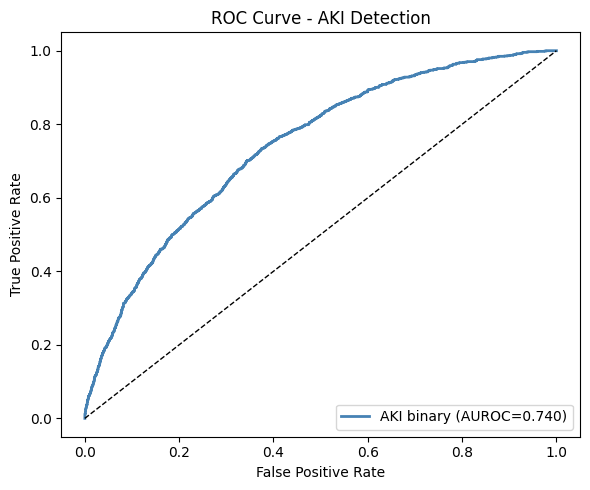

In [29]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(test_labels, tp)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AKI binary (AUROC={test_auroc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - AKI Detection')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_aki_binary.png', dpi=150)
plt.show()

The binary model achieves an AUROC of **0.7399** on the test set. Given that it predicts the onset of AKI using only the first 12 hours of patient data collected from multiple ICUs, this represents a strong result. Predicting AKI at such an early stage is challenging, as many patients have not yet developed clear signs of kidney injury.

The model also achieves an AUPRC of **0.3385**, which is substantially higher than the baseline prevalence of **14.9%**, indicating that it is learning meaningful patterns associated with AKI rather than relying on chance.

At the selected operating point (threshold = **0.488**), chosen to maximise the F1 score on the validation set, the model achieves a **sensitivity of 56.1%** and a **specificity of 76.6%**. This means the model identifies more than half of the patients who will develop AKI while maintaining a relatively low false-positive rate, making it suitable as an early warning system.


## Apache table removed

In [22]:
db_no_apache = Database(
    {name: tbl for name, tbl in db.table_dict.items()
     if name != 'apachePatientResult'}
)

col_to_stype_no_apache = set_col_stypes(
    db_no_apache, get_stype_proposal(db_no_apache))

data_no_apache, col_stats_no_apache = make_pkey_fkey_graph(
    db_no_apache,
    col_to_stype_dict=col_to_stype_no_apache,
    text_embedder_cfg=text_embedder_cfg)

print('Graph without apachePatientResult:')
for ntype in data_no_apache.node_types:
    print(f'  {ntype}  nodes={data_no_apache[ntype].num_nodes:,}')

Embedding raw data in mini-batch: 100%|██████████| 179/179 [00:00<00:00, 295.61it/s]


Graph without apachePatientResult:
  patient  nodes=50,184
  diagnosis  nodes=206,034
  treatment  nodes=281,114
  medication  nodes=526,434
  lab  nodes=654,224
  vitalPeriodic  nodes=984,808
  intakeOutput  nodes=347,780
  nurseCharting  nodes=983,523
  vitalAperiodic  nodes=660,196
  admissionDrug  nodes=101,458
  respiratoryCare  nodes=45,585


In [26]:
make_reproducible(42)
best_cfg = {
    'pos_weight_val': 5.0,   
    'lr':             0.0003,     
    'channels':       256      
}
pw_abl = torch.tensor([best_cfg['pos_weight_val']]).to(device)

model_abl = Model(
    data=data_no_apache, col_stats=col_stats_no_apache,
    num_layers=2, channels=best_cfg['channels'], out_channels=1,
    aggr=['mean', 'min', 'max'], norm='batch_norm', dropout=0.3
).to(device)

optimizer_abl = torch.optim.Adam(
    model_abl.parameters(), lr=best_cfg['lr'], weight_decay=1e-4)
loss_fn_abl = nn.BCEWithLogitsLoss(pos_weight=pw_abl)
loaders_abl  = build_loaders(
    data_no_apache, task, train_tbl, val_tbl, test_tbl)

best_val_abl = -math.inf
best_state_abl = None

print("ep   loss     val_auc")
print('-' * 28)

for ep in range(1, n_epochs + 1):
    tl = train_step(model_abl, loaders_abl['train'],
                    optimizer_abl, loss_fn_abl, task, device)
    vp = get_preds(model_abl, loaders_abl['val'], task, device)
    va = roc_auc_score(val_tbl.df['aki_label'].values, vp)
    print(f'{ep}   {tl:.4f}   {va:.4f}')
    if va > best_val_abl:
        best_val_abl = va
        best_state_abl = copy.deepcopy(model_abl.state_dict())



ep   loss     val_auc
----------------------------


1   1.1099   0.6331


2   1.0687   0.6712


3   1.0374   0.6989


4   1.0131   0.7082


...

16   0.8904   0.7082


17   0.8865   0.7056


18   0.8779   0.7039


19   0.8779   0.7065


20   0.8626   0.7067


In [28]:
model_abl.load_state_dict(best_state_abl)

ti_test_abl = get_node_train_table_input(table=test_labeled, task=task)
test_loader_abl = NeighborLoader(
    data_no_apache, num_neighbors=n_nbrs, time_attr='time',
    input_nodes=ti_test_abl.nodes, input_time=ti_test_abl.time,
    transform=ti_test_abl.transform,
    batch_size=bs, temporal_strategy='uniform',
    shuffle=False, num_workers=0, persistent_workers=False)

tp_abl = get_preds(model_abl, test_loader_abl, task, device)
test_labels_abl = test_labeled.df['aki_label'].values.astype(int)

test_auroc_abl = roc_auc_score(test_labels_abl, tp_abl)
test_auprc_abl = average_precision_score(test_labels_abl, tp_abl)

print(f'\nAKI Ablation: no apachePatientResult')
print(f'Test AUROC : {test_auroc_abl:.4f}  (original: 0.7399)')
print(f'Test AUPRC : {test_auprc_abl:.4f}  (original: 0.3385)')
print(f'AUROC drop : {0.7399 - test_auroc_abl:+.4f}')


AKI Ablation: no apachePatientResult
Test AUROC : 0.7205  (original: 0.7399)
Test AUPRC : 0.3159  (original: 0.3385)
AUROC drop : +0.0194


Removing apachePatientResult from the graph reduces test AUROC from 0.7399 to 0.7205 (−0.0194) and AUPRC from 0.3385 to 0.3159. The APACHE severity score therefore contributes meaningfully to the model's performance, which is consistent with the known leakage concern: the APACHE score is computed from the full first 24 hours of the ICU stay, whereas the model's observation window closes at 12 hours.

That said, the drop is modest. The majority of predictive signal comes from the clinical time-series features like creatinine, urine output, haemodynamic measurements, and medications, which are legitimately available within the 12-hour window.

### KDIGO Stage Prediction (Ordinal)

The earlier model only predicted whether a patient would develop AKI or not. Here, I extend the problem so the model predicts the actual KDIGO severity stage (0–3).

To do this, I use three prediction heads that share the same GNN backbone:
- **Head 1** predicts if the patient reaches at least Stage 1 AKI
- **Head 2** predicts if the patient reaches at least Stage 2 AKI
- **Head 3** predicts if the patient reaches Stage 3 AKI or needs dialysis/RRT

Each head acts like a separate binary classifier, but together they preserve the natural ordering of AKI severity. For example:
- Stage 3 → `[1,1,1]`
- Stage 2 → `[1,1,0]`
- Stage 1 → `[1,0,0]`

This approach matches the clinical definition of AKI because a patient with Stage 3 AKI also meets the criteria for Stages 1 and 2.

In [30]:
def get_stage_labels(dataset):
   
    pids = set(dataset._aki_labels.keys())
    print(f'Computing stage labels for {len(pids):,} labeled patients...')

    lab_path = file_map['lab']
    read_cols = ['patientunitstayid', 'labname', 'labresult', 'labresultoffset']
    avail = pd.read_csv(lab_path, nrows=0).columns.tolist()
    read_cols = [c for c in read_cols if c in avail]
    chunks = []
    for chunk in pd.read_csv(lab_path, usecols=read_cols,
                              chunksize=500_000, low_memory=False):
        c = chunk[chunk['patientunitstayid'].isin(pids)]
        if len(c) == 0: continue
        c = c[c['labname'] == 'creatinine']
        c = c[c['labresultoffset'] <= pred_end]
        if len(c): chunks.append(c)
    creat = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(columns=read_cols)
    creat['labresult'] = pd.to_numeric(creat['labresult'], errors='coerce')
    creat = creat.dropna(subset=['labresult'])
    creat = creat[(creat['labresult'] > 0.1) & (creat['labresult'] < 50)]
    print(f'  Serum creatinine rows: {len(creat):,}')
    
    pre_adm = creat[creat['labresultoffset'] < 0]
    baseline_p1 = (pre_adm.sort_values('labresultoffset', ascending=False)
                   .groupby('patientunitstayid')['labresult']
                   .first().clip(lower=0.7).rename('baseline'))
    in_window = creat[creat['labresultoffset'].between(0, feat_window)]
    baseline_p2 = (in_window.groupby('patientunitstayid')['labresult']
                   .min().clip(lower=0.7).rename('baseline'))
    baseline = baseline_p1.combine_first(baseline_p2)
    pids_with_baseline = set(baseline.index)

    feat_creat = creat[creat['labresultoffset'].between(0, feat_window)]
    feat_check = feat_creat.merge(baseline, on='patientunitstayid', how='inner')
    early_aki = set(feat_check[
        (feat_check['labresult'] >= feat_check['baseline'] * 1.5) |
        (feat_check['labresult'] >= feat_check['baseline'] + 0.3)
    ]['patientunitstayid'].unique())

    treat = pd.read_csv(file_map['treatment'], low_memory=False)
    treat = treat[treat['patientunitstayid'].isin(pids)]
    early_rrt = set(); pred_rrt = set()
    if 'treatmentstring' in treat.columns and 'treatmentoffset' in treat.columns:
        treat['is_rrt'] = treat['treatmentstring'].apply(is_rrt)
        rrt = treat[treat['is_rrt']]
        early_rrt = set(rrt[rrt['treatmentoffset'] <= feat_window]['patientunitstayid'])
        pred_rrt = set(rrt[rrt['treatmentoffset'].between(pred_start, pred_end)]['patientunitstayid'])

    exclude_pids = early_aki | early_rrt
    valid_pids = (pids & pids_with_baseline) - exclude_pids

    pred_creat = creat[creat['labresultoffset'].between(pred_start, pred_end)]
    pred_creat = pred_creat.merge(baseline, on='patientunitstayid', how='inner')

    s3 = (set(pred_creat[pred_creat['labresult'] >= pred_creat['baseline'] * 3.0
              ]['patientunitstayid']) | pred_rrt) & valid_pids
    s2 = (set(pred_creat[pred_creat['labresult'] >= pred_creat['baseline'] * 2.0
              ]['patientunitstayid']) & valid_pids) - s3
    s1 = (set(pred_creat[
                  (pred_creat['labresult'] >= pred_creat['baseline'] * 1.5) |
                  (pred_creat['labresult'] >= pred_creat['baseline'] + 0.3)
              ]['patientunitstayid']) & valid_pids) - s2 - s3

    stg_lbl_dict = {}
    for pid in valid_pids:
        if   pid in s3: stg_lbl_dict[pid] = 3
        elif pid in s2: stg_lbl_dict[pid] = 2
        elif pid in s1: stg_lbl_dict[pid] = 1
        else:           stg_lbl_dict[pid] = 0

    counts = {k: sum(1 for v in stg_lbl_dict.values() if v == k) for k in range(4)}
    total = len(stg_lbl_dict)
    print(f'\n  Stage 0 (no AKI) : {counts[0]:,}  ({counts[0]/total:.1%})')
    print(f'  Stage 1: {counts[1]:,}  ({counts[1]/total:.1%})')
    print(f'  Stage 2: {counts[2]:,}  ({counts[2]/total:.1%})')
    print(f'  Stage 3: {counts[3]:,}  ({counts[3]/total:.1%})')
    print(f'  Total labeled: {total:,}')
    return stg_lbl_dict

stage_lbl = get_stage_labels(dataset)

Computing stage labels for 50,184 labeled patients...
  Serum creatinine rows: 246,752

  Stage 0 (no AKI) : 42,755  (85.2%)
  Stage 1: 5,890  (11.7%)
  Stage 2: 634  (1.3%)
  Stage 3: 904  (1.8%)
  Total labeled: 50,183


In [31]:
class StagingTask(EntityTask):
    task_type = TaskType.BINARY_CLASSIFICATION
    entity_col = 'patientunitstayid'
    entity_table = 'patient'
    time_col = 'predtime'
    target_col = 'stage_gte1'
    timedelta = pd.Timedelta(hours=12)
    metrics = [roc_auc, average_precision, accuracy, f1]

    def __init__(self, *a, **k):
        super().__init__(*a, **k)
        self.test_timestamp = self.dataset.test_timestamp
        self.val_timestamp = self.dataset.val_timestamp
        if self.test_timestamp and self.val_timestamp:
            self.num_eval_timestamps = max(
                1, int((self.test_timestamp - self.val_timestamp) / self.timedelta))

    def make_table(self, db, timestamps):
        ts_df = pd.DataFrame({'timestamp': timestamps})
        pat = self.dataset._admit_times.copy()
        pat['predtime'] = pat['admittime'] + pd.Timedelta(minutes=feat_window)
        df = duckdb.sql("""
            SELECT p.patientunitstayid AS pid_orig, p.predtime
            FROM ts_df t JOIN pat p
              ON p.predtime > t.timestamp
             AND p.predtime <= t.timestamp + INTERVAL '12 HOURS'
        """).df()
        if len(df) == 0:
            return Table(
                df=pd.DataFrame(columns=['patientunitstayid','predtime',
                                         'stage_gte1','stage_gte2','stage_gte3']),
                fkey_col_to_pkey_table={self.entity_col: self.entity_table},
                pkey_col=None, time_col=self.time_col)
        pm = self.dataset.pkey_remaps.get('patient', (None, {}))[1]
        df['patientunitstayid'] = df['pid_orig'].map(pm)
        df = df.dropna(subset=['patientunitstayid'])
        df['patientunitstayid'] = df['patientunitstayid'].astype(np.int64)
        df['stage'] = df['pid_orig'].map(stage_lbl)
        df = df.dropna(subset=['stage'])
        df['stage']      = df['stage'].astype(int)
        df['stage_gte1'] = (df['stage'] >= 1).astype(int)
        df['stage_gte2'] = (df['stage'] >= 2).astype(int)
        df['stage_gte3'] = (df['stage'] >= 3).astype(int)
        df['predtime']   = pd.to_datetime(df['predtime']).astype('datetime64[ns]')
        return Table(
            df=df[['patientunitstayid','predtime','stage_gte1','stage_gte2','stage_gte3']],
            fkey_col_to_pkey_table={self.entity_col: self.entity_table},
            pkey_col=None, time_col=self.time_col)

stg_task = StagingTask(dataset)
train_stg = stg_task.get_table('train')
val_stg = stg_task.get_table('val')
test_stg = stg_task.get_table('test')
print(f'Train: {len(train_stg.df):,} | Val: {len(val_stg.df):,} | Test: {len(test_stg.df):,}')
for col in ['stage_gte1', 'stage_gte2', 'stage_gte3']:
    rate = train_stg.df[col].mean()
    print(f'  {col}: {rate:.1%} positive  →  pos_weight ≈ {(1-rate)/rate:.1f}x')

n_patients = data['patient'].num_nodes
stage_gte1_all = torch.zeros(n_patients)
stage_gte2_all = torch.zeros(n_patients)
stage_gte3_all = torch.zeros(n_patients)
_, pid_remap = dataset.pkey_remaps['patient']
for orig_pid, stage in stage_lbl.items():
    r = pid_remap.get(orig_pid)
    if r is not None:
        stage_gte1_all[r] = float(stage >= 1)
        stage_gte2_all[r] = float(stage >= 2)
        stage_gte3_all[r] = float(stage >= 3)
stage_gte1_all = stage_gte1_all.to(device)
stage_gte2_all = stage_gte2_all.to(device)
stage_gte3_all = stage_gte3_all.to(device)


Making task table for train split from scratch...
Done in 0.14 seconds.
Making task table for val split from scratch...
Done in 0.23 seconds.
Making task table for test split from scratch...
Done in 0.15 seconds.
Train: 35,128 | Val: 7,494 | Test: 7,492
  stage_gte1: 14.9% positive  →  pos_weight ≈ 5.7x
  stage_gte2: 3.1% positive  →  pos_weight ≈ 30.8x
  stage_gte3: 1.9% positive  →  pos_weight ≈ 53.0x


In [32]:
class OrdinalModel(torch.nn.Module):
   
    def __init__(self, data, col_stats, num_layers, channels,
                 aggr=['mean', 'min', 'max'], norm='batch_norm', dropout=0.3):
        super().__init__()
        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={nt: data[nt].tf.col_names_dict
                                    for nt in data.node_types},
            node_to_col_stats=col_stats)
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[n for n in data.node_types
                        if data[n].get('time', None) is not None],
            channels=channels)
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types, edge_types=data.edge_types,
            channels=channels, aggr=aggr, num_layers=num_layers)
        self.head1 = MLP(in_channels=channels, hidden_channels=channels,
                         out_channels=1, num_layers=2, norm=norm, dropout=dropout)
        self.head2 = MLP(in_channels=channels, hidden_channels=channels,
                         out_channels=1, num_layers=2, norm=norm, dropout=dropout)
        self.head3 = MLP(in_channels=channels, hidden_channels=channels,
                         out_channels=1, num_layers=2, norm=norm, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, batch, entity_table):
        x = self.encoder(batch.tf_dict)
        rt = self.temporal_encoder(batch[entity_table].seed_time,
                                    batch.time_dict, batch.batch_dict)
        for nt in rt: x[nt] = x[nt] + rt[nt]
        x = self.gnn(x, batch.edge_index_dict)
        emb = self.dropout(x[entity_table][:batch[entity_table].batch_size])
        return self.head1(emb).view(-1), self.head2(emb).view(-1), self.head3(emb).view(-1)

In [33]:
def train_ordinal(model, loader, optimizer, lf1, lf2, lf3,
                             task, device, g2, g3):
    model.train(); la = ca = 0
    for batch in tqdm(loader, desc='  train', leave=False):
        batch = batch.to(device); optimizer.zero_grad()
        p1, p2, p3 = model(batch, task.entity_table)
        bs = batch[task.entity_table].batch_size
        nids = batch[task.entity_table].n_id[:bs]
        y1 = batch[task.entity_table].y.float()
        y2 = g2[nids]
        y3 = g3[nids]
        loss = lf1(p1, y1) + lf2(p2, y2) + lf3(p3, y3)
        loss.backward(); optimizer.step()
        la += loss.detach().item() * bs; ca += bs
    return la / ca

@torch.no_grad()
def eval_ordinal(model, loader, task, device):
    model.eval(); p1s, p2s, p3s = [], [], []
    for batch in loader:
        batch = batch.to(device)
        p1, p2, p3 = model(batch, task.entity_table)
        p1s.append(torch.sigmoid(p1).cpu())
        p2s.append(torch.sigmoid(p2).cpu())
        p3s.append(torch.sigmoid(p3).cpu())
    return torch.cat(p1s).numpy(), torch.cat(p2s).numpy(), torch.cat(p3s).numpy()

In [34]:
# The ordinal model reuses the best hyperparameters found during the AKI binary grid search.
# This is intentional: both tasks share the same patient cohort, graph structure, and feature
# space, so the optimal channel width and learning rate are expected to transfer directly.
# Running a separate grid search would be redundant and would roughly triple compute time.
pw1 = torch.tensor([(1 - train_stg.df['stage_gte1'].mean()) /
                      train_stg.df['stage_gte1'].mean()]).to(device)
pw2 = torch.tensor([(1 - train_stg.df['stage_gte2'].mean()) /
                      train_stg.df['stage_gte2'].mean()]).to(device)
pw3 = torch.tensor([(1 - train_stg.df['stage_gte3'].mean()) /
                      train_stg.df['stage_gte3'].mean()]).to(device)

ord_model = OrdinalModel(data=data, col_stats=col_stats, num_layers=2,
                                 channels=best_cfg['channels'], aggr=['mean', 'min', 'max'],
                                 norm='batch_norm', dropout=0.3).to(device)
ord_opt = torch.optim.Adam(ord_model.parameters(), lr=best_cfg['lr'], weight_decay=1e-4)
lf1 = nn.BCEWithLogitsLoss(pos_weight=pw1)
lf2 = nn.BCEWithLogitsLoss(pos_weight=pw2)
lf3 = nn.BCEWithLogitsLoss(pos_weight=pw3)
stg_ld = build_loaders(data, stg_task, train_stg, val_stg, test_stg)

print(f'Ordinal model params: {sum(p.numel() for p in ord_model.parameters()):,}')
print(f'Train batches: {len(stg_ld["train"])}')

Ordinal model params: 18,846,851
Train batches: 69


In [35]:
best_ord = -math.inf
ord_state = None
save_path_ord = '/kaggle/working/best_model_ordinal.pt'

print("ep  loss  auroc>=1  auroc>=2  auroc>=3")
print('-' * 52)

for ep in range(1, n_epochs + 1):
    tl = train_ordinal(
        ord_model, stg_ld['train'], ord_opt,
        lf1, lf2, lf3, stg_task, device, stage_gte2_all, stage_gte3_all)
    vp1, vp2, vp3 = eval_ordinal(
        ord_model, stg_ld['val'], stg_task, device)
    val_rids = val_stg.df[stg_task.entity_col].values.astype(int)
    va1 = roc_auc_score(stage_gte1_all[val_rids].cpu().int().numpy(), vp1)
    va2 = roc_auc_score(stage_gte2_all[val_rids].cpu().int().numpy(), vp2)
    va3 = roc_auc_score(stage_gte3_all[val_rids].cpu().int().numpy(), vp3)
    print(f'{ep}  {tl:>8.4f}  {va1:>9.4f}  {va2:>9.4f}  {va3:>9.4f}')
    if va1 > best_ord:
        best_ord = va1
        ord_state = copy.deepcopy(ord_model.state_dict())
        torch.save(ord_state, save_path_ord)

print(f'\nBest Val AUROC (≥Stage 1): {best_ord:.4f}')

ep  loss  auroc>=1  auroc>=2  auroc>=3
----------------------------------------------------


1    3.8225     0.5859     0.6445     0.6790


2    3.6335     0.6697     0.7292     0.7489


3    3.4183     0.6611     0.6940     0.7085


4    3.3314     0.6333     0.6920     0.7186


...

16    2.6176     0.7089     0.7212     0.7782


17    2.5156     0.7150     0.7352     0.7857


18    2.5348     0.7064     0.7030     0.7612


19    2.4785     0.7150     0.7193     0.7576


20    2.4234     0.7090     0.7111     0.7397

Best Val AUROC (≥Stage 1): 0.7150


In [36]:
ord_model.load_state_dict(ord_state)

ti_test_ord = get_node_train_table_input(table=test_stg, task=stg_task)
test_loader_ord = NeighborLoader(
    data, num_neighbors=n_nbrs, time_attr='time',
    input_nodes=ti_test_ord.nodes, input_time=ti_test_ord.time,
    transform=ti_test_ord.transform, batch_size=bs,
    temporal_strategy='uniform', shuffle=False,
    num_workers=0, persistent_workers=False)

tp1, tp2, tp3 = eval_ordinal(ord_model, test_loader_ord, stg_task, device)

test_rids = test_stg.df[stg_task.entity_col].values.astype(int)
y_test1 = stage_gte1_all[test_rids].cpu().int().numpy()
y_test2 = stage_gte2_all[test_rids].cpu().int().numpy()
y_test3 = stage_gte3_all[test_rids].cpu().int().numpy()

from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
auroc1 = roc_auc_score(y_test1, tp1)
auroc2 = roc_auc_score(y_test2, tp2)
auroc3 = roc_auc_score(y_test3, tp3)
auprc1 = average_precision_score(y_test1, tp1)
auprc2 = average_precision_score(y_test2, tp2)
auprc3 = average_precision_score(y_test3, tp3)

prev1, prev2, prev3 = y_test1.mean(), y_test2.mean(), y_test3.mean()

print('KDIGO staging:')
print(f'  Head Prevalence AUROC AUPRC')
print(f'  {"Stage ≥ 1 (any AKI)":<22} {prev1:>10.1%} {auroc1:>8.4f} {auprc1:>8.4f}')
print(f'  {"Stage ≥ 2":<22} {prev2:>10.1%} {auroc2:>8.4f} {auprc2:>8.4f}')
print(f'  {"Stage ≥ 3":<22} {prev3:>10.1%} {auroc3:>8.4f} {auprc3:>8.4f}')

pred_stage = np.zeros(len(tp1), dtype=int)
pred_stage[tp1 > 0.5] = 1
pred_stage[tp2 > 0.5] = 2
pred_stage[tp3 > 0.5] = 3

true_stage = y_test1 + y_test2 + y_test3 

print('\nPer-stage classification report:')
print(classification_report(true_stage, pred_stage,
      target_names=['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3'],
      digits=3))

KDIGO staging:
  Head Prevalence AUROC AUPRC
  Stage ≥ 1 (any AKI)         14.8%   0.7133   0.2892
  Stage ≥ 2                    3.0%   0.7339   0.0809
  Stage ≥ 3                    1.8%   0.7718   0.0680

Per-stage classification report:
              precision    recall  f1-score   support

     Stage 0      0.919     0.633     0.750      6383
     Stage 1      0.175     0.164     0.169       885
     Stage 2      0.017     0.099     0.029        91
     Stage 3      0.046     0.602     0.086       133

    accuracy                          0.571      7492
   macro avg      0.289     0.374     0.258      7492
weighted avg      0.805     0.571     0.661      7492



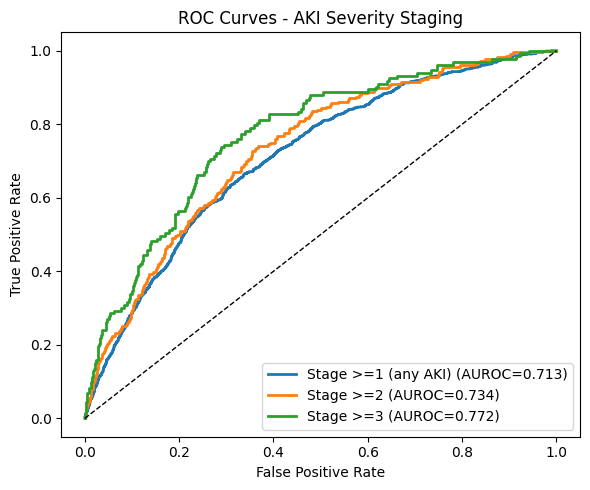

In [37]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
for y, p, label, auroc in [
    (y_test1, tp1, 'Stage >=1 (any AKI)', auroc1),
    (y_test2, tp2, 'Stage >=2', auroc2),
    (y_test3, tp3, 'Stage >=3', auroc3),
]:
    fpr, tpr, _ = roc_curve(y, p)
    ax.plot(fpr, tpr, lw=2, label=f'{label} (AUROC={auroc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - AKI Severity Staging')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_aki_staging.png', dpi=150)
plt.show()

For the ordinal model, I report the AUROC for each binary threshold separately (≥ Stage 1, ≥ Stage 2, and ≥ Stage 3) rather than using a single overall score. Since each output head functions as an independent binary classifier, reporting AUROC for each threshold provides a clearer picture of how well the model distinguishes patients at different levels of AKI severity. A single aggregated metric would hide differences in performance across the three stages.

The AUROC increases with AKI severity, rising from **0.7133** for Stage 1 to **0.7339** for Stage 2 and **0.7718** for Stage 3. This trend is expected because patients with severe AKI typically exhibit more pronounced clinical abnormalities, making them easier to distinguish from patients without AKI. In contrast, Stage 1 is the most challenging to predict, as early-stage AKI often overlaps with the no-AKI population.

The AUPRC values are lower across the three heads (**0.2892**, **0.0809**, and **0.0680**, respectively). This is largely due to the low prevalence of the more severe stages: only **3.0%** of patients develop Stage 2 AKI and **1.8%** reach Stage 3, making high precision difficult to achieve.

Comparing the first ordinal head (AUROC **0.7133**) with the binary AKI model (AUROC **0.7399**) shows a modest reduction in performance. This is expected because the ordinal model learns all three severity thresholds using a shared backbone, requiring the feature representation to balance multiple objectives. In contrast, the binary model is optimised for a single task, allowing it to learn features specifically for distinguishing AKI from non-AKI patients.


In [29]:
import gc

to_del = ['data','model','loaders','dataset','db',
          'train_tbl','val_tbl','test_tbl','test_labeled',
          'best_state','optimizer','loss_fn','ti_test','test_loader',
          'col_stats','col_to_stype','task',
          'ord_model','ord_opt','stg_ld','stg_task',
          'train_stg','val_stg','test_stg',
          'stage_gte1_all','stage_gte2_all','stage_gte3_all',
          'ord_state','lf1','lf2','lf3',
          'test_loader_ord','ti_test_ord',
          'pw1','pw2','pw3']
for v in to_del:
    globals().pop(v, None)

gc.collect()
torch.cuda.empty_cache()
allocated = torch.cuda.memory_allocated() / 1024**3
reserved = torch.cuda.memory_reserved()  / 1024**3


# Second task: Vasopressor Initiation Prediction (eICU)

## The clinical question

Vasopressors are medications used when a patient’s blood pressure becomes dangerously low and the body can no longer maintain proper blood flow on its own. Starting a vasopressor is a serious clinical event and usually means the patient is becoming hemodynamically unstable, which is one of the main pathways involved in PICS.

For this task, I want to see whether the model can predict if a patient will need a new vasopressor later in their ICU stay using only the first few hours of data after admission.

## Why this time window?

I use the first 6 hours of the ICU stay as the observation window (0–360 minutes) and predict whether vasopressors will be started during the following 12 hours (360–1080 minutes).

I chose this setup because 6 hours is early enough to be clinically useful while still giving enough time to capture important trends in blood pressure and patient stability. Patients who were already receiving vasopressors during the first 6 hours are excluded because, in those cases, the outcome has already happened and there is nothing left to predict.

The minimum ICU stay is set to 18 hours so that both the observation window and prediction window are fully available for every patient.

## Tables Used and Why

The strongest predictors of vasopressor use are haemodynamic measurements. The **vitalPeriodic** and **vitalAperiodic** tables capture changes in cardiovascular stability during the first six hours of ICU admission through variables such as MAP, heart rate, blood pressure, and cardiac output. The **lab** table complements these with markers such as lactate and pH, which can indicate tissue hypoperfusion before vital signs visibly deteriorate.

To provide clinical context, I include **patient**, **diagnosis**, and **apachePatientResult**, which capture demographics, admission diagnosis, and illness severity. **admissionDrug**, **medication**, **treatment**, and **nurseCharting** provide information on medications, early interventions, and bedside observations, while **respiratoryCare** is included because mechanically ventilated patients are more likely to require vasopressor support.


I intentionally exclude the `infusionDrug` table because it directly records vasopressor administration, which is the label source. Including it would leak the answer into the model.

In [4]:
feat_hrs = 6     
excl_min = feat_hrs * 60        
label_end = excl_min + 12 * 60    

pat_limit = 0
n_epochs = 20
bs = 512
n_nbrs = [128, 128]

print(f'Vasopressor task: observing 0-{feat_hrs}h, predicting {feat_hrs}-{feat_hrs+12}h')

Vasopressor task: observing 0-6h, predicting 6-18h


In [5]:
base_dir = EICU_DIR 

def find_csv(name):
    flat = os.path.join(base_dir, f'{name}.csv')
    nested = os.path.join(base_dir, f'{name}.csv', f'{name}.csv')
    if os.path.isfile(flat):
        return flat
    if os.path.isfile(nested):
        print(f'  Found {name}.csv in nested folder')
        return nested          
    return flat  

file_map = {
    'patient':             find_csv('patient'),
    'lab':                 find_csv('lab'),
    'treatment':           find_csv('treatment'),
    'medication':          find_csv('medication'),
    'diagnosis':           find_csv('diagnosis'),
    'apachePatientResult': find_csv('apachePatientResult'),
    'infusionDrug':        find_csv('infusionDrug'),
    'vitalPeriodic':       find_csv('vitalPeriodic'),
    'nurseCharting':       find_csv('nurseCharting'),
    'vitalAperiodic':      find_csv('vitalAperiodic'),
    'admissionDrug':       find_csv('admissionDrug'),
    'respiratoryCare':     find_csv('respiratoryCare'),
}

print(f'base_dir: {base_dir}\n')
for name, path in file_map.items():
    status = 'found' if os.path.isfile(path) else 'missing'
    print(f'  {status} {name}')

  Found apachePatientResult.csv in nested folder
  Found infusionDrug.csv in nested folder
  Found vitalPeriodic.csv in nested folder
  Found nurseCharting.csv in nested folder
  Found vitalAperiodic.csv in nested folder
  Found admissionDrug.csv in nested folder
  Found respiratoryCare.csv in nested folder
base_dir: /kaggle/input/datasets/hilinafissha16/e-icu-data

  found patient
  found lab
  found treatment
  found medication
  found diagnosis
  found apachePatientResult
  found infusionDrug
  found vitalPeriodic
  found nurseCharting
  found vitalAperiodic
  found admissionDrug
  found respiratoryCare


In [6]:
def age_to_float(age_str):
    if pd.isna(age_str): return np.nan
    s = str(age_str).strip()
    if '>' in s: return 90.0
    try: return float(s)
    except: return np.nan

def fix_dtypes(df):
    m = {'Int64':int,'Int32':int,'Float64':float,'boolean':bool}
    cvt = {}
    for col in df.columns:
        dt = str(df[col].dtype)
        if dt in m:
            if m[dt] in (int,float): df[col] = df[col].fillna(0)
            cvt[col] = m[dt]
    return df.astype(cvt) if cvt else df

def set_col_stypes(db, col_to_stype_dict):
    TEXT = {'apacheadmissiondx','treatmentstring','diagnosisstring',
            'drugname','labname','labresulttext','unittype','unitstaytype',
            'gender','ethnicity','wardid','routeadmin','icd9code',
            'admitsource','hospitaldischargestatus','unitdischargelocation',
            'drugnotetype',
            'nursechartsectionname','nursechartcelltypecat','nursechartcelltypevallabel',
            'nursechartvalue','airwaytype','airwaysize','drugunit','drugadmitfrequency','drugdosage'}
    SKIP = {'patientunitstayid','patienthealthsystemstayid',
            'labid','treatmentid','medicationid','diagnosisid',
            'apachepatientresultsid','hospitalid','vitalperiodicid',
            'infusiondrugid',
            'nursechartid','vitalaperiodicid','admissiondrugid','respcareid'}
    for tbl, cd in col_to_stype_dict.items():
        for col in list(cd):
            if col in SKIP: del cd[col]
            elif col in TEXT: cd[col] = stype.text_embedded
    return col_to_stype_dict

vaso_terms = [
    'norepinephrine','levophed','norepi',
    'epinephrine','adrenalin',
    'phenylephrine','neosynephrine','neo-synephrine',
    'vasopressin','pitressin',
    'dopamine',
    'milrinone',
]

def is_vasopressor(s):
    if pd.isna(s): return False
    s = str(s).lower()
    return any(t in s for t in vaso_terms)

### Cohort definition

**Inclusion:** ICU stays ≥ 18 hours (ensures the full 6–18h prediction window exists).

**Exclusion:** Patients already on vasopressors in the first 6 hours, the model
predicts new initiation, so pre-existing vasopressor use would corrupt the label.

**Label:** any new vasopressor (norepinephrine, epinephrine, phenylephrine,
vasopressin, dopamine, or milrinone) recorded in the infusionDrug table
between 6h and 18h after ICU admission.

In [7]:
class VasoDataset(Dataset):
    table_schema = {
        'patient': {
            'pkey_col': 'patientunitstayid',
            'fkey_col_to_pkey_table': {},
            'time_col': 'predtime'
        },
        'diagnosis': {
            'pkey_col': 'diagnosisid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'diagnosistime'
        },
        'treatment': {
            'pkey_col': 'treatmentid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'treatmenttime'
        },
        'medication': {
            'pkey_col': 'medicationid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'medicationtime'
        },
        'lab': {
            'pkey_col': 'labid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'labtime'
        },
        'vitalPeriodic': {
            'pkey_col': 'vitalperiodicid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'vitaltime'
        },
        'apachePatientResult': {
            'pkey_col': 'apachepatientresultsid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': None
        },
        'nurseCharting': {
            'pkey_col': 'nursechartid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'nursecharttime'
        },
        'vitalAperiodic': {
            'pkey_col': 'vitalaperiodicid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'vitalaperiodictime'
        },
        'admissionDrug': {
            'pkey_col': 'admissiondrugid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': None
        },
        'respiratoryCare': {
            'pkey_col': 'respcareid',
            'fkey_col_to_pkey_table': {'patientunitstayid': 'patient'},
            'time_col': 'respcarestatusoffsettime'
        },
    }
    leakage_cols = {
        'patient': ['unitdischargestatus','unitdischargeoffset','unitdischargelocation',
                    'hospitaldischargestatus','hospitaldischargeoffset',
                    'hospitaldischargelocation','hospitaldischargevalue24','unitdischargevalue24'],
        'apachePatientResult': ['actualhospitalmortality','actualicumortality',
                                'unabridgedhosplos','unabridgedactualventdays','patientdied'],
    }
    lab_cols = ['labid','patientunitstayid','labname',
                  'labresult','labresultoffset','labresulttext']
    vital_cols = ['patientunitstayid','observationoffset',
                  'heartrate','systemicmean','sao2','respiration']
    nurse_cols = ['nursechartid','patientunitstayid','nursechartoffset',
                    'nursechartsectionname','nursechartcelltypecat',
                    'nursechartcelltypevallabel','nursechartvalue']
    vaperi_cols = ['vitalaperiodicid','patientunitstayid','observationoffset',
                    'noninvasivesystolic','noninvasivediastolic','noninvasivemean',
                    'paop','cardiacoutput','cardiacinput','svr','svri','pvr','pvri']
    admdr_cols = ['admissiondrugid','patientunitstayid','drugoffset',
                    'drugenteredoffset','drughiclseqno','drugname','drugdosage',
                    'drugunit','drugadmitfrequency']
    resp_cols = ['respcareid','patientunitstayid','respcarestatusoffset',
                    'currentdayofventilation','priorventstartoffset',
                    'airwaytype','airwaysize','coughpressure','peakpressure',
                    'meanairwaypressure','peep','fiO2','tidal']

    def __init__(self, base_dir=base_dir, patients_limit=0, feat_hours=6):
        super().__init__(cache_dir=None)
        self.base_dir = base_dir
        self.patients_limit = patients_limit
        self.feat_hours = feat_hours
        self.val_timestamp = None
        self.test_timestamp = None
        self.pkey_remaps = {}
        self._vaso_labels = {}
        self._admit_times = None
        self._built_db = self.make_db()

    def get_db(self, upto_test_timestamp=None) -> Database:
        return self._built_db

    def _set_timestamps(self, pred_times):
        ts = pd.Series(pred_times).dropna().sort_values()
        self.val_timestamp = ts.iloc[int(len(ts)*0.70)]
        self.test_timestamp = ts.iloc[int(len(ts)*0.85)]
        print(f'split: val: {self.val_timestamp.date()}, '
              f'test: {self.test_timestamp.date()}')

    def _get_vaso_labels(self, inf_df, pids):
       
        inf = inf_df[inf_df['patientunitstayid'].isin(pids)].copy()
        if 'drugname' not in inf.columns or 'infusionoffset' not in inf.columns:
            print('  WARNING: infusionDrug missing expected columns')
            return {}

        inf['infusionoffset'] = pd.to_numeric(inf['infusionoffset'], errors='coerce')
        inf['is_vaso']        = inf['drugname'].apply(is_vasopressor)
        vaso = inf[inf['is_vaso']][['patientunitstayid','infusionoffset']]

        labels = {}
        excl = 0
        for pid in pids:
            pv = vaso[vaso['patientunitstayid'] == pid]['infusionoffset'].dropna()
            on_early = (pv <= self.feat_hours * 60).any()
            if on_early:
                excl += 1
                continue
            new_window = ((pv > self.feat_hours * 60) & (pv <= (self.feat_hours + 12) * 60)).any()
            labels[pid] = int(new_window)

        pos = sum(labels.values())
        total = len(labels)
        rate = pos/total if total else 0
        print(f'  Labels: {pos:,} positive / {total:,} total ({rate:.1%} vasopressor rate) '
              f'| {excl:,} excluded (already on vasopressors)')
        return labels

    def make_db(self) -> Database:

        def load(name, cols=None):
            path = file_map.get(name)
            if not path or not os.path.isfile(path):
                raise FileNotFoundError(f'Missing: {name} — check file_map')
            print(f'  {name}...', end=' ')
            df = pd.read_csv(path, usecols=cols, low_memory=False)
            print(f'{len(df):,} rows')
            return df

        pat = load('patient');  pat['age'] = pat['age'].apply(age_to_float)
        apache = load('apachePatientResult')
        diag = load('diagnosis')
        treat = load('treatment')
        med = load('medication')

     
        if 'unitdischargeoffset' in pat.columns:
            pat = pat[pat['unitdischargeoffset'] >= 1080].copy()
        if self.patients_limit > 0:
            pat = pat.sort_values('patientunitstayid').head(self.patients_limit).copy()
        pids = set(pat['patientunitstayid'].unique())
        print(f'  Stays >= 18h: {len(pids):,} patients')

        pat = pat.sort_values('patientunitstayid').reset_index(drop=True)
        n = len(pat)
        start, end = pd.Timestamp('2014-01-01'), pd.Timestamp('2016-01-01')
        total_min = int((end - start).total_seconds() / 60)
        pat['admittime'] = start + pd.to_timedelta(
            np.linspace(0, total_min, n, endpoint=False).astype(int), unit='min')
        pat['predtime']  = pat['admittime'] + pd.Timedelta(hours=self.feat_hours)
        admit_map = pat.set_index('patientunitstayid')['admittime']
        self._admit_times = pat[['patientunitstayid','admittime']].copy()

        def add_abstime(df, offset_col, newcol):
            df = df[df['patientunitstayid'].isin(pids)].copy()
            df[newcol] = df['patientunitstayid'].map(admit_map) + \
                         pd.to_timedelta(df[offset_col], unit='min')
            return df

        inf_df = load('infusionDrug')
        self._vaso_labels = self._get_vaso_labels(inf_df, pids)
        del inf_df   

        labeled_set = set(self._vaso_labels.keys()) & pids
        pat = pat[pat['patientunitstayid'].isin(labeled_set)].copy()
        pids = set(pat['patientunitstayid'].unique())
        print(f'  Patients with valid labels: {len(pids):,}')

        lab_path = file_map['lab']
        avail_cols = pd.read_csv(lab_path, nrows=0).columns.tolist()
        read_cols = [c for c in self.lab_cols if c in avail_cols]
        graph_labs = []
        for chunk in pd.read_csv(lab_path, usecols=read_cols,
                                  chunksize=500_000, low_memory=False):
            c = chunk[chunk['patientunitstayid'].isin(pids)]
            if len(c): graph_labs.append(c[c['labresultoffset'].between(0, self.feat_hours * 60)])
        labs = pd.concat(graph_labs, ignore_index=True) if graph_labs                     else pd.DataFrame(columns=read_cols)
        print(f'  Lab (0–6h): {len(labs):,} rows')

        vit_path = file_map['vitalPeriodic']
        avail_vcols = pd.read_csv(vit_path, nrows=0).columns.tolist()
        read_vcols = [c for c in self.vital_cols if c in avail_vcols]
        graph_vits = []
        for chunk in pd.read_csv(vit_path, usecols=read_vcols,
                                  chunksize=500_000, low_memory=False):
            c = chunk[chunk['patientunitstayid'].isin(pids)]
            if len(c): graph_vits.append(c[c['observationoffset'].between(0, 480)])
        vitals = pd.concat(graph_vits, ignore_index=True) if graph_vits                       else pd.DataFrame(columns=read_vcols)
        vitals = vitals.reset_index(drop=True)
        vitals.insert(0, 'vitalperiodicid', np.arange(len(vitals), dtype=np.int64))
        print(f'  Vitals (0–6h): {len(vitals):,} rows')

        def load_new(name, cols, offset_col):
            path = file_map.get(name)
            if not path or not os.path.isfile(path):
                print(f'  {name}: MISSING, skipping')
                return pd.DataFrame()
            avail = pd.read_csv(path, nrows=0).columns.tolist()
            use = [c for c in cols if c in avail]
            print(f'  {name}...', end=' ')
            chunks = []
            for chunk in pd.read_csv(path, usecols=use,
                                     chunksize=500_000, low_memory=False):
                c = chunk[chunk['patientunitstayid'].isin(pids)]
                if offset_col and offset_col in c.columns:
                    c = c[c[offset_col].between(0, 480)]
                if len(c): chunks.append(c)
            df = pd.concat(chunks, ignore_index=True) if chunks                  else pd.DataFrame(columns=use)
            print(f'{len(df):,} rows')
            return df

        nurse = load_new('nurseCharting',  self.nurse_cols,  'nursechartoffset')
        vaperi = load_new('vitalAperiodic', self.vaperi_cols, 'observationoffset')
        admdr = load_new('admissionDrug',  self.admdr_cols,  'drugoffset')
        resp = load_new('respiratoryCare',self.resp_cols,   'respcarestatusoffset')

        if len(nurse)  > 0 and 'nursechartid'     not in nurse.columns:
            nurse.insert(0,  'nursechartid',     np.arange(len(nurse),  dtype=np.int64))
        if len(vaperi) > 0 and 'vitalaperiodicid' not in vaperi.columns:
            vaperi.insert(0, 'vitalaperiodicid', np.arange(len(vaperi), dtype=np.int64))
        if len(admdr)  > 0 and 'admissiondrugid'  not in admdr.columns:
            admdr.insert(0,  'admissiondrugid',  np.arange(len(admdr),  dtype=np.int64))
        if len(resp)   > 0 and 'respcareid'       not in resp.columns:
            resp.insert(0,   'respcareid',        np.arange(len(resp),   dtype=np.int64))

        if len(nurse)  > 0 and 'nursechartoffset' in nurse.columns:
            nurse = add_abstime(nurse, 'nursechartoffset', 'nursecharttime')
        if len(vaperi) > 0 and 'observationoffset'     in vaperi.columns:
            vaperi = add_abstime(vaperi, 'observationoffset',     'vitalaperiodictime')
        if len(resp)   > 0 and 'respcarestatusoffset'  in resp.columns:
            resp = add_abstime(resp,   'respcarestatusoffset',  'respcarestatusoffsettime')

        apache = apache[apache['patientunitstayid'].isin(pids)]
        diag = diag  [diag  ['patientunitstayid'].isin(pids)]
        treat = treat [treat ['patientunitstayid'].isin(pids)]
        med = med   [med   ['patientunitstayid'].isin(pids)]

        if 'diagnosisoffset' in diag.columns:
            diag = diag [diag ['diagnosisoffset'].between(0,1440)].copy()
        if 'treatmentoffset' in treat.columns:
            treat = treat[treat['treatmentoffset'].between(0, 480)].copy()
        if 'drugorderoffset' in med.columns:
            med = med  [med  ['drugorderoffset' ].between(0, 480)].copy()

        if 'diagnosisoffset' in diag.columns: diag = add_abstime(diag,       'diagnosisoffset',  'diagnosistime')
        if 'treatmentoffset' in treat.columns: treat = add_abstime(treat,      'treatmentoffset',  'treatmenttime')
        if 'drugorderoffset' in med.columns: med = add_abstime(med,        'drugorderoffset',  'medicationtime')
        if 'labresultoffset' in labs.columns: labs = add_abstime(labs,  'labresultoffset',  'labtime')
        if 'observationoffset' in vitals.columns:
            vitals = add_abstime(vitals, 'observationoffset', 'vitaltime')

        def cap_events(df, pid_col, time_col, max_pp):
            if time_col and time_col in df.columns:
                return df.sort_values(time_col).groupby(pid_col).tail(max_pp).reset_index(drop=True)
            return df.groupby(pid_col).tail(max_pp).reset_index(drop=True)

        def cap_lab(df, pid_col, name_col, top_n, max_pp):
            top = df[name_col].value_counts().head(top_n).index
            return cap_events(df[df[name_col].isin(top)].copy(), pid_col, 'labtime', max_pp)

        labs = cap_lab(labs,   'patientunitstayid', 'labname', 50, 15)
        vitals = cap_events(vitals, 'patientunitstayid', 'vitaltime', 20)
        diag = cap_events(diag,        'patientunitstayid', 'diagnosistime',  10)
        treat = cap_events(treat,       'patientunitstayid', 'treatmenttime',  15)
        med = cap_events(med,         'patientunitstayid', 'medicationtime', 15)

        print(f'  lab:{len(labs):,}  vitals:{len(vitals):,}  '
              f'diag:{len(diag):,}  treat:{len(treat):,}  med:{len(med):,}')

        if len(nurse)  > 0: nurse  = cap_events(nurse, 'patientunitstayid', 'nursecharttime', 20)
        if len(vaperi) > 0: vaperi = cap_events(vaperi, 'patientunitstayid', 'vitalaperiodictime', 15)
        if len(admdr)  > 0: admdr  = admdr.groupby('patientunitstayid').tail(10).reset_index(drop=True)
        if len(resp)   > 0: resp = cap_events(resp,   'patientunitstayid', 'respcarestatusoffsettime',10)

        raw = {'patient':pat, 'diagnosis':diag, 'treatment':treat, 'medication':med,
               'lab':labs, 'vitalPeriodic':vitals, 'apachePatientResult':apache,
               'nurseCharting':nurse, 'vitalAperiodic':vaperi,
               'admissionDrug':admdr, 'respiratoryCare':resp}

        for n, cols in self.leakage_cols.items():
            if n in raw:
                drop = [c for c in cols if c in raw[n].columns]
                if drop: raw[n] = raw[n].drop(columns=drop)

        for n in raw: raw[n] = fix_dtypes(raw[n])

        td = {}
        for n, s in self.table_schema.items():
            if n not in raw or len(raw[n]) == 0: continue
            df = raw[n].reset_index(drop=True)
            tc = s['time_col']
            if tc and tc not in df.columns: tc = None
            td[n] = Table(df=df, fkey_col_to_pkey_table=s['fkey_col_to_pkey_table'],
                          pkey_col=s['pkey_col'], time_col=tc)

        changed = True
        while changed:
            changed = False
            for n in list(td):
                tbl = td[n]; df = tbl.df.copy()
                for fc, rt in tbl.fkey_col_to_pkey_table.items():
                    if rt not in td or fc not in df.columns: continue
                    rp = td[rt].pkey_col
                    if rp is None or rp not in td[rt].df.columns: continue
                    valid = set(td[rt].df[rp].dropna().values)
                    b = len(df); df = df[df[fc].isin(valid)]
                    if len(df) < b:
                        td[n] = Table(df=df.reset_index(drop=True),
                                      fkey_col_to_pkey_table=tbl.fkey_col_to_pkey_table,
                                      pkey_col=tbl.pkey_col, time_col=tbl.time_col)
                        changed = True; break

        pr = {}
        for n in list(td):
            tbl = td[n]; pk = tbl.pkey_col
            if pk is None or pk not in tbl.df.columns: continue
            df = tbl.df.copy()
            mapping = {v: i for i, v in enumerate(df[pk].values)}
            pr[n] = (pk, mapping)
            df[pk] = np.arange(len(df), dtype=np.int64)
            td[n] = Table(df=df, fkey_col_to_pkey_table=tbl.fkey_col_to_pkey_table,
                          pkey_col=pk, time_col=tbl.time_col)
        for n in list(td):
            tbl = td[n]; df = tbl.df.copy(); chg = False
            for fc, rt in tbl.fkey_col_to_pkey_table.items():
                if rt in pr and fc in df.columns:
                    _, m = pr[rt]
                    df[fc] = df[fc].map(m).fillna(-1).astype(np.int64); chg = True
            if chg:
                td[n] = Table(df=df, fkey_col_to_pkey_table=tbl.fkey_col_to_pkey_table,
                              pkey_col=tbl.pkey_col, time_col=tbl.time_col)

        for n, tbl in td.items():
            print(f"  '{n}': {len(tbl.df):,} rows, pkey={tbl.pkey_col}")

        db = Database(td)
        self.pkey_remaps = pr
        self._set_timestamps(td['patient'].df['predtime'])
        print('db ready')
        return db

### Loading the database



In [8]:
dataset = VasoDataset(base_dir=base_dir, patients_limit=pat_limit)
db = dataset.get_db()

print(f'val_timestamp: {dataset.val_timestamp}')
print(f'test_timestamp : {dataset.test_timestamp}')
print('loaded tables:')
for name, tbl in db.table_dict.items():
    print(f'  {name} {len(tbl.df):,} rows  pkey={tbl.pkey_col}')

  patient... 200,859 rows
  apachePatientResult... 297,064 rows
  diagnosis... 2,710,672 rows
  treatment... 3,688,745 rows
  medication... 7,301,853 rows
  Stays >= 18h: 156,631 patients
  infusionDrug... 4,803,719 rows
  Labels: 4,725 positive / 141,960 total (3.3% vasopressor rate) | 14,671 excluded (already on vasopressors)
  Patients with valid labels: 141,960
  Lab (0–6h): 2,232,658 rows
  Vitals (0–6h): 12,343,588 rows
  nurseCharting... 120,899,711 rows
  vitalAperiodic... 3,077,881 rows
  admissionDrug... 250,427 rows
  respiratoryCare... 68,827 rows
  lab:1,104,403  vitals:2,743,700  diag:582,159  treat:632,098  med:1,341,999
  'patient': 141,960 rows, pkey=patientunitstayid
  'diagnosis': 582,159 rows, pkey=diagnosisid
  'treatment': 632,098 rows, pkey=treatmentid
  'medication': 1,341,999 rows, pkey=medicationid
  'lab': 1,104,403 rows, pkey=labid
  'vitalPeriodic': 2,743,700 rows, pkey=vitalperiodicid
  'apachePatientResult': 231,408 rows, pkey=apachepatientresultsid
  'nu

### Column type assignments

Same logic as Task 1, free-text columns (drug names, nursing chart values, diagnosis strings) go through the GloVe embedderand identifier columns are skipped.


In [9]:
col_to_stype = set_col_stypes(db, get_stype_proposal(db))
data, col_stats = make_pkey_fkey_graph(
    db, col_to_stype_dict=col_to_stype, text_embedder_cfg=text_embedder_cfg)

print('\nGraph built ')
for ntype in data.node_types:
    tf = data[ntype].get('tf', None)
    if tf is not None:
        ncols = sum(len(v) for v in tf.col_names_dict.values())
    else:
        ncols = 'n/a'
    print(f'  {ntype} nodes={data[ntype].num_nodes:,}  feat_cols={ncols}')

Embedding raw data in mini-batch: 100%|██████████| 220/220 [00:00<00:00, 293.72it/s]



Graph built 
  patient nodes=141,960  feat_cols=22
  diagnosis nodes=582,159  feat_cols=6
  treatment nodes=632,098  feat_cols=4
  medication nodes=1,341,999  feat_cols=13
  lab nodes=1,104,403  feat_cols=5
  vitalPeriodic nodes=2,743,700  feat_cols=6
  apachePatientResult nodes=231,408  feat_cols=17
  nurseCharting nodes=2,747,301  feat_cols=1
  vitalAperiodic nodes=1,645,305  feat_cols=12
  admissionDrug nodes=192,551  feat_cols=7
  respiratoryCare nodes=56,146  feat_cols=5


### Model

Same architecture as Task 1. The output is a single binary logit for vasopressor initiation.


In [10]:
class Model(torch.nn.Module):
    def __init__(self, data, col_stats, num_layers, channels, out_channels,
                 aggr=['mean', 'min', 'max'], norm='batch_norm', dropout=0.3):
        super().__init__()
        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={nt: data[nt].tf.col_names_dict for nt in data.node_types},
            node_to_col_stats=col_stats)
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[n for n in data.node_types if data[n].get('time', None) is not None],
            channels=channels)
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types, edge_types=data.edge_types,
            channels=channels, aggr=aggr, num_layers=num_layers)
        self.head = MLP(in_channels=channels, hidden_channels=channels,
                        out_channels=out_channels, num_layers=2,
                        norm=norm, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, batch, entity_table):
        x = self.encoder(batch.tf_dict)
        rt = self.temporal_encoder(batch[entity_table].seed_time,
                                   batch.time_dict, batch.batch_dict)
        for nt in rt: x[nt] = x[nt] + rt[nt]
        x = self.gnn(x, batch.edge_index_dict)
        return self.head(self.dropout(x[entity_table][:batch[entity_table].batch_size]))

### Task definition and splits


In [11]:
class VasopressorTask(EntityTask):
    task_type = TaskType.BINARY_CLASSIFICATION
    entity_col = 'patientunitstayid'
    entity_table = 'patient'
    time_col = 'predtime'
    target_col = 'vaso_label'
    timedelta = pd.Timedelta(hours=6)
    metrics = [roc_auc, average_precision, accuracy, f1]

    def __init__(self, *a, **k):
        super().__init__(*a, **k)
        self.test_timestamp = self.dataset.test_timestamp
        self.val_timestamp = self.dataset.val_timestamp
        if self.test_timestamp and self.val_timestamp:
            self.num_eval_timestamps = max(
                1, int((self.test_timestamp - self.val_timestamp) / self.timedelta))

    def make_table(self, db, timestamps):
        ts_df = pd.DataFrame({'timestamp': timestamps})
        pat = self.dataset._admit_times.copy()
        vaso_dict = self.dataset._vaso_labels
        pat['predtime'] = pat['admittime'] + pd.Timedelta(hours=6)

        df = duckdb.sql("""
            SELECT p.patientunitstayid AS pid_orig, p.predtime
            FROM ts_df t JOIN pat p
              ON p.predtime > t.timestamp
             AND p.predtime <= t.timestamp + INTERVAL '6 HOURS'
        """).df()

        if len(df) == 0:
            return Table(
                df=pd.DataFrame(columns=['patientunitstayid','predtime','vaso_label']),
                fkey_col_to_pkey_table={self.entity_col: self.entity_table},
                pkey_col=None, time_col=self.time_col)

        pm = self.dataset.pkey_remaps.get('patient', (None, {}))[1]
        df['patientunitstayid'] = df['pid_orig'].map(pm)
        df = df.dropna(subset=['patientunitstayid'])
        df['patientunitstayid'] = df['patientunitstayid'].astype(np.int64)
        df['vaso_label'] = df['pid_orig'].map(vaso_dict)
        df = df.dropna(subset=['vaso_label'])
        df['vaso_label'] = df['vaso_label'].astype(int)
        df['predtime']   = pd.to_datetime(df['predtime']).astype('datetime64[ns]')

        return Table(
            df=df[['patientunitstayid','predtime','vaso_label']],
            fkey_col_to_pkey_table={self.entity_col: self.entity_table},
            pkey_col=None, time_col=self.time_col)

task = VasopressorTask(dataset)
print(task)

VasopressorTask(dataset=VasoDataset())


In [12]:
train_tbl = task.get_table('train')
val_tbl = task.get_table('val')
test_tbl = task.get_table('test')

print(f'Train : {len(train_tbl.df):,}  | Val: {len(val_tbl.df):,}  | Test: {len(test_tbl.df):,}')
print(f'Vasopressor rate (train): {train_tbl.df["vaso_label"].mean():.1%}')
print(f'Vasopressor rate (val): {val_tbl.df["vaso_label"].mean():.1%}')

n_ts = max(1, task.num_eval_timestamps)
test_ts = pd.date_range(task.dataset.test_timestamp, periods=n_ts, freq=task.timedelta)
test_labeled = task.make_table(dataset.get_db(), test_ts)
print(f'Test (labeled): {len(test_labeled.df):,}  '
      f'rate: {test_labeled.df["vaso_label"].mean():.1%}')

Making task table for train split from scratch...
Done in 0.61 seconds.
Making task table for val split from scratch...
Done in 0.91 seconds.
Making task table for test split from scratch...
Done in 0.48 seconds.
Train : 99,373  | Val: 21,274  | Test: 20,034
Vasopressor rate (train): 3.4%
Vasopressor rate (val): 3.1%
Test (labeled): 20,034  rate: 3.0%


### Training


In [13]:
def build_loaders(data, task, tr, va, te, batch_size=bs, seed=42):
    loaders = {}
    for split, tbl in [('train', tr), ('val', va), ('test', te)]:
        inp = get_node_train_table_input(table=tbl, task=task)
        g = torch.Generator(); g.manual_seed(seed)
        loaders[split] = NeighborLoader(
            data, num_neighbors=n_nbrs, time_attr='time',
            input_nodes=inp.nodes, input_time=inp.time, transform=inp.transform,
            batch_size=batch_size, temporal_strategy='uniform',
            shuffle=(split == 'train'), num_workers=0, persistent_workers=False,
            generator=g)
    return loaders

def train_step(model, loader, optimizer, loss_fn, task, device, verbose=True):
    model.train(); la = ca = 0
    for batch in tqdm(loader, desc='  train', leave=False, disable=not verbose):
        batch = batch.to(device); optimizer.zero_grad()
        pred = model(batch, task.entity_table).view(-1)
        loss = loss_fn(pred.float(), batch[task.entity_table].y.float())
        loss.backward(); optimizer.step()
        la += loss.detach().item() * pred.size(0); ca += pred.size(0)
    return la / ca

@torch.no_grad()
def get_preds(model, loader, task, device):
    model.eval(); out = []
    for batch in loader:
        batch = batch.to(device)
        pred = torch.sigmoid(model(batch, task.entity_table)).view(-1)
        out.append(pred.detach().cpu())
    return torch.cat(out).numpy()

In [14]:
make_reproducible(42)
import itertools, gc
from tqdm import tqdm

search_ep = 10

search_space = {
    'pos_weight_val': [8.0, 12.0, 15.0, 20.0],
    'lr':             [1e-4, 3e-4, 1e-3],
    'channels':       [64, 128, 256],
}

configs = []
for vals in itertools.product(*search_space.values()):
    configs.append(dict(zip(search_space.keys(), vals)))
n_configs = len(configs)

print(f'Grid search: {n_configs} configs x {search_ep} epochs each')
print(f'  pos_w  lr  ch  auc')
print('-' * 40)

grid_res = []
for idx, cfg in enumerate(configs):
    pw = torch.tensor([cfg['pos_weight_val']]).to(device)
    m_s = Model(data=data, col_stats=col_stats, num_layers=2,
                  channels=cfg['channels'], out_channels=1,
                  aggr=['mean', 'min', 'max'], norm='batch_norm', dropout=0.3).to(device)
    opt_s = torch.optim.Adam(m_s.parameters(), lr=cfg['lr'], weight_decay=1e-4)
    lf_s = nn.BCEWithLogitsLoss(pos_weight=pw)
    ld_s = build_loaders(data, task, train_tbl, val_tbl, test_tbl)

    best_auroc = 0.0
    for ep in tqdm(range(1, search_ep + 1),
                   desc=f'  cfg {idx+1}/{n_configs}', leave=False):
        train_step(m_s, ld_s['train'], opt_s, lf_s, task, device, verbose=False)
        vp = get_preds(m_s, ld_s['val'], task, device)
        val_auroc = roc_auc_score(val_tbl.df['vaso_label'].values, vp)
        if val_auroc > best_auroc:
            best_auroc = val_auroc

    print(f'{idx+1:>3}  {cfg["pos_weight_val"]:>6.1f}  {cfg["lr"]:>8.4f}  '
          f'{cfg["channels"]}  {best_auroc:>10.4f}')
    grid_res.append({**cfg, 'val_auroc': best_auroc})

    del m_s, opt_s, lf_s, ld_s
    gc.collect(); torch.cuda.empty_cache()

best_cfg = max(grid_res, key=lambda x: x['val_auroc'])
print(f'\nBest config (val AUROC = {best_cfg["val_auroc"]:.4f}):')
print(f'  pos_weight = {best_cfg["pos_weight_val"]}')
print(f'  lr = {best_cfg["lr"]}')
print(f'  channels = {best_cfg["channels"]}')

pos_weight = torch.tensor([best_cfg['pos_weight_val']]).to(device)
model = Model(data=data, col_stats=col_stats, num_layers=2,
                   channels=best_cfg['channels'], out_channels=1,
                   aggr=['mean', 'min', 'max'], norm='batch_norm', dropout=0.3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=best_cfg['lr'], weight_decay=1e-4)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
loaders = build_loaders(data, task, train_tbl, val_tbl, test_tbl)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Grid search: 36 configs x 10 epochs each
  pos_w  lr  ch  auc
----------------------------------------


  1     8.0    0.0001  64      0.8273


  2     8.0    0.0001  128      0.8159


  3     8.0    0.0001  256      0.8299


  4     8.0    0.0003  64      0.8241


...

 32    20.0    0.0003  128      0.8219


 33    20.0    0.0003  256      0.8169


 34    20.0    0.0010  64      0.8250


 35    20.0    0.0010  128      0.8285


 36    20.0    0.0010  256      0.8123

Best config (val AUROC = 0.8414):
  pos_weight = 15.0
  lr = 0.0003
  channels = 64
Model parameters: 6,358,081


In [15]:
best_val = -math.inf
best_state = None
save_path = '/kaggle/working/best_model_vaso.pt'

print("ep  train_loss  val_auc  auprc  f1")
print('-'*44)

for ep in range(1, n_epochs + 1):
    tl = train_step(model, loaders['train'], optimizer, loss_fn, task, device)
    vp = get_preds(model, loaders['val'], task, device)
    vm = task.evaluate(vp, val_tbl)
    va = vm.get('roc_auc', 0)
    vauprc = vm.get('average_precision', 0)
    vf1 = vm.get('f1', 0)
    print(f'{ep}  {tl:>8.4f}  {va:>8.4f}  {vauprc:>8.4f}  {vf1:>7.4f}')
    if va > best_val:
        best_val = va
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, save_path)

print(f'\nBest Val AUROC: {best_val:.4f}')

ep  train_loss  val_auc  auprc  f1
--------------------------------------------


1    0.8416    0.8207    0.1254   0.1449


2    0.6373    0.8316    0.1372   0.1851


3    0.5816    0.7829    0.0978   0.1652


4    0.5449    0.8042    0.0995   0.1607


...

16    0.4402    0.7868    0.1193   0.1846


17    0.4217    0.8150    0.1376   0.1947


18    0.4243    0.7934    0.1162   0.1868


19    0.4132    0.7894    0.0980   0.1509


20    0.4106    0.7969    0.1309   0.1775

Best Val AUROC: 0.8316


## Results: 6-hour Window

After training, I reload the checkpoint with the best validation performance and evaluate it on the held-out test set.

I report the same evaluation metrics used for the binary AKI task: **AUROC**, **AUPRC**, **Brier score**, **sensitivity**, and **specificity**. Since vasopressor initiation is also a binary classification problem with a highly imbalanced dataset (only around **3%** of patients require vasopressors), accuracy is not a meaningful metric. In particular, **AUPRC** is important because it provides a more informative measure of performance on the minority class than accuracy alone.


In [16]:
model.load_state_dict(best_state)

ti_test = get_node_train_table_input(table=test_labeled, task=task)
test_loader = NeighborLoader(
    data, num_neighbors=n_nbrs, time_attr='time',
    input_nodes=ti_test.nodes, input_time=ti_test.time, transform=ti_test.transform,
    batch_size=bs, temporal_strategy='uniform',
    shuffle=False, num_workers=0, persistent_workers=False)

tp = get_preds(model, test_loader, task, device)
test_labels = test_labeled.df[task.target_col].values.astype(int)

val_preds = get_preds(model, loaders['val'], task, device)
val_labels = val_tbl.df['vaso_label'].values
prec_v, rec_v, thresh_v = precision_recall_curve(val_labels, val_preds)
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-8)
best_idx = int(np.argmax(f1_v[:-1]))
best_thresh = float(thresh_v[best_idx])

tp_binary = (tp >= best_thresh).astype(int)
tn, fp_cnt, fn, tp_cnt = confusion_matrix(test_labels, tp_binary).ravel()

test_auroc = roc_auc_score(test_labels, tp)
test_auprc = average_precision_score(test_labels, tp)
test_f1 = f1_score(test_labels, tp_binary)
test_prec = precision_score(test_labels, tp_binary, zero_division=0)
test_recall = recall_score(test_labels, tp_binary)   
test_spec = tn / (tn + fp_cnt)                      
test_brier = brier_score_loss(test_labels, tp)

print('--- vasopressor prediction (eICU) ---')
print(f'{len(train_tbl.df):,} / {len(val_tbl.df):,} / {len(test_tbl.df):,}  vaso rate: {train_tbl.df["vaso_label"].mean():.1%}')
print(f'AUROC={test_auroc:.4f}  AUPRC={test_auprc:.4f}  Brier={test_brier:.4f}')
print(f'threshold={best_thresh:.3f}  sens={test_recall:.4f}  spec={test_spec:.4f}  f1={test_f1:.4f}')
print(f'TP={tp_cnt:,}  FN={fn:,}  FP={fp_cnt:,}  TN={tn:,}')

--- vasopressor prediction (eICU) ---
99,373 / 21,274 / 20,034  vaso rate: 3.4%
AUROC=0.8323  AUPRC=0.1472  Brier=0.1648
threshold=0.755  sens=0.4900  spec=0.8979  f1=0.2042
TP=294  FN=306  FP=1,985  TN=17,449


From the above results, the model achieves an AUROC of 0.8323 on the test set, which I believe is quite a good result, taking into account the low prevalence of the event of interest (only 3.4% of patients in the test set need a vasopressor). An absolute value of AUPRC is rather low, but has to be evaluated taking into account the 3.4% prevalence of the event of interest. In fact, random prediction will have an AUPRC of 0.034, while my model gets 0.1472.

At the optimal threshold of 0.755 found during the validation phase, my model detects 49.0% of the events of interest with a specificity of 89.8%. The very high threshold is caused by the class imbalance in the data.

In [17]:
vaso_test_auroc = test_auroc
vaso_test_auprc = test_auprc
vaso_test_f1 = test_f1

vaso_pos_rate = train_tbl.df["vaso_label"].mean()
print(f"Vaso results saved: AUROC={vaso_test_auroc:.4f}  AUPRC={vaso_test_auprc:.4f}")

preds_df = test_labeled.df[["patientunitstayid"]].copy()
preds_df["pred_prob"] = tp
preds_df["true_label"] = test_labels

try:
    _demo = db.table_dict['patient'].df.copy()
    _demo_cols = ['patientunitstayid'] + [c for c in ['age','unittype'] if c in _demo.columns]
    _demo = _demo[_demo_cols].drop_duplicates('patientunitstayid')
    _demo['age_num'] = _demo['age'].apply(age_to_float) if 'age' in _demo.columns else np.nan
    _demo['age_group'] = pd.cut(_demo['age_num'], bins=[0,50,65,120],
                                 labels=['Under 50','50-65','Over 65'])
    _diag = db.table_dict['diagnosis'].df[['patientunitstayid','diagnosisstring']].copy()
    _diag = _diag.groupby('patientunitstayid', as_index=False).first()
    _demo = _demo.merge(_diag, on='patientunitstayid', how='left')
    def _adm_type(s):
        if pd.isna(s): return 'Other'
        s = str(s).lower()
        if 'sepsis' in s or 'septic' in s: return 'Sepsis'
        if 'cardiac' in s or 'coronary' in s or 'heart' in s: return 'Cardiac'
        if 'respiratory' in s or 'pulmonary' in s: return 'Respiratory'
        return 'Other'
    _demo['adm_type'] = _demo['diagnosisstring'].apply(_adm_type)
    vaso_sg = preds_df.merge(_demo[['patientunitstayid','age_group','unittype','adm_type']],
                              on='patientunitstayid', how='left')
    print(f"Subgroup merge hit rate: {vaso_sg['unittype'].notna().mean():.2%}  ({vaso_sg['unittype'].notna().sum()} / {len(vaso_sg)} rows)")
    del _demo, _diag
except Exception as _e:
    print(f"Warning: subgroup merge failed — {_e}")
    vaso_sg = preds_df.assign(age_group=np.nan, unittype=np.nan, adm_type=np.nan)

preds_6h = tp.copy()
labels_6h = test_labels.copy()

import gc
to_del_6h = ['data', 'model', 'loaders', 'dataset', 'db',
             'train_tbl', 'val_tbl', 'test_tbl', 'test_labeled',
             'best_state', 'optimizer', 'loss_fn',
             'ti_test', 'test_loader', 'col_stats', 'col_to_stype', 'task',
             'm_s', 'opt_s', 'lf_s', 'ld_s', 'pw',
             'grid_res', 'configs', 'search_space', 'pos_weight']
for v in to_del_6h:
    globals().pop(v, None)
gc.collect()
torch.cuda.empty_cache()
print('6h model cleared')

Vaso results saved: AUROC=0.8323  AUPRC=0.1472
Subgroup merge hit rate: 100.00%  (20034 / 20034 rows)
6h model cleared


### Vasopressor Subgroup Analysis

The average value of AUROC of 0.8323 indicates that the model functions adequately when tested on the entire data set; however, it does not say anything about its effectiveness in various groups of patients. I need to assess if the performance of the model is uniform with respect to age, unit type, and admission category, because if it is effective in one group only, this is a significant limitation of the model.

In [18]:
from sklearn.metrics import roc_auc_score

print(f"{'Subgroup':<30} {'N':>6} {'Pos rate':>10} {'AUROC':>8} {'Sensitivity':>12}")
print('-' * 70)

results_sg = []
for col, label in [('age_group', 'Age'), ('unittype', 'Unit type'), ('adm_type', 'Admission type')]:
    if col not in vaso_sg.columns:
        continue
    for grp, sub in vaso_sg.groupby(col, observed=True):
        if len(sub) < 30 or sub['true_label'].sum() < 5:
            continue
        try:
            auroc = roc_auc_score(sub['true_label'], sub['pred_prob'])
        except Exception:
            auroc = float('nan')
        sens = ((sub['pred_prob'] >= 0.5) & (sub['true_label'] == 1)).sum() / max(sub['true_label'].sum(), 1)
        name = f"{label}: {grp}"
        print(f"{name:<30} {len(sub):>6} {sub['true_label'].mean():>10.3f} {auroc:>8.4f} {sens:>12.3f}")
        results_sg.append({'subgroup': name, 'n': len(sub), 'auroc': auroc, 'sensitivity': sens})

Subgroup                            N   Pos rate    AUROC  Sensitivity
----------------------------------------------------------------------
Age: Under 50                    4947      0.021   0.8507        0.748
Age: 50-65                       6340      0.032   0.8101        0.718
Age: Over 65                     8747      0.034   0.8367        0.800
Unit type: CCU-CTICU             1447      0.035   0.8091        0.760
Unit type: CTICU                  275      0.025   0.7180        0.857
Unit type: Cardiac ICU           1447      0.031   0.8530        0.867
Unit type: MICU                  2096      0.022   0.8831        0.936
Unit type: Med-Surg ICU         10315      0.034   0.8348        0.752
Unit type: Neuro ICU             1750      0.012   0.8681        0.714
Unit type: SICU                  2704      0.029   0.8077        0.658
Admission type: Cardiac          1793      0.047   0.7758        0.786
Admission type: Other           14342      0.026   0.8463        0.741
Admiss

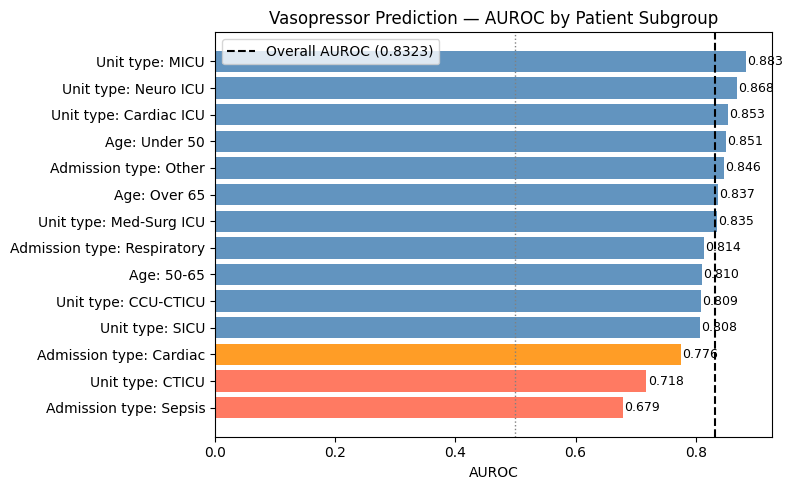

In [19]:
import matplotlib.pyplot as plt
import numpy as np

sg_df = pd.DataFrame(results_sg).sort_values('auroc', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if a >= 0.8 else 'darkorange' if a >= 0.75 else 'tomato'
          for a in sg_df['auroc']]
bars = ax.barh(sg_df['subgroup'], sg_df['auroc'], color=colors, alpha=0.85)
ax.axvline(vaso_test_auroc, color='black', lw=1.5, linestyle='--',
           label=f'Overall AUROC ({vaso_test_auroc:.4f})')
ax.axvline(0.5, color='gray', lw=1, linestyle=':')
ax.set_xlabel('AUROC')
ax.set_title('Vasopressor Prediction — AUROC by Patient Subgroup')
ax.legend()
for bar, val in zip(bars, sg_df['auroc']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('vaso_subgroup_auroc.png', dpi=150)
plt.show()

**Age groups** show moderate variation. Patients under 50 had the highest AUROC (0.8507), while the 50–65 group was the weakest (0.8101). The differences are small enough that age alone does not appear to be a major driver of performance gaps; the model generalises reasonably well across the age spectrum.

The greatest variation in the AUROC results is observed for **unit type**. The patients admitted to MICU had the best AUROC (0.8831), presumably due to hemodynamic predictability of the medical ICU admissions. The next in line were the patients admitted to cardiac ICU (0.8530). In contrast, CTICU had the lowest AUROC (0.7180), because the protocol-driven approach used for the treatment of post-surgical patients is different from that used by others. Thus, post-surgical patients are hard to distinguish from others in terms of vasopressor use within the first six hours of hospital admission (SICU was similar at 0.8077).

**Admission type** tells the most important clinical story. Sepsis admissions had the lowest AUROC (0.6792) despite having the highest vasopressor rate in the cohort (7.9%). Septic deterioration is rapid and unpredictable, which makes it harder to capture from structured tabular data in a short observation window. That said, 0.6792 is still well above chance and represents a meaningful improvement, suggesting the model is picking up some sepsis-relevant signal even if discrimination remains imperfect. Cardiac admissions also underperformed (0.7758), consistent with the CTICU finding above.

In [31]:
import gc

to_del = ['data','model','loaders','dataset','db',
          'train_tbl','val_tbl','test_tbl','test_labeled',
          'best_state','optimizer','loss_fn','ti_test','test_loader',
          'col_stats','col_to_stype','task']
for v in to_del:
    globals().pop(v, None)

gc.collect()
torch.cuda.empty_cache()
allocated = torch.cuda.memory_allocated() / 1024**3
reserved = torch.cuda.memory_reserved()  / 1024**3
print(f'   GPU allocated : {allocated:.2f} GB')
print(f'   GPU reserved: {reserved:.2f} GB')

   GPU allocated : 0.35 GB
   GPU reserved: 1.07 GB


# Third Task: ICD Code Prediction (MIMIC-IV)

At discharge, clinical coders assign ICD codes to every admission, these codes determine how the hospital gets reimbursed, how the patient's condition is recorded in research databases, and what follow-up pathways get triggered. The question I'm asking here is: how well can a model predict which ICD codes will be assigned to an admission? I look at this at two moments in time. First, at admission, when only demographics, registration fields, and the patient's previous hospitalizations are known. Then, in a follow-up experiment, at discharge, when the full in-stay record (labs, procedures, transfers) is available.

## A note on MIMIC-IV timestamps

MIMIC-IV stores times as real calendar datetimes, unlike eICU which uses minute offsets. The years look odd at first, `2158`, `2170`, but this is intentional. PhysioNet deliberately shifts each patient's dates by a random number of years for de-identification. The relative timing between events is preserved, so this doesn't affect anything in the model.

In [4]:
base_dir = MIMIC_DIR

pat_limit = 20_000
n_epochs = 20           
bs = 512
n_nbrs = [128, 128]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'device={device}  epochs={n_epochs}  bs={bs}')

device=cuda  epochs=20  bs=512


In [5]:
time_cols = {
    'admittime','dischtime','deathtime','edregtime','edouttime',
    'intime','outtime','starttime','endtime','storetime',
    'charttime','chartdate','transfertime','startdate',
}

def find_time_col(columns):
    for col in ['admittime','intime','starttime','charttime','chartdate','transfertime','startdate']:
        if col in columns: return col
    return None

def fix_dtypes(df):
    for col in df.columns:
        if col in time_cols:
            df[col] = pd.to_datetime(df[col], errors='coerce').astype('datetime64[ns]')
    m = {'Int64':int,'Int32':int,'Float64':float,'boolean':bool}
    cvt = {}
    for col in df.columns:
        dt = str(df[col].dtype)
        if dt in m:
            if m[dt] in (int,float): df[col] = df[col].fillna(0)
            cvt[col] = m[dt]
    return df.astype(cvt) if cvt else df

def load_csv(base_dir, name):
    path = os.path.join(base_dir, f'{name}.csv')
    if not os.path.exists(path):
        raise FileNotFoundError(f'Missing: {path}')
    print(f'  {name}...', end=' ')
    df = pd.read_csv(path, low_memory=False)
    print(f'{len(df):,} rows')
    return df

def set_col_stypes(db, col_to_stype_dict):
    TEXT = {'long_title','label','category','fluid','param_type','unitname',
            'language','race','marital_status','insurance','admission_type',
            'admission_location','icd_code','icd_version'}
    SKIP = {'subject_id','hadm_id','stay_id','transfer_id','orderid','itemid',
            'labevent_id','row_id'}
    for tbl, cd in col_to_stype_dict.items():
        for col in list(cd):
            if col in SKIP: del cd[col]
            elif col in TEXT: cd[col] = stype.text_embedded
    return col_to_stype_dict

### Building the MIMIC-IV database

`MimicDataset` loads and prepares the MIMIC-IV tables before turning them into a RelBench `Database`. I load the core CSVs, patients, admissions, ICU stays, transfers, diagnoses, procedures, and process `labevents` separately in chunks since it's by far the largest table.

I filter to ICU stays between 1.5 and 10 days. Very short stays don't have enough data to be useful, and extremely long stays behave like outliers. Everything else gets filtered to match the surviving stays so the graph doesn't contain orphan rows.

In [6]:
class MimicDataset(Dataset):
    table_schema = {
        'patients': {'pkey_col':'subject_id', 'fkey_col_to_pkey_table':{}, 'time_col':None},
        'admissions': {'pkey_col':'hadm_id', 'fkey_col_to_pkey_table':{'subject_id':'patients'}, 'time_col':'admittime'},
        'icustays': {'pkey_col':'stay_id', 'fkey_col_to_pkey_table':{'hadm_id':'admissions','subject_id':'patients'}, 'time_col':'intime'},
        'transfers': {'pkey_col':'transfer_id', 'fkey_col_to_pkey_table':{'hadm_id':'admissions','subject_id':'patients'}, 'time_col':'intime'},
        'procedureevents': {'pkey_col':'orderid', 'fkey_col_to_pkey_table':{'hadm_id':'admissions','stay_id':'icustays','subject_id':'patients','itemid':'d_items'}, 'time_col':'starttime'},
        'd_items': {'pkey_col':'itemid', 'fkey_col_to_pkey_table':{}, 'time_col':None},
        'diagnoses_icd': {'pkey_col':None, 'fkey_col_to_pkey_table':{'hadm_id':'admissions','subject_id':'patients'}, 'time_col':None},
        'd_icd_diagnoses': {'pkey_col':'icd_code', 'fkey_col_to_pkey_table':{}, 'time_col':None},
        'd_labitems': {'pkey_col':'itemid', 'fkey_col_to_pkey_table':{}, 'time_col':None},
    }
    leakage_cols = {
        'icustays':['los','outtime','last_careunit'],
        'admissions':['dischtime','deathtime','hospital_expire_flag','discharge_location','edouttime','admit_provider_id'],
        'patients':['dod'],
        'transfers':['outtime'],
        'diagnoses_icd':['seq_num'],
    }
    lab_cols = ['subject_id','hadm_id','itemid','charttime','valuenum','valueuom','flag']

    def __init__(self, base_dir=base_dir, patients_limit=20000):
        super().__init__(cache_dir=None)
        self.base_dir=base_dir; self.patients_limit=patients_limit
        self.val_timestamp=None; self.test_timestamp=None; self.pkey_remaps={}
        self._built_db = self.make_db()

    def get_db(self, upto_test_timestamp=None) -> Database:
        return self._built_db

    def _set_timestamps(self, icustays_df):
        ts = pd.to_datetime(icustays_df['intime'],errors='coerce').dropna().sort_values()
        self.val_timestamp = ts.iloc[int(len(ts)*0.70)]
        self.test_timestamp = ts.iloc[int(len(ts)*0.85)]
        print(f'split: val: {self.val_timestamp.date()}, test: {self.test_timestamp.date()}')

    def make_db(self) -> Database:
        file_names = ['patients','admissions','transfers','diagnoses_icd',
                     'd_icd_diagnoses','d_labitems','icustays','procedureevents','d_items']
        raw = {n: load_csv(self.base_dir, n) for n in file_names}
        lab_path = os.path.join(self.base_dir, 'labevents.csv')
        has_lab = os.path.exists(lab_path)
        if has_lab: print('  labevents found — loading after patient filter (chunked)')
        else:       print('  labevents not found — skipping')

        icu = raw['icustays'].copy()
        icu = icu[icu['los'].between(1.5,10)].copy()
        if self.patients_limit>0:
            pids = icu['subject_id'].drop_duplicates().iloc[:self.patients_limit]
            icu = icu[icu['subject_id'].isin(pids)]
        vs=set(icu['subject_id'].unique()); vh=set(icu['hadm_id'].unique())
        print(f'  Kept {len(vs):,} patients, {len(vh):,} ICU admissions')
        for n in list(raw):
            df=raw[n]
            if 'subject_id' in df.columns: raw[n]=df[df['subject_id'].isin(vs)].copy()
            elif 'hadm_id'   in df.columns: raw[n]=df[df['hadm_id'].isin(vh)].copy()
        raw['icustays']=icu

        if has_lab:
            avail = pd.read_csv(lab_path, nrows=0).columns.tolist()
            rcols = [c for c in self.lab_cols if c in avail]
            chunks=[]
            for chunk in pd.read_csv(lab_path, usecols=rcols, chunksize=500_000, low_memory=False):
                f=chunk[chunk['subject_id'].isin(vs)]
                if len(f)>0: chunks.append(f)
            if chunks:
                raw['labevents'] = pd.concat(chunks, ignore_index=True)
                print(f'  labevents: {len(raw["labevents"]):,} rows')
                max_per_hadm=15; top_items=50
                lab=raw['labevents']
                top_items=lab['itemid'].value_counts().head(top_items).index
                lab=lab[lab['itemid'].isin(top_items)].copy()
                if 'charttime' in lab.columns:
                    lab['charttime']=pd.to_datetime(lab['charttime'],errors='coerce')
                    lab=(lab.sort_values('charttime',ascending=False)
                            .groupby('hadm_id',group_keys=False).head(max_per_hadm)
                            .reset_index(drop=True))
                raw['labevents']=lab
                print(f'  labevents capped: {len(raw["labevents"]):,} rows')
                self.table_schema['labevents']={
                    'pkey_col':None, 'fkey_col_to_pkey_table':{'hadm_id':'admissions','subject_id':'patients','itemid':'d_labitems'}, 'time_col':'charttime'}
            else:
                has_lab=False; print('  labevents: 0 rows matched')

        for n,cols in self.leakage_cols.items():
            if n in raw:
                drop=[c for c in cols if c in raw[n].columns]
                if drop: raw[n]=raw[n].drop(columns=drop); print(f'  {n}: dropped {drop}')
        for n in raw: raw[n]=fix_dtypes(raw[n])

        td={}
        for n,s in self.table_schema.items():
            if n not in raw: continue
            df=raw[n].reset_index(drop=True)
            tc=s['time_col']
            if tc and tc not in df.columns: tc=find_time_col(df.columns.tolist())
            td[n]=Table(df=df,fkey_col_to_pkey_table=s['fkey_col_to_pkey_table'],pkey_col=s['pkey_col'],time_col=tc)
        changed=True
        while changed:
            changed=False
            for n in list(td):
                tbl=td[n]; df=tbl.df.copy()
                for fc,rt in tbl.fkey_col_to_pkey_table.items():
                    if rt not in td or fc not in df.columns: continue
                    rp=td[rt].pkey_col
                    if rp is None or rp not in td[rt].df.columns: continue
                    valid=set(td[rt].df[rp].dropna().values)
                    b=len(df); df=df[df[fc].isin(valid)]
                    if len(df)<b:
                        print(f'  {n}: dropped {b-len(df):,} orphans ({fc}->{rt})')
                        td[n]=Table(df=df.reset_index(drop=True),fkey_col_to_pkey_table=tbl.fkey_col_to_pkey_table,pkey_col=tbl.pkey_col,time_col=tbl.time_col)
                        changed=True; break
        for n,tbl in td.items(): print(f"  '{n}': {len(tbl.df):,} rows")

        pr={}
        for n in list(td):
            tbl=td[n]; pk=tbl.pkey_col
            if pk is None or pk not in tbl.df.columns: continue
            df=tbl.df.copy()
            mapping={v:i for i,v in enumerate(df[pk].values)}
            pr[n]=(pk,mapping)
            df[pk]=np.arange(len(df),dtype=np.int64)
            td[n]=Table(df=df,fkey_col_to_pkey_table=tbl.fkey_col_to_pkey_table,pkey_col=pk,time_col=tbl.time_col)
        for n in list(td):
            tbl=td[n]; df=tbl.df.copy(); chg=False
            for fc,rt in tbl.fkey_col_to_pkey_table.items():
                if rt in pr and fc in df.columns:
                    _,m=pr[rt]; df[fc]=df[fc].map(m).fillna(-1).astype(np.int64); chg=True
            if chg: td[n]=Table(df=df,fkey_col_to_pkey_table=tbl.fkey_col_to_pkey_table,pkey_col=tbl.pkey_col,time_col=tbl.time_col)

        db=Database(td); self.pkey_remaps=pr
        self._set_timestamps(td['icustays'].df)
        return db

In [7]:
dataset = MimicDataset(base_dir=base_dir, patients_limit=20000)
db = dataset.get_db()
print(f'val_timestamp: {dataset.val_timestamp}')
print(f'test_timestamp : {dataset.test_timestamp}')
print(f'Tables: {list(db.table_dict.keys())}')

  patients... 364,627 rows
  admissions... 546,028 rows
  transfers... 2,413,581 rows
  diagnoses_icd... 6,364,488 rows
  d_icd_diagnoses... 112,107 rows
  d_labitems... 1,650 rows
  icustays... 94,458 rows
  procedureevents... 808,706 rows
  d_items... 4,095 rows
  labevents found — loading after patient filter (chunked)
  Kept 20,000 patients, 24,261 ICU admissions
  labevents: 29,836,945 rows
  labevents capped: 1,059,800 rows
  icustays: dropped ['los', 'outtime', 'last_careunit']
  admissions: dropped ['dischtime', 'deathtime', 'hospital_expire_flag', 'discharge_location', 'edouttime', 'admit_provider_id']
  patients: dropped ['dod']
  transfers: dropped ['outtime']
  diagnoses_icd: dropped ['seq_num']
  transfers: dropped 16,585 orphans (hadm_id->admissions)
  procedureevents: dropped 65,281 orphans (stay_id->icustays)
  'patients': 20,000 rows
  'admissions': 77,526 rows
  'icustays': 25,913 rows
  'transfers': 320,445 rows
  'procedureevents': 222,065 rows
  'd_items': 4,095 ro

### Building the ICD graph

I exclude the raw diagnosis tables (`diagnoses_icd`, `d_icd_diagnoses`) from the graph, including them would leak the labels directly into the node features. Everything else goes in.

In [8]:
exclude_cols = {'diagnoses_icd', 'd_icd_diagnoses'}
icd_td = {n:t for n,t in db.table_dict.items() if n not in exclude_cols}
db_icd = Database(icd_td)
col_to_stype_icd = set_col_stypes(db_icd, get_stype_proposal(db_icd))
g_icd, stats_icd = make_pkey_fkey_graph(
    db_icd,
    col_to_stype_dict=col_to_stype_icd,
    text_embedder_cfg=text_embedder_cfg,
)

print('\nICD graph built')
for ntype in g_icd.node_types:
    tf = g_icd[ntype].get('tf', None)
    if tf is not None:
        ncols = sum(len(v) for v in tf.col_names_dict.values())
    else:
        ncols = 'n/a'
    print(f'  {ntype}  nodes={g_icd[ntype].num_nodes:,}  feat_cols={ncols}')

Embedding raw data in mini-batch: 100%|██████████| 4140/4140 [00:16<00:00, 253.61it/s]



ICD graph built
  patients  nodes=20,000  feat_cols=4
  admissions  nodes=77,526  feat_cols=8
  icustays  nodes=25,913  feat_cols=2
  transfers  nodes=320,445  feat_cols=3
  procedureevents  nodes=222,065  feat_cols=17
  d_items  nodes=4,095  feat_cols=8
  d_labitems  nodes=1,650  feat_cols=3
  labevents  nodes=1,059,800  feat_cols=4


### Model and task setup

Same architecture as the eICU tasks, HeteroGraphSAGE with a MLP head, but the head now outputs 50 logits.

In [9]:
class Model(torch.nn.Module):
    def __init__(self, data, col_stats_dict, num_layers, channels, out_channels,
                 aggr=['mean', 'min', 'max'], norm='batch_norm', dropout=0.3):
        super().__init__()
        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={nt: data[nt].tf.col_names_dict for nt in data.node_types},
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[n for n in data.node_types if data[n].get('time', None) is not None],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types, edge_types=data.edge_types,
            channels=channels, aggr=aggr, num_layers=num_layers,
        )
        self.head = MLP(in_channels=channels, hidden_channels=channels,
                        out_channels=out_channels, num_layers=1, norm=norm)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, batch, entity_table):
        x = self.encoder(batch.tf_dict)
        rt = self.temporal_encoder(batch[entity_table].seed_time, batch.time_dict, batch.batch_dict)
        for nt in rt: x[nt] = x[nt] + rt[nt]
        x = self.gnn(x, batch.edge_index_dict)
        return self.head(self.dropout(x[entity_table][:batch[entity_table].batch_size]))


In [10]:
class ICDTask(EntityTask):
    task_type = TaskType.BINARY_CLASSIFICATION
    entity_col = 'hadm_id'
    entity_table = 'admissions'
    time_col = 'admittime'
    target_col = 'icd_label'
    timedelta = pd.Timedelta(days=1)
    metrics = [roc_auc]
    top_k = 50

    def __init__(self, *a, **k):
        super().__init__(*a, **k)
        self.test_timestamp = self.dataset.test_timestamp
        self.val_timestamp = self.dataset.val_timestamp
        if self.test_timestamp and self.val_timestamp:
            self.num_eval_timestamps = max(
                1, int((self.test_timestamp - self.val_timestamp) / self.timedelta))
        diag = pd.read_csv(os.path.join(base_dir, 'diagnoses_icd.csv'),
                           usecols=['hadm_id', 'icd_code'])
        self.top_codes = list(diag['icd_code'].value_counts().head(self.top_k).index)
        self.code_map = {c: i for i, c in enumerate(self.top_codes)}
        self._raw_adm = pd.read_csv(os.path.join(base_dir, 'admissions.csv'),
                                     usecols=['hadm_id', 'admittime'])
        self._raw_adm['admittime'] = pd.to_datetime(self._raw_adm['admittime'])
        self._diag = diag[diag['icd_code'].isin(self.top_codes)]
        print(f'Top-{self.top_k} ICD codes loaded. Most common: {self.top_codes[:5]}')

    def make_table(self, db, timestamps):
        ts_df = pd.DataFrame({'timestamp': timestamps})
        raw_adm = self._raw_adm
        diag = self._diag
        df = duckdb.sql("""
            SELECT a.hadm_id AS hadm_id_orig, a.admittime
            FROM ts_df t JOIN raw_adm a
              ON a.admittime > t.timestamp
             AND a.admittime <= t.timestamp + INTERVAL '1 DAY'
            WHERE a.hadm_id IS NOT NULL
        """).df()
        df['admittime'] = pd.to_datetime(df['admittime']).astype('datetime64[ns]')
        hm = self.dataset.pkey_remaps.get('admissions', (None, {}))[1]
        df['hadm_id'] = df['hadm_id_orig'].map(hm)
        df = df.dropna(subset=['hadm_id'])
        df['hadm_id'] = df['hadm_id'].astype(np.int64)
        dbh = diag.groupby('hadm_id')['icd_code'].apply(list).reset_index()
        df = df.merge(dbh, left_on='hadm_id_orig', right_on='hadm_id',
                       how='left', suffixes=('', '_d'))
        df['icd_code']  = df['icd_code'].apply(lambda x: x if isinstance(x, list) else [])
        df['icd_label'] = df['icd_code'].apply(lambda x: 1 if len(x) > 0 else 0)
        cm, tk = self.code_map, self.top_k
        def mh(codes):
            v = np.zeros(tk, dtype=np.float32)
            for c in codes:
                if c in cm: v[cm[c]] = 1.0
            return v
        df['icd_multilabel'] = df['icd_code'].apply(mh)
        return Table(
            df=df[['hadm_id', 'admittime', 'icd_label', 'icd_multilabel']],
            fkey_col_to_pkey_table={self.entity_col: self.entity_table},
            pkey_col=None, time_col=self.time_col)

icd_task = ICDTask(dataset)
print(icd_task)

Top-50 ICD codes loaded. Most common: ['4019', 'E785', 'I10', '2724', 'Z87891']
ICDTask(dataset=MimicDataset())


In [11]:
tr_icd = icd_task.get_table('train')
va_icd = icd_task.get_table('val')
te_icd = icd_task.get_table('test')
print(f'Train: {len(tr_icd.df):,}  | Val: {len(va_icd.df):,}  | Test: {len(te_icd.df):,}')
print(f'Avg ICD codes/admission (train): {tr_icd.df["icd_multilabel"].apply(sum).mean():.2f}')

Making task table for train split from scratch...
Done in 8.58 seconds.
Making task table for val split from scratch...
Done in 7.40 seconds.
Making task table for test split from scratch...
Done in 7.74 seconds.
Train: 52,211  | Val: 11,716  | Test: 9,483
Avg ICD codes/admission (train): 3.94


In [12]:
def build_loaders(data, task, tr, va, te, batch_size=bs, seed=42):
    out = {}
    for split, tbl in [('train', tr), ('val', va), ('test', te)]:
        node_inp = get_node_train_table_input(table=tbl, task=task)
        g = torch.Generator(); g.manual_seed(seed)
        out[split] = NeighborLoader(
            data, num_neighbors=n_nbrs, time_attr='time',
            input_nodes=node_inp.nodes, input_time=node_inp.time,
            transform=node_inp.transform,
            batch_size=batch_size, temporal_strategy='uniform',
            shuffle=(split == 'train'), num_workers=0, persistent_workers=False,
            generator=g)
    return out

icd_ld = build_loaders(g_icd, icd_task, tr_icd, va_icd, te_icd)

n_adm = db_icd.table_dict['admissions'].df.shape[0]
lbl_mat = np.zeros((n_adm, icd_task.top_k), dtype=np.float32)
for t in [tr_icd, va_icd]:
    for _, row in t.df.iterrows():
        idx2 = int(row['hadm_id'])
        if 0 <= idx2 < n_adm:
            lbl_mat[idx2] = row['icd_multilabel']

n_ts = max(1, icd_task.num_eval_timestamps)
test_ts = pd.date_range(icd_task.dataset.test_timestamp,
                                  periods=n_ts, freq=icd_task.timedelta)
te_icd_lbl = icd_task.make_table(dataset.get_db(), test_ts)
for _, row in te_icd_lbl.df.iterrows():
    idx2 = int(row['hadm_id'])
    if 0 <= idx2 < n_adm:
        lbl_mat[idx2] = row['icd_multilabel']
lbl_mat = np.clip(lbl_mat, 0, 1)

print(f'Label matrix shape : {lbl_mat.shape}')
print(f'Label density: {lbl_mat.mean():.3%}')
print(f'Batches — train: {len(icd_ld["train"])}  '
      f'val: {len(icd_ld["val"])}  '
      f'test: {len(icd_ld["test"])}')

Label matrix shape : (77526, 50)
Label density: 7.477%
Batches — train: 102  val: 23  test: 19


In [13]:
def train_epoch(model, loader, optimizer, loss_fn, task, lbl_mat, device, verbose=True):
    model.train(); total = 0
    for batch in tqdm(loader, desc='  train', leave=False, disable=not verbose):
        batch = batch.to(device)
        bs = batch[task.entity_table].batch_size
        logits = model(batch, task.entity_table)[:bs]
        nids = batch[task.entity_table].n_id[:bs].cpu().numpy()
        y = torch.tensor(lbl_mat[nids], dtype=torch.float32).to(device)
        loss = loss_fn(logits, y)
        loss.backward(); optimizer.step(); optimizer.zero_grad()
        total += loss.item()
    return total / len(loader)

@torch.no_grad()
def eval_metrics(model, loader, task, lbl_mat, device):
    model.eval(); ap, al = [], []
    for batch in loader:
        batch = batch.to(device)
        bs = batch[task.entity_table].batch_size
        probs = torch.sigmoid(
            model(batch, task.entity_table)[:bs]).cpu().numpy()
        nids = batch[task.entity_table].n_id[:bs].cpu().numpy()
        ap.append(probs); al.append(lbl_mat[nids])
    P = np.vstack(ap); L = np.vstack(al)
    valid = []
    for c in range(L.shape[1]):
        if L[:, c].sum() > 0:
            valid.append(c)
    auroc = float(np.mean([roc_auc_score(L[:, c], P[:, c]) for c in valid]))
    auprc = float(np.mean([average_precision_score(L[:, c], P[:, c]) for c in valid]))
    return auroc, auprc

def eval_macro_auc(model, loader, task, lbl_mat, device):
    return eval_metrics(model, loader, task, lbl_mat, device)[0]

### Hyperparameter search

I run a small grid search over positive weight, learning rate, and channel width before committing to a full training run.

In [31]:
make_reproducible(42)

import itertools, gc
from tqdm import tqdm

search_ep = 10

search_space = {
    'pos_weight_val': [1.0, 2.0, 5.0, 10.0],
    'lr':             [1e-4, 3e-4, 1e-3],
    'channels':       [64, 128, 256],
}

configs = []
for vals in itertools.product(*search_space.values()):
    configs.append(dict(zip(search_space.keys(), vals)))
n_configs = len(configs)

print(f'Grid search: {n_configs} configs x {search_ep} epochs each')
print(f' pos_w   lr   ch   val_auc')
print('-' * 38)

grid_res = []
for idx, cfg in enumerate(configs):
    pw = torch.full((icd_task.top_k,), cfg['pos_weight_val'], dtype=torch.float32).to(device)
    m_s = Model(data=g_icd, col_stats_dict=stats_icd, num_layers=2,
                  channels=cfg['channels'], out_channels=icd_task.top_k,
                  aggr=['mean', 'min', 'max'], norm='batch_norm', dropout=0.3).to(device)
    opt_s = torch.optim.Adam(m_s.parameters(), lr=cfg['lr'], weight_decay=1e-4)
    lf_s = nn.BCEWithLogitsLoss(pos_weight=pw)
    ld_s = build_loaders(g_icd, icd_task, tr_icd, va_icd, te_icd)

    best_auroc = 0.0
    for ep in tqdm(range(1, search_ep + 1),
                   desc=f'  cfg {idx+1}/{n_configs}', leave=False):
        train_epoch(m_s, ld_s['train'], opt_s, lf_s, icd_task, lbl_mat, device, verbose=False)
        va, _ = eval_metrics(m_s, ld_s['val'], icd_task, lbl_mat, device)
        if va > best_auroc:
            best_auroc = va

    print(f'{idx+1:>3}  {cfg["pos_weight_val"]:>6.1f}  {cfg["lr"]:>8.4f}  '
          f'{cfg["channels"]}  {best_auroc:>10.4f}')
    grid_res.append({**cfg, 'val_auroc': best_auroc})

    del m_s, opt_s, lf_s, ld_s
    gc.collect(); torch.cuda.empty_cache()

best_cfg = max(grid_res, key=lambda x: x['val_auroc'])
print(f'\nBest config (val AUROC = {best_cfg["val_auroc"]:.4f}):')
print(f'  pos_weight = {best_cfg["pos_weight_val"]}')
print(f'  lr = {best_cfg["lr"]}')
print(f'  channels = {best_cfg["channels"]}')

Grid search: 36 configs x 10 epochs each
 pos_w   lr   ch   val_auc
--------------------------------------


  1     1.0    0.0001  64      0.7231


  2     1.0    0.0001  128      0.7946


  3     1.0    0.0001  256      0.8241


  4     1.0    0.0003  64      0.7965


...

 32    10.0    0.0003  128      0.8338


 33    10.0    0.0003  256      0.8367


 34    10.0    0.0010  64      0.8318


 35    10.0    0.0010  128      0.8349


 36    10.0    0.0010  256      0.8345

Best config (val AUROC = 0.8367):
  pos_weight = 10.0
  lr = 0.0003
  channels = 256


In [32]:
make_reproducible(42)

pos_weight_tensor = torch.full(
    (icd_task.top_k,), best_cfg['pos_weight_val'], dtype=torch.float32).to(device)

model_icd = Model(data=g_icd, col_stats_dict=stats_icd, num_layers=2,
                      channels=best_cfg['channels'], out_channels=icd_task.top_k,
                      aggr=['mean', 'min', 'max'], norm='batch_norm', dropout=0.3).to(device)
optimizer_icd = torch.optim.Adam(model_icd.parameters(), lr=best_cfg['lr'], weight_decay=1e-4)
loss_fn_icd = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
icd_ld = build_loaders(g_icd, icd_task, tr_icd, va_icd, te_icd)

print(f'model params: {sum(p.numel() for p in model_icd.parameters()):,}')
print(f'Channels: {best_cfg["channels"]}')
print(f'pos_weight: {best_cfg["pos_weight_val"]} (uniform across all 50 codes)')
print()

best_val = 0.0
best_state = None
save_path = '/kaggle/working/best_model_icd.pt'

print(f"ep  loss  val_auc  val_auprc")
print('-' * 36)

for ep in range(1, n_epochs + 1):
    tl = train_epoch(model_icd, icd_ld['train'],
                             optimizer_icd, loss_fn_icd, icd_task, lbl_mat, device)
    va, va_prc = eval_metrics(model_icd, icd_ld['val'],
                              icd_task, lbl_mat, device)
    print(f'{ep}  {tl:>8.4f}  {va:>10.4f}  {va_prc:>10.4f}')
    if va > best_val:
        best_val = va
        best_state = copy.deepcopy(model_icd.state_dict())
        torch.save(best_state, save_path)

print(f'\nBest Val AUROC : {best_val:.4f}')

model params: 16,634,546
Channels: 256
pos_weight: 10.0 (uniform across all 50 codes)

ep  loss  val_auc  val_auprc
------------------------------------


1    0.9439      0.8034      0.2068


2    0.8078      0.8160      0.2207


3    0.7791      0.8237      0.2308


4    0.7601      0.8303      0.2401


...

16    0.6782      0.8382      0.2600


17    0.6754      0.8386      0.2616


18    0.6696      0.8391      0.2624


19    0.6700      0.8383      0.2615


20    0.6677      0.8385      0.2611

Best Val AUROC : 0.8403


In [33]:
from sklearn.metrics import f1_score as sk_f1

@torch.no_grad()
def full_metrics(model, loader, task, lbl_mat, device, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        bs = batch[task.entity_table].batch_size
        probs = torch.sigmoid(
            model(batch, task.entity_table)[:bs]).cpu().numpy()
        nids = batch[task.entity_table].n_id[:bs].cpu().numpy()
        all_probs.append(probs); all_labels.append(lbl_mat[nids])
    P = np.vstack(all_probs)
    L = np.vstack(all_labels)
    valid = []
    for c in range(L.shape[1]):
        if L[:, c].sum() > 0:
            valid.append(c)
    Lv, Pv = L[:, valid], P[:, valid]
    per_auroc = [roc_auc_score(Lv[:, i], Pv[:, i]) for i in range(len(valid))]
    per_auprc = [average_precision_score(Lv[:, i], Pv[:, i]) for i in range(len(valid))]
    Pbin = (P >= threshold).astype(int)
    code_aurocs = sorted(zip(valid, per_auroc), key=lambda x: x[1])
    return {
        'macro_auroc': float(np.mean(per_auroc)),
        'micro_auroc': float(roc_auc_score(Lv, Pv, average='micro')),
        'macro_auprc': float(np.mean(per_auprc)),
        'macro_f1':    float(sk_f1(L, Pbin, average='macro',   zero_division=0)),
        'micro_f1':    float(sk_f1(L, Pbin, average='micro',   zero_division=0)),
        'sample_f1':   float(sk_f1(L, Pbin, average='samples', zero_division=0)),
        'good_codes':  sum(1 for a in per_auroc if a > 0.75),
        'n_valid':     len(valid),
        'best5':       code_aurocs[-5:][::-1],
        'worst5':      code_aurocs[:5],
    }

model_icd.load_state_dict(best_state)
m = full_metrics(model_icd, icd_ld['test'], icd_task, lbl_mat, device)
tl = icd_task.top_codes

print(f'--- ICD prediction (MIMIC-IV, top-{icd_task.top_k}) ---')
print(f'{len(tr_icd.df):,} / {len(va_icd.df):,} / {len(te_icd.df):,}')
print(f'macro-AUROC={m["macro_auroc"]:.4f}  micro-AUROC={m["micro_auroc"]:.4f}  macro-AUPRC={m["macro_auprc"]:.4f}')
print(f'macro-F1={m["macro_f1"]:.4f}  micro-F1={m["micro_f1"]:.4f}  sample-F1={m["sample_f1"]:.4f}')
print(f'codes AUROC>0.75: {m["good_codes"]}/{m["n_valid"]}')

icd_test_auroc = m['macro_auroc']
icd_test_auprc = m['macro_auprc']

--- ICD prediction (MIMIC-IV, top-50) ---
52,211 / 11,716 / 9,483
macro-AUROC=0.8407  micro-AUROC=0.8653  macro-AUPRC=0.2708
macro-F1=0.3120  micro-F1=0.3376  sample-F1=0.3117
codes AUROC>0.75: 50/50


In [34]:
@torch.no_grad()
def get_probs(model, loader, lbl_mat, device):
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        bs = batch[icd_task.entity_table].batch_size
        probs = torch.sigmoid(model(batch, icd_task.entity_table)[:bs]).cpu().numpy()
        nids = batch[icd_task.entity_table].n_id[:bs].cpu().numpy()
        all_probs.append(probs)
        all_labels.append(lbl_mat[nids])
    return np.vstack(all_probs), np.vstack(all_labels)

val_probs, val_labels_mat = get_probs(model_icd, icd_ld['val'], lbl_mat, device)
test_probs, test_labels_mat = get_probs(model_icd, icd_ld['test'], lbl_mat, device)

thresholds = np.arange(0.05, 0.60, 0.01)
best_t, best_f1 = 0.5, 0.0
for t in thresholds:
    preds_bin = (val_probs >= t).astype(int)
    f1 = sk_f1(val_labels_mat, preds_bin, average='macro', zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f'best threshold (from val macro-F1): {best_t:.2f}')
print(f'val macro-F1 at best threshold: {best_f1:.4f}')

test_bin = (test_probs >= best_t).astype(int)
test_macro_f1 = sk_f1(test_labels_mat, test_bin, average='macro', zero_division=0)
test_micro_f1 = sk_f1(test_labels_mat, test_bin, average='micro', zero_division=0)
test_sample_f1 = sk_f1(test_labels_mat, test_bin, average='samples', zero_division=0)

print()
print(f'--- ICD results at tuned threshold (t={best_t:.2f}) ---')
print(f'macro-F1:  {test_macro_f1:.4f}  (was {m["macro_f1"]:.4f} at t=0.5)')
print(f'micro-F1:  {test_micro_f1:.4f}  (was {m["micro_f1"]:.4f} at t=0.5)')
print(f'sample-F1: {test_sample_f1:.4f}  (was {m["sample_f1"]:.4f} at t=0.5)')

best threshold (from val macro-F1): 0.59
val macro-F1 at best threshold: 0.3150

--- ICD results at tuned threshold (t=0.59) ---
macro-F1:  0.3229  (was 0.3120 at t=0.5)
micro-F1:  0.3665  (was 0.3376 at t=0.5)
sample-F1: 0.3307  (was 0.3117 at t=0.5)


## Results

ICD code prediction is a **multi-label** classification problem, as each admission can be assigned multiple diagnosis codes. I therefore report **macro-AUROC**, which gives equal weight to each of the 50 codes, and **micro-AUROC**, which aggregates predictions across all label-instance pairs and is therefore influenced more by frequent codes. I also report **macro-, micro-, and sample-F1** scores at both the default threshold (**0.5**) and a tuned threshold selected by maximising macro-F1 on the validation set.

The model was trained to predict the **50 most frequent ICD codes**. The test set results are shown below.

| Metric                  |  Score |
| ----------------------- | -----: |
| Macro-AUROC             | 0.8407 |
| Micro-AUROC             | 0.8653 |
| Macro-AUPRC             | 0.2708 |
| Macro-F1 (t = 0.50)     | 0.3120 |
| Micro-F1 (t = 0.50)     | 0.3376 |
| Sample-F1 (t = 0.50)    | 0.3117 |
| Tuned threshold         |   0.59 |
| Macro-F1 (t = 0.59)     | 0.3229 |
| Micro-F1 (t = 0.59)     | 0.3665 |
| Sample-F1 (t = 0.59)    | 0.3307 |
| Codes with AUROC > 0.75 |  50/50 |

The model achieves a **macro-AUROC of 0.8407** and a **micro-AUROC of 0.8653**, indicating strong discrimination across the 50 ICD codes. Furthermore, every code achieves an individual AUROC above **0.75**, suggesting that the model performs consistently well across the entire label set rather than only on the most common diagnoses.

The **macro-AUPRC of 0.2708** is lower than the AUROC values, which is expected in a sparse multi-label setting where each admission is typically associated with only a small number of diagnosis codes.

Threshold tuning provides a modest improvement in classification performance. Increasing the decision threshold from **0.50** to **0.59** raises the **macro-F1** from **0.3120** to **0.3229**, while **micro-F1** improves from **0.3376** to **0.3665** and **sample-F1** from **0.3117** to **0.3307**. The relatively small improvement suggests that the model's predicted probabilities are already reasonably well calibrated, requiring only a minor adjustment to improve overall performance.


## Ablation, Label Space Scaling (top-50 → top-100 → top-200)

The top-50 setup is a reasonable starting point but I want to know what happens when I widen the label space.

In [35]:
def run_icd_ablation(top_k, num_epochs=20):
    print(f'ICD ablation — top-{top_k} codes')
    print('-' * 40)
    ICDTask.top_k = top_k
    task = ICDTask(dataset)
    train_t = task.get_table('train')
    val_t   = task.get_table('val')
    test_t  = task.get_table('test')

    n_adm = db_icd.table_dict['admissions'].df.shape[0]
    lbl = np.zeros((n_adm, top_k), dtype=np.float32)
    for t in [train_t, val_t]:
        for _, row in t.df.iterrows():
            idx = int(row['hadm_id'])
            if 0 <= idx < n_adm:
                lbl[idx] = row['icd_multilabel']
    n_ts = max(1, task.num_eval_timestamps)
    test_ts = pd.date_range(task.dataset.test_timestamp,
                            periods=n_ts, freq=task.timedelta)
    test_labeled = task.make_table(dataset.get_db(), test_ts)
    for _, row in test_labeled.df.iterrows():
        idx = int(row['hadm_id'])
        if 0 <= idx < n_adm:
            lbl[idx] = row['icd_multilabel']
    lbl = np.clip(lbl, 0, 1)

    loaders = build_loaders(g_icd, task, train_t, val_t, test_t)
    pw_tensor = torch.full((top_k,), best_cfg['pos_weight_val'],
                           dtype=torch.float32).to(device)
    m = Model(data=g_icd, col_stats_dict=stats_icd, num_layers=2,
              channels=best_cfg['channels'], out_channels=top_k,
              aggr=['mean', 'min', 'max'], norm='batch_norm', dropout=0.3).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=best_cfg['lr'], weight_decay=1e-4)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw_tensor)

    print(f'  train={len(train_t.df):,}  val={len(val_t.df):,}  density={lbl.mean():.3%}')
    print(f"ep  loss  val_auc  val_auprc")
    print('-' * 36)

    best_val = 0.0; best_state = None
    for ep in range(1, num_epochs + 1):
        tl = train_epoch(m, loaders['train'], opt, loss_fn, task, lbl, device)
        va, vp = eval_metrics(m, loaders['val'], task, lbl, device)
        print(f'{ep}  {tl:.4f}  {va:.4f}  {vp:.4f}')
        if va > best_val:
            best_val = va
            best_state = copy.deepcopy(m.state_dict())
    m.load_state_dict(best_state)
    test_auroc, test_auprc = eval_metrics(m, loaders['test'], task, lbl, device)
    print(f'test AUROC={test_auroc:.4f}  AUPRC={test_auprc:.4f}')
    return {
        'top_k': top_k, 'best_val_auroc': best_val,
        'test_auroc': test_auroc, 'test_auprc': test_auprc,
        'label_density': float(lbl.mean()), 'n_train': len(train_t.df),
    }

result_50 = {
    'top_k': 50, 'best_val_auroc': best_val,
    'test_auroc': icd_test_auroc, 'test_auprc': icd_test_auprc,
    'label_density': float(lbl_mat.mean()), 'n_train': len(tr_icd.df),
}
result_100 = run_icd_ablation(top_k=100, num_epochs=20)
result_200 = run_icd_ablation(top_k=200, num_epochs=20)

ICDTask.top_k = 50


ICD ablation — top-100 codes
----------------------------------------
Top-100 ICD codes loaded. Most common: ['4019', 'E785', 'I10', '2724', 'Z87891']
Making task table for train split from scratch...
Done in 7.71 seconds.
Making task table for val split from scratch...
Done in 7.58 seconds.
Making task table for test split from scratch...
Done in 7.20 seconds.
  train=52,211  val=11,716  density=5.307%
ep  loss  val_auc  val_auprc
------------------------------------


1  0.8152  0.7957  0.1437


2  0.6883  0.8204  0.1680


3  0.6567  0.8323  0.1856


4  0.6398  0.8340  0.1931


...

16  0.4623  0.8492  0.1569


17  0.4603  0.8472  0.1543


18  0.4592  0.8488  0.1561


19  0.4569  0.8493  0.1574


20  0.4553  0.8486  0.1575
test AUROC=0.8466  AUPRC=0.1610


| Label Space | Macro-AUROC | Macro-AUPRC |
| ----------- | ----------: | ----------: |
| Top-50      |      0.8407 |      0.2708 |
| Top-100     |      0.8429 |      0.2082 |
| Top-200     |      0.8466 |      0.1610 |

As the label space expands from the top 50 to the top 200 ICD codes, the **macro-AUROC** remains consistently high and even shows a slight increase, from **0.8407** to **0.8466**. Although this may seem counterintuitive, AUROC measures the model's ability to rank positive examples above negative ones rather than the accuracy of its predicted labels. The additional, less frequent codes may be easier to distinguish in some cases, contributing to the overall average.

In contrast, the **macro-AUPRC** decreases steadily from **0.2708** for the top-50 setting to **0.1610** for the top-200 setting. This is expected because expanding the label space introduces many rarer diagnosis codes, each with fewer positive training examples. As a result, maintaining high precision becomes increasingly difficult. Overall, these results suggest that while the model continues to discriminate well between positive and negative cases, its ability to make precise predictions declines as the number of possible labels increases.


## Ablation, Principal Diagnosis Prediction (Single-Label)

Here I simplify from multi-label to single-label. Instead of predicting all ICD codes assigned to a patient, the model only predicts the **principal diagnosis**, the main reason the patient was admitted.


In [42]:
class PrincipalDiagnosisTask(EntityTask):
    task_type = TaskType.BINARY_CLASSIFICATION  
    entity_col = 'hadm_id'
    entity_table = 'admissions'
    time_col = 'admittime'
    target_col = 'principal_dummy'  
    timedelta = pd.Timedelta(days=1)
    metrics = [roc_auc]
    top_k = 50
    def __init__(self, *a, **k):
        super().__init__(*a, **k)
        self.test_timestamp = self.dataset.test_timestamp
        self.val_timestamp = self.dataset.val_timestamp
        if self.test_timestamp and self.val_timestamp:
            self.num_eval_timestamps = max(
                1, int((self.test_timestamp - self.val_timestamp) / self.timedelta))
        diag = pd.read_csv(os.path.join(base_dir, 'diagnoses_icd.csv'),
                           usecols=['hadm_id', 'icd_code', 'seq_num'])
        principal = diag[diag['seq_num'] == 1]
        self.top_codes = list(principal['icd_code'].value_counts().head(self.top_k).index)
        self.code_map = {c: i for i, c in enumerate(self.top_codes)}
        self._principal = principal[principal['icd_code'].isin(self.top_codes)][['hadm_id','icd_code']]
        print(f'Top-{self.top_k} principal codes (seq_num=1). '
              f'Most common: {self.top_codes[:5]}')
    def make_table(self, db, timestamps):
        ts_df = pd.DataFrame({'timestamp': timestamps})
        raw_adm = pd.read_csv(os.path.join(base_dir, 'admissions.csv'),
                               usecols=['hadm_id', 'admittime'])
        raw_adm['admittime'] = pd.to_datetime(raw_adm['admittime'])
        df = duckdb.sql("""
            SELECT a.hadm_id AS hadm_id_orig, a.admittime
            FROM ts_df t JOIN raw_adm a
              ON a.admittime > t.timestamp
             AND a.admittime <= t.timestamp + INTERVAL '1 DAY'
            WHERE a.hadm_id IS NOT NULL
        """).df()
        df['admittime'] = pd.to_datetime(df['admittime']).astype('datetime64[ns]')
        hm = self.dataset.pkey_remaps.get('admissions', (None, {}))[1]
        df['hadm_id'] = df['hadm_id_orig'].map(hm)
        df = df.dropna(subset=['hadm_id'])
        df['hadm_id'] = df['hadm_id'].astype(np.int64)
        df = df.merge(self._principal, left_on='hadm_id_orig',
                      right_on='hadm_id', how='inner', suffixes=('', '_d'))
        df['principal_code_idx'] = df['icd_code'].map(self.code_map)
        df = df.dropna(subset=['principal_code_idx'])
        df['principal_code_idx'] = df['principal_code_idx'].astype(np.int64)
        df['principal_dummy']    = 1  
        return Table(
            df=df[['hadm_id', 'admittime', 'principal_dummy', 'principal_code_idx']],
            fkey_col_to_pkey_table={self.entity_col: self.entity_table},
            pkey_col=None, time_col=self.time_col)

prin_task = PrincipalDiagnosisTask(dataset)
top_k_p = prin_task.top_k
tr_p = prin_task.get_table('train')
va_p = prin_task.get_table('val')
te_p = prin_task.get_table('test')
print(f'Split — Train:{len(tr_p.df):,}  Val:{len(va_p.df):,}  Test:{len(te_p.df):,}')
n_adm_p = db_icd.table_dict['admissions'].df.shape[0]
prin_lbl = np.full(n_adm_p, -1, dtype=np.int64)
for tbl in [tr_p, va_p]:
    for _, row in tbl.df.iterrows():
        idx = int(row['hadm_id'])
        if 0 <= idx < n_adm_p:
            prin_lbl[idx] = int(row['principal_code_idx'])
n_ts_p = max(1, prin_task.num_eval_timestamps)
test_ts_p = pd.date_range(prin_task.dataset.test_timestamp,
                          periods=n_ts_p, freq=prin_task.timedelta)
te_p_lbl = prin_task.make_table(dataset.get_db(), test_ts_p)
for _, row in te_p_lbl.df.iterrows():
    idx = int(row['hadm_id'])
    if 0 <= idx < n_adm_p:
        prin_lbl[idx] = int(row['principal_code_idx'])
labeled = (prin_lbl >= 0).sum()
print(f'Labeled admissions : {labeled:,} / {n_adm_p:,}')
code_counts = pd.Series(prin_lbl[prin_lbl >= 0]).value_counts()
print(f'\nTop-5 classes by frequency (class_idx → count):')
for cidx, cnt in code_counts.head(5).items():
    code = prin_task.top_codes[cidx]
    print(f'  class {cidx}  ({code})  {cnt:,} admissions')

def train_principal_epoch(model, loader, optimizer, loss_fn, task, labels, device, verbose=True):
    model.train(); total = 0; n_batches = 0
    for batch in tqdm(loader, desc='  train', leave=False, disable=not verbose):
        batch = batch.to(device)
        bs = batch[task.entity_table].batch_size
        logits = model(batch, task.entity_table)[:bs]
        nids = batch[task.entity_table].n_id[:bs].cpu().numpy()
        y = torch.tensor(labels[nids], dtype=torch.long).to(device)
        valid = y >= 0
        if valid.sum() == 0:
            continue
        loss = loss_fn(logits[valid], y[valid])
        loss.backward(); optimizer.step(); optimizer.zero_grad()
        total += loss.item(); n_batches += 1
    return total / max(n_batches, 1)

@torch.no_grad()
def eval_principal(model, loader, task, labels, device):
    model.eval()
    all_probs, all_targets = [], []
    for batch in loader:
        batch = batch.to(device)
        bs = batch[task.entity_table].batch_size
        logits = model(batch, task.entity_table)[:bs]
        nids = batch[task.entity_table].n_id[:bs].cpu().numpy()
        y = labels[nids]
        valid = y >= 0
        if valid.sum() == 0:
            continue
        probs = torch.softmax(logits[torch.from_numpy(valid).to(device)],
                              dim=-1).cpu().numpy()
        all_probs.append(probs)
        all_targets.append(y[valid])
    if not all_probs:
        return 0.0, 0.0
    P = np.vstack(all_probs)
    L = np.concatenate(all_targets)
    top1 = float((P.argmax(axis=1) == L).mean())
    top5 = float(np.mean([L[i] in P[i].argsort()[-5:] for i in range(len(L))]))
    return top1, top5

Top-50 principal codes (seq_num=1). Most common: ['78650', '41401', '78659', 'A419', '30500']
Making task table for train split from scratch...
Done in 1.21 seconds.
Making task table for val split from scratch...
Done in 1.17 seconds.
Making task table for test split from scratch...
Done in 1.15 seconds.
Split — Train:12,747  Val:2,868  Test:2,284
Labeled admissions : 17,898 / 77,526

Top-5 classes by frequency (class_idx → count):
  class 3  (A419)  1,317 admissions
  class 1  (41401)  1,026 admissions
  class 13  (0389)  881 admissions
  class 11  (I130)  851 admissions
  class 8  (5849)  684 admissions


In [43]:
make_reproducible(42)
search_space_p = {
    'lr':       [1e-4, 3e-4, 1e-3],
    'channels': [64, 128, 256],
}
p_configs = [dict(zip(search_space_p.keys(), v))
             for v in itertools.product(*search_space_p.values())]
print(f'Principal dx grid search: {len(p_configs)} configs x 10 epochs')
print(f'  lr    ch   top1')
print('-' * 32)
p_grid_res = []
for idx, cfg in enumerate(p_configs):
    m_s = Model(data=g_icd, col_stats_dict=stats_icd,
                num_layers=2, channels=cfg['channels'], out_channels=top_k_p,
                aggr=['mean', 'min', 'max'], norm='batch_norm', dropout=0.3).to(device)
    opt_s = torch.optim.Adam(m_s.parameters(), lr=cfg['lr'], weight_decay=1e-4)
    lf_s = nn.CrossEntropyLoss()
    ld_s = build_loaders(g_icd, prin_task, tr_p, va_p, te_p)
    best_t1 = 0.0
    for ep in tqdm(range(1, 11), desc=f'  cfg {idx+1}/{len(p_configs)}', leave=False):
        train_principal_epoch(m_s, ld_s['train'], opt_s, lf_s, prin_task, prin_lbl, device, verbose=False)
        t1, _ = eval_principal(m_s, ld_s['val'], prin_task, prin_lbl, device)
        if t1 > best_t1:
            best_t1 = t1
    print(f'{idx+1:>3}  {cfg["lr"]:>8.4f}  {cfg["channels"]}  {best_t1:>8.4f}')
    p_grid_res.append({**cfg, 'val_top1': best_t1})
    del m_s, opt_s, lf_s, ld_s
    gc.collect(); torch.cuda.empty_cache()

best_p_cfg = max(p_grid_res, key=lambda x: x['val_top1'])
print(f'\nBest config (val top-1 = {best_p_cfg["val_top1"]:.4f}):')
print(f'  lr = {best_p_cfg["lr"]}')
print(f'  channels = {best_p_cfg["channels"]}')

ld_p = build_loaders(g_icd, prin_task, tr_p, va_p, te_p)
model_p = Model(
    data=g_icd, col_stats_dict=stats_icd,
    num_layers=2, channels=best_p_cfg['channels'], out_channels=top_k_p,
    aggr=['mean', 'min', 'max'], norm='batch_norm', dropout=0.3
).to(device)
optimizer_p = torch.optim.Adam(model_p.parameters(), lr=best_p_cfg['lr'], weight_decay=1e-4)
loss_fn_cross = nn.CrossEntropyLoss()
print(f'model params: {sum(p.numel() for p in model_p.parameters()):,}')
print(f'Output classes: {top_k_p}')
principal_ep = 15
best_p1 = 0.0
state_p = None
print(f"Epoch  Loss  Val Top-1  Val Top-5")
print('-' * 42)
for ep in range(1, principal_ep + 1):
    tl = train_principal_epoch(model_p, ld_p['train'],
                               optimizer_p, loss_fn_cross,
                               prin_task, prin_lbl, device)
    top1, top5 = eval_principal(model_p, ld_p['val'],
                                prin_task, prin_lbl, device)
    print(f'{ep}  {tl:>8.4f}  {top1:>10.4f}  {top5:>10.4f}')
    if top1 > best_p1:
        best_p1 = top1
        state_p = copy.deepcopy(model_p.state_dict())
model_p.load_state_dict(state_p)
test_top1, test_top5 = eval_principal(model_p, ld_p['test'],
                                      prin_task, prin_lbl, device)
print(f'--- principal dx (top-{top_k_p} classes) ---')
print(f'{len(tr_p.df):,} / {len(va_p.df):,} / {len(te_p_lbl.df):,}')
print(f'top-1={test_top1:.4f}  top-5={test_top5:.4f}  random={1/top_k_p:.4f}')

Principal dx grid search: 9 configs x 10 epochs
  lr    ch   top1
--------------------------------


  1    0.0001  64    0.2517


  2    0.0001  128    0.2831


  3    0.0001  256    0.2971


  4    0.0003  64    0.2775


...

11    2.1162      0.3145      0.6932


12    2.0744      0.3201      0.6984


13    2.0332      0.3194      0.6970


14    2.0039      0.3180      0.6939


15    1.9617      0.3232      0.6987
--- principal dx (top-50 classes) ---
12,747 / 2,868 / 2,284
top-1=0.2592  top-5=0.6607  random=0.0200


Principal diagnosis ablation — top-100 codes
----------------------------------------
Top-100 principal codes (seq_num=1). Most common: ['78650', '41401', '78659', 'A419', '30500']
Making task table for train split from scratch...
Done in 1.18 seconds.
Making task table for val split from scratch...
Done in 1.19 seconds.
Making task table for test split from scratch...
Done in 1.16 seconds.
  labeled=24,111 / 77,526  coverage=31.1%
ep  loss  val_top1  val_top5
--------------------------------


1  4.0255  0.1575  0.3920


2  3.4625  0.1724  0.4720


3  3.2220  0.1897  0.4933


4  3.0952  0.2165  0.5113


...

11  3.1888  0.1885  0.4435


12  3.1415  0.1907  0.4514


13  3.0762  0.1858  0.4438


14  3.0215  0.1910  0.4429


15  2.9745  0.1980  0.4475
test top-1=0.1651  top-5=0.4132

   top_k     labeled    coverage     top-1     top-5
----------------------------------------------------
      50      17,898       23.1%    0.2592    0.6607
     100      24,111       31.1%    0.1971    0.5139
     200      32,035       41.3%    0.1651    0.4132


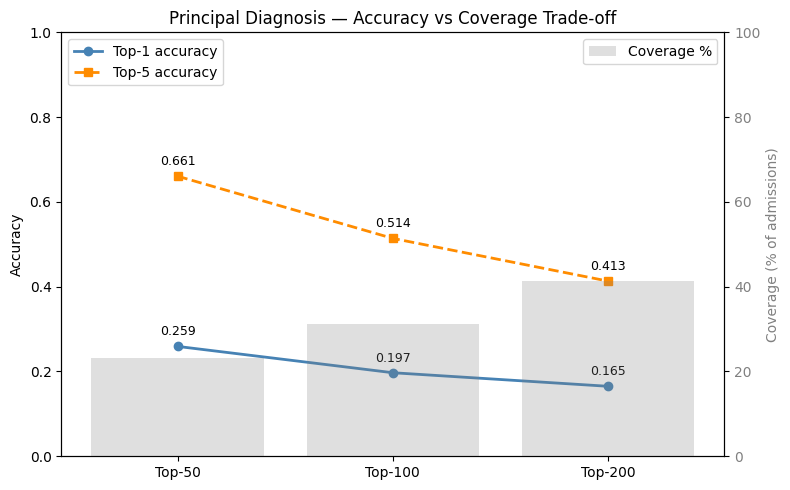

In [44]:
def run_principal_ablation(top_k, num_epochs=15):
    print(f'Principal diagnosis ablation — top-{top_k} codes')
    print('-' * 40)
    PrincipalDiagnosisTask.top_k = top_k
    task = PrincipalDiagnosisTask(dataset)
    tr = task.get_table('train')
    va = task.get_table('val')
    te = task.get_table('test')

    n_adm = db_icd.table_dict['admissions'].df.shape[0]
    lbl = np.full(n_adm, -1, dtype=np.int64)
    for tbl in [tr, va]:
        for _, row in tbl.df.iterrows():
            idx = int(row['hadm_id'])
            if 0 <= idx < n_adm:
                lbl[idx] = int(row['principal_code_idx'])

    n_ts = max(1, task.num_eval_timestamps)
    test_ts = pd.date_range(task.dataset.test_timestamp,
                            periods=n_ts, freq=task.timedelta)
    te_lbl = task.make_table(dataset.get_db(), test_ts)
    for _, row in te_lbl.df.iterrows():
        idx = int(row['hadm_id'])
        if 0 <= idx < n_adm:
            lbl[idx] = int(row['principal_code_idx'])

    labeled = int((lbl >= 0).sum())
    total = n_adm
    coverage = labeled / total

    loaders = build_loaders(g_icd, task, tr, va, te)
    m = Model(data=g_icd, col_stats_dict=stats_icd,
              num_layers=2, channels=best_p_cfg['channels'],
              out_channels=top_k, aggr=['mean', 'min', 'max'],
              norm='batch_norm', dropout=0.3).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=best_p_cfg['lr'], weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    print(f'  labeled={labeled:,} / {total:,}  coverage={coverage:.1%}')
    print(f"ep  loss  val_top1  val_top5")
    print('-' * 32)

    best_top1, best_state = 0.0, None
    for ep in range(1, num_epochs + 1):
        tl = train_principal_epoch(m, loaders['train'], opt, loss_fn, task, lbl, device)
        top1, top5 = eval_principal(m, loaders['val'], task, lbl, device)
        print(f'{ep}  {tl:.4f}  {top1:.4f}  {top5:.4f}')
        if top1 > best_top1:
            best_top1 = top1
            best_state = copy.deepcopy(m.state_dict())

    m.load_state_dict(best_state)
    test_top1, test_top5 = eval_principal(m, loaders['test'], task, lbl, device)
    print(f'test top-1={test_top1:.4f}  top-5={test_top5:.4f}')
    return {
        'top_k': top_k,
        'labeled': labeled,
        'coverage': coverage,
        'test_top1': test_top1,
        'test_top5': test_top5,
    }

res_50  = {'top_k': 50, 'labeled': int((prin_lbl >= 0).sum()),
           'coverage': int((prin_lbl >= 0).sum()) / n_adm_p,
           'test_top1': test_top1, 'test_top5': test_top5}
res_100 = run_principal_ablation(top_k=100, num_epochs=15)
res_200 = run_principal_ablation(top_k=200, num_epochs=15)

PrincipalDiagnosisTask.top_k = 50

print()
print(f"{'top_k':>8}  {'labeled':>10}  {'coverage':>10}  {'top-1':>8}  {'top-5':>8}")
print('-' * 52)
for r in [res_50, res_100, res_200]:
    print(f"{r['top_k']:>8}  {r['labeled']:>10,}  {r['coverage']:>10.1%}  "
          f"{r['test_top1']:>8.4f}  {r['test_top5']:>8.4f}")

import matplotlib.pyplot as plt
import numpy as np

results = [res_50, res_100, res_200]
ks = [r['top_k'] for r in results]
top1s = [r['test_top1'] for r in results]
top5s = [r['test_top5'] for r in results]
coverages = [r['coverage'] * 100 for r in results]

x = np.arange(len(ks))
fig, ax1 = plt.subplots(figsize=(8, 5))

ax2 = ax1.twinx()
ax2.bar(x, coverages, alpha=0.25, color='gray', label='Coverage %')
ax2.set_ylabel('Coverage (% of admissions)', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')
ax2.set_ylim(0, 100)

ax1.plot(x, top1s, 'o-', color='steelblue', lw=2, label='Top-1 accuracy')
ax1.plot(x, top5s, 's--', color='darkorange', lw=2, label='Top-5 accuracy')
for i, (t1, t5) in enumerate(zip(top1s, top5s)):
    ax1.annotate(f'{t1:.3f}', (i, t1), textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
    ax1.annotate(f'{t5:.3f}', (i, t5), textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels([f'Top-{k}' for k in ks])
ax1.set_title('Principal Diagnosis — Accuracy vs Coverage Trade-off')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('principal_dx_ablation.png', dpi=150)
plt.show()

## Ablation: Principal Diagnosis Coverage vs Accuracy Trade-off

Principal diagnosis prediction is a **single-label multi-class** classification task, where each admission is assigned exactly one diagnosis code. I therefore report **top-1** and **top-5 accuracy**, which measure whether the correct diagnosis is the model's highest-ranked prediction or appears among its five highest-ranked predictions, respectively. These metrics are commonly used for multi-class classification and reflect a realistic clinical setting where a clinician may review a shortlist of likely diagnoses.

To evaluate how the model scales with a larger diagnosis space, I trained it to predict the top **50**, **100**, and **200** most frequent principal diagnosis codes.

| Top-K | Admissions Covered | Coverage | Top-1 Accuracy | Top-5 Accuracy |
| ----: | -----------------: | -------: | -------------: | -------------: |
|    50 |             17,898 |    23.1% |         0.2592 |         0.6607 |
|   100 |             24,111 |    31.1% |         0.1971 |         0.5139 |
|   200 |             32,035 |    41.3% |         0.1651 |         0.4132 |

The results show a clear trade-off between coverage and prediction accuracy. Expanding the label space from the top 50 to the top 200 diagnoses increases coverage from **23.1%** to **41.3%**, allowing the model to make predictions for nearly twice as many admissions. However, this comes with a reduction in performance: **top-1 accuracy** decreases from **25.9%** to **16.5%**, while **top-5 accuracy** falls from **66.1%** to **41.3%**.

Despite this decline, the model continues to perform well above chance. With **200** possible classes, a random classifier would achieve a top-1 accuracy of only **0.5%**. Achieving **16.5%** therefore demonstrates that the model is learning meaningful diagnostic patterns even in the larger label space.

The reduction in **top-5 accuracy** is particularly informative, as it reflects the model's ability to produce a useful shortlist of candidate diagnoses. As more diagnosis codes are included, distinguishing between clinically similar conditions becomes increasingly difficult, leading to lower ranking performance. This suggests that the task becomes substantially more challenging as the diagnosis space expands.


### Deep dive, per-class accuracy and confusion analysis

The overall accuracy numbers are useful, but they hide a lot. I want to know which diagnoses the model handles well, which ones it struggles with, and, most importantly, when it's wrong, what does it predict instead.

  Test predictions: (2284, 50)  Labels: (2284,)


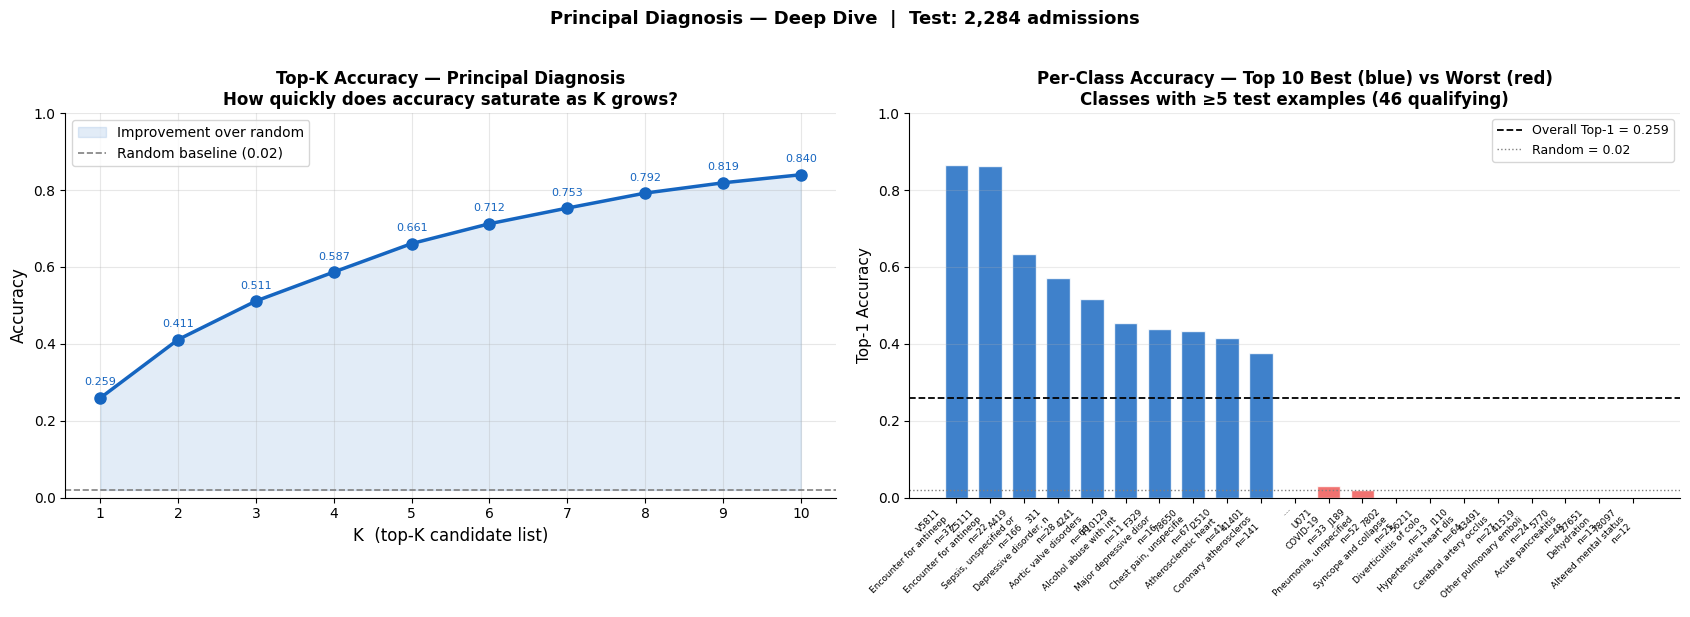

Saved → /kaggle/working/principal_diag_analysis.png 

Per-class accuracy — top-5 best (n_test ≥ 5):
  0.865  [37 samples]  V5811: Encounter for antineoplastic chemotherap
  0.864  [22 samples]  Z5111: Encounter for antineoplastic chemotherap
  0.633  [166 samples]  A419: Sepsis, unspecified organism
  0.571  [28 samples]  311: Depressive disorder, not elsewhere class
  0.517  [60 samples]  4241: Aortic valve disorders

Per-class accuracy — bottom-5 worst (n_test ≥ 5):
  0.000  [27 samples]  43491: Cerebral artery occlusion, unspecified w
  0.000  [24 samples]  41519: Other pulmonary embolism and infarction
  0.000  [48 samples]  5770: Acute pancreatitis
  0.000  [13 samples]  27651: Dehydration
  0.000  [12 samples]  78097: Altered mental status

Top-10 most confused pairs (true → predicted):
  Count  True code  Predicted as
  --------------------------------------------------------------------------------------------------------------
  47  I130: Hypertensive heart and chronic kidney 

In [45]:
import matplotlib.pyplot as plt
from collections import Counter

@torch.no_grad()
def get_test_preds(model, loader, task, labels, device):
    model.eval()
    all_probs, all_targets = [], []
    for batch in loader:
        batch = batch.to(device)
        bs = batch[task.entity_table].batch_size
        logits = model(batch, task.entity_table)[:bs]
        nids = batch[task.entity_table].n_id[:bs].cpu().numpy()
        y = labels[nids]
        valid = y >= 0
        if valid.sum() == 0:
            continue
        probs = torch.softmax(
            logits[torch.from_numpy(valid).to(device)], dim=-1
        ).cpu().numpy()
        all_probs.append(probs)
        all_targets.append(y[valid])
    return np.vstack(all_probs), np.concatenate(all_targets)

P_p, L_p = get_test_preds(
    model_p, ld_p['test'], prin_task, prin_lbl, device)
print(f'  Test predictions: {P_p.shape}  Labels: {L_p.shape}')

max_k = 10
topk_acc = []
for k in range(1, max_k + 1):
    top_k_preds = np.argsort(P_p, axis=1)[:, -k:]
    correct = np.array([L_p[i] in top_k_preds[i] for i in range(len(L_p))])
    topk_acc.append(float(correct.mean()))

pred_top1 = P_p.argmax(axis=1)
class_correct = {}
class_total = {}
for i, true_cls in enumerate(L_p):
    class_total[true_cls]   = class_total.get(true_cls, 0) + 1
    class_correct[true_cls] = class_correct.get(true_cls, 0) + int(pred_top1[i] == true_cls)

classes_reliable = {
    c: class_correct.get(c, 0) / class_total[c]
    for c in class_total if class_total[c] >= 5
}
sorted_cls = sorted(classes_reliable.items(), key=lambda x: x[1], reverse=True)

confusion_pairs = Counter()
for i in range(len(L_p)):
    if pred_top1[i] != L_p[i]:
        confusion_pairs[(int(L_p[i]), int(pred_top1[i]))] += 1

desc_map_p = {}
try:
    d_icd_df = pd.read_csv(os.path.join(base_dir, 'd_icd_diagnoses.csv'),
                            usecols=['icd_code', 'long_title'], low_memory=False)
    desc_map_p = d_icd_df.set_index('icd_code')['long_title'].to_dict()
except Exception as e:
    print(f'Could not load descriptions: {e}')

def code_str(idx, max_len=40):
    code = prin_task.top_codes[idx]
    desc = desc_map_p.get(code, '')[:max_len]
    return f'{code}: {desc}' if desc else code

def short_code(idx, max_len=22):
    code = prin_task.top_codes[idx]
    desc = desc_map_p.get(code, '')[:max_len]
    return f'{code}\n{desc}' if desc else code

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

ax1 = axes[0]
ks = list(range(1, max_k + 1))
ax1.plot(ks, topk_acc, 'o-', color='#1565C0', linewidth=2.5, markersize=8)
ax1.fill_between(ks, [1/top_k_p]*max_k, topk_acc,
                 alpha=0.12, color='#1565C0', label='Improvement over random')
ax1.axhline(1/top_k_p, color='gray', linestyle='--', linewidth=1.2,
            label=f'Random baseline ({1/top_k_p:.2f})')
for k, acc in zip(ks, topk_acc):
    ax1.annotate(f'{acc:.3f}', (k, acc), textcoords='offset points',
                 xytext=(0, 9), ha='center', fontsize=8, color='#1565C0')
ax1.set_xlabel('K  (top-K candidate list)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xticks(ks)
ax1.set_ylim(0, 1.0)
ax1.set_title('Top-K Accuracy — Principal Diagnosis\n'
              'How quickly does accuracy saturate as K grows?',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
N_each = min(10, len(sorted_cls) // 2)
top_n = sorted_cls[:N_each]
bot_n = sorted_cls[-N_each:]


items = top_n + [('sep', -1)] + bot_n
labels_bar = []
vals_bar = []
colors_bar = []
for cls, acc in items:
    if cls == 'sep':
        labels_bar.append('  ···')
        vals_bar.append(0)
        colors_bar.append('white')
    else:
        n = class_total[cls]
        labels_bar.append(short_code(cls) + f'\nn={n}')
        vals_bar.append(acc)
        colors_bar.append('#1565C0' if acc > test_top1 else '#EF5350')

x_pos = range(len(labels_bar))
ax2.bar(x_pos, vals_bar, color=colors_bar, alpha=0.82, edgecolor='white', width=0.7)
ax2.axhline(test_top1, color='black', linestyle='--', linewidth=1.3,
            label=f'Overall Top-1 = {test_top1:.3f}')
ax2.axhline(1/top_k_p, color='gray', linestyle=':', linewidth=1,
            label=f'Random = {1/top_k_p:.2f}')
ax2.set_xticks(list(x_pos))
ax2.set_xticklabels(labels_bar, fontsize=6.5, rotation=45, ha='right')
ax2.set_ylabel('Top-1 Accuracy', fontsize=11)
ax2.set_ylim(0, 1.0)
ax2.set_title('Per-Class Accuracy — Top 10 Best (blue) vs Worst (red)\n'
              f'Classes with ≥5 test examples ({len(classes_reliable)} qualifying)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.25)
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    f'Principal Diagnosis — Deep Dive  |  Test: {len(L_p):,} admissions',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/principal_diag_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → /kaggle/working/principal_diag_analysis.png ')

print()
print(f'Per-class accuracy — top-5 best (n_test ≥ 5):')
for cls, acc in sorted_cls[:5]:
    print(f'  {acc:.3f}  [{class_total[cls]} samples]  {code_str(cls)}')

print(f'\nPer-class accuracy — bottom-5 worst (n_test ≥ 5):')
for cls, acc in sorted_cls[-5:]:
    print(f'  {acc:.3f}  [{class_total[cls]} samples]  {code_str(cls)}')

print(f'\nTop-10 most confused pairs (true → predicted):')
print(f"  Count  True code  Predicted as")
print('  ' + '-'*110)
for (true_cls, pred_cls), count in confusion_pairs.most_common(10):
    print(f'  {count}  {code_str(true_cls)}  {code_str(pred_cls)}')

## Deep Dive: Per-Class Performance and Confusion Analysis

The figure above provides two complementary views of the model's performance. The left panel shows how prediction accuracy changes as the number of allowed predictions (K) increases, while the right panel highlights the best- and worst-performing diagnosis classes.

The top-K accuracy increases from **0.259** for the top prediction to **0.661** by the top five predictions, before beginning to plateau. This suggests that most of the model's predictive information is contained within its first five ranked diagnoses, with relatively little benefit from considering additional candidates.

Performance varies considerably across diagnosis classes. The highest accuracies are achieved for chemotherapy encounter codes (**V58.11** and **Z51.11**), both exceeding **0.86**, likely because these admissions have highly distinctive treatment patterns and laboratory profiles. **Sepsis (A41.9)** also performs well (**0.633**), which is likely influenced by its relatively high frequency in the training data.

In contrast, several diagnoses, including **cerebral artery occlusion**, **pulmonary embolism**, **acute pancreatitis**, **dehydration**, and **altered mental status**, achieve little or no predictive accuracy. These conditions often share similar laboratory values, vital signs, and treatment patterns with more common diagnoses, making them difficult to distinguish using structured EHR data alone.

The confusion matrix supports this interpretation. A common error is the model predicting **sepsis (A41.9)** for patients with other serious conditions, including hypertensive heart disease with chronic kidney disease, acute kidney failure, NSTEMI, pneumonia, and COVID-19. These conditions frequently present with overlapping physiological abnormalities and treatments, making such confusion clinically plausible. Another frequent error occurs between the chest pain codes **786.59** and **786.50**, which represent closely related diagnoses that differ mainly in coding specificity rather than underlying clinical presentation.


## Summary: Results Across All Tasks

The table below summarises the primary test-set results for all prediction tasks evaluated in this study.

| Task                          | Dataset  | Cohort (train / test) | Pos. rate / Coverage | Primary Metric |  Score |
| ----------------------------- | -------- | --------------------: | -------------------: | -------------- | -----: |
| AKI binary                    | eICU     |        35,129 / 7,492 |                14.8% | AUROC          | 0.7399 |
| AKI binary                    | eICU     |        35,129 / 7,492 |                14.8% | AUPRC          | 0.3385 |
| AKI ordinal ≥ Stage 1         | eICU     |        35,129 / 7,492 |                14.8% | AUROC          | 0.7133 |
| AKI ordinal ≥ Stage 2         | eICU     |        35,129 / 7,492 |                 3.0% | AUROC          | 0.7339 |
| AKI ordinal ≥ Stage 3         | eICU     |        35,129 / 7,492 |                 1.8% | AUROC          | 0.7718 |
| Vasopressor (6-hour window)   | eICU     |       99,373 / 20,034 |                 3.4% | AUROC          | 0.8323 |
| Vasopressor (6-hour window)   | eICU     |       99,373 / 20,034 |                 3.4% | AUPRC          | 0.1472 |
| ICD multi-label (Top-50)      | MIMIC-IV |        52,211 / 9,483 |   7.5% label density | Macro-AUROC    | 0.8407 |
| ICD multi-label (Top-50)      | MIMIC-IV |        52,211 / 9,483 |   7.5% label density | Micro-AUROC    | 0.8653 |
| ICD multi-label (Top-100)     | MIMIC-IV |        52,211 / 9,483 |   5.3% label density | Macro-AUROC    | 0.8429 |
| ICD multi-label (Top-200)     | MIMIC-IV |        52,211 / 9,483 |   3.5% label density | Macro-AUROC    | 0.8466 |
| Principal diagnosis (Top-50)  | MIMIC-IV |        12,747 / 2,284 |       23.1% coverage | Top-1 accuracy | 0.2592 |
| Principal diagnosis (Top-50)  | MIMIC-IV |        12,747 / 2,284 |       23.1% coverage | Top-5 accuracy | 0.6607 |
| Principal diagnosis (Top-100) | MIMIC-IV |        12,747 / 2,284 |       31.1% coverage | Top-1 accuracy | 0.1971 |
| Principal diagnosis (Top-100) | MIMIC-IV |        12,747 / 2,284 |       31.1% coverage | Top-5 accuracy | 0.5139 |
| Principal diagnosis (Top-200) | MIMIC-IV |        12,747 / 2,284 |       41.3% coverage | Top-1 accuracy | 0.1651 |
| Principal diagnosis (Top-200) | MIMIC-IV |        12,747 / 2,284 |       41.3% coverage | Top-5 accuracy | 0.4132 |

Overall, the proposed GNN performs consistently well across a range of clinical prediction tasks despite differences in datasets, class imbalance, and prediction objectives. The strongest discrimination is achieved for vasopressor prediction (AUROC **0.8323**), while AKI prediction is more challenging because early kidney injury is more difficult to distinguish from patients who do not develop AKI. On the MIMIC-IV tasks, the model maintains strong performance for multi-label ICD code prediction even as the label space expands from 50 to 200 codes. Principal diagnosis prediction is the most difficult task, reflecting the challenge of identifying a single correct diagnosis from structured EHR data alone without incorporating clinical notes.

**Note on the ICD rows.** These scores come from the model with
`time_col = 'admittime'`, i.e. predicting at admission from demographics,
registration fields and prior hospitalizations.


## Experiment: ICD Prediction with `time_col = 'dischtime'`

The main `ICDTask` uses `time_col = 'admittime'`, so the temporal sampler only
sees events dated at or before admission. This experiment re-runs the identical
pipeline with `time_col = 'dischtime'`, giving the model access to the full
in-stay record. Same graph, same architecture, same hyperparameters, only the
observation window changes. 

In [14]:
class ICDTaskDischtime(ICDTask):
    """
    Identical to ICDTask except time_col = 'dischtime'.
    NeighborLoader will now sample neighbours with timestamp ≤ dischtime,
    giving the model access to the full in-stay record.
    """
    time_col = 'dischtime'

    def __init__(self, *a, **k):
        super().__init__(*a, **k)
        self._raw_adm = pd.read_csv(
            os.path.join(base_dir, 'admissions.csv'),
            usecols=['hadm_id', 'admittime', 'dischtime'])
        self._raw_adm['admittime'] = pd.to_datetime(self._raw_adm['admittime'])
        self._raw_adm['dischtime'] = pd.to_datetime(self._raw_adm['dischtime'])

    def make_table(self, db, timestamps):
        ts_df  = pd.DataFrame({'timestamp': timestamps})
        raw_adm = self._raw_adm
        diag    = self._diag
        df = duckdb.sql("""
            SELECT a.hadm_id  AS hadm_id_orig,
                   a.admittime,
                   a.dischtime
            FROM ts_df t
            JOIN raw_adm a
              ON a.admittime  > t.timestamp
             AND a.admittime <= t.timestamp + INTERVAL '1 DAY'
            WHERE a.hadm_id   IS NOT NULL
              AND a.dischtime IS NOT NULL
        """).df()
        df['admittime'] = pd.to_datetime(df['admittime']).astype('datetime64[ns]')
        df['dischtime'] = pd.to_datetime(df['dischtime']).astype('datetime64[ns]')

        hm = self.dataset.pkey_remaps.get('admissions', (None, {}))[1]
        df['hadm_id'] = df['hadm_id_orig'].map(hm)
        df = df.dropna(subset=['hadm_id'])
        df['hadm_id'] = df['hadm_id'].astype(np.int64)

        dbh = diag.groupby('hadm_id')['icd_code'].apply(list).reset_index()
        df  = df.merge(dbh, left_on='hadm_id_orig', right_on='hadm_id',
                       how='left', suffixes=('', '_d'))
        df['icd_code']  = df['icd_code'].apply(lambda x: x if isinstance(x, list) else [])
        df['icd_label'] = df['icd_code'].apply(lambda x: 1 if len(x) > 0 else 0)

        cm, tk = self.code_map, self.top_k
        def mh(codes):
            v = np.zeros(tk, dtype=np.float32)
            for c in codes:
                if c in cm: v[cm[c]] = 1.0
            return v
        df['icd_multilabel'] = df['icd_code'].apply(mh)

        return Table(
            df=df[['hadm_id', 'admittime', 'dischtime',
                   'icd_label', 'icd_multilabel']],
            fkey_col_to_pkey_table={self.entity_col: self.entity_table},
            pkey_col=None,
            time_col=self.time_col)   

icd_task_disch = ICDTaskDischtime(dataset)
print(icd_task_disch)

Top-50 ICD codes loaded. Most common: ['4019', 'E785', 'I10', '2724', 'Z87891']
ICDTaskDischtime(dataset=MimicDataset())


In [15]:
tr_icd_d = icd_task_disch.get_table('train')
va_icd_d = icd_task_disch.get_table('val')
te_icd_d = icd_task_disch.get_table('test')

tr_df = tr_icd_d.df[tr_icd_d.df['dischtime'] < dataset.val_timestamp]
va_df = va_icd_d.df[va_icd_d.df['dischtime'] < dataset.test_timestamp]
print(f'Guard band dropped: train {len(tr_icd_d.df) - len(tr_df):,}, '
      f'val {len(va_icd_d.df) - len(va_df):,}')

tr_icd_d = Table(df=tr_df.reset_index(drop=True),
                 fkey_col_to_pkey_table=tr_icd_d.fkey_col_to_pkey_table,
                 pkey_col=None, time_col='dischtime')
va_icd_d = Table(df=va_df.reset_index(drop=True),
                 fkey_col_to_pkey_table=va_icd_d.fkey_col_to_pkey_table,
                 pkey_col=None, time_col='dischtime')

print(f'Train: {len(tr_icd_d.df):,}  | Val: {len(va_icd_d.df):,}  | Test: {len(te_icd_d.df):,}')
print(f'time_col in train table: {tr_icd_d.time_col}')
print(f'Avg ICD codes/admission (train): '
      f'{tr_icd_d.df["icd_multilabel"].apply(sum).mean():.2f}')

Making task table for train split from scratch...
Done in 8.01 seconds.
Making task table for val split from scratch...
Done in 8.14 seconds.
Making task table for test split from scratch...
Done in 8.25 seconds.
Guard band dropped: train 18, val 14
Train: 52,193  | Val: 11,702  | Test: 9,483
time_col in train table: dischtime
Avg ICD codes/admission (train): 3.94


One detail on the split: admissions are assigned to train/val/test by
admission time, but this experiment seeds the sampler at discharge time, so an
admission near a split boundary could otherwise pull in context from just past
the cutoff. I therefore drop any training row whose discharge falls after the
validation timestamp (and any validation row past the test timestamp). This
removed only 18 training and 14 validation admissions, so the cohort is
essentially unchanged, but it guarantees no training example sees data from
the validation period.

In [16]:
n_adm_d   = db_icd.table_dict['admissions'].df.shape[0]
lbl_mat_d = np.zeros((n_adm_d, icd_task_disch.top_k), dtype=np.float32)

for t in [tr_icd_d, va_icd_d]:
    for _, row in t.df.iterrows():
        idx = int(row['hadm_id'])
        if 0 <= idx < n_adm_d:
            lbl_mat_d[idx] = row['icd_multilabel']

n_ts_d   = max(1, icd_task_disch.num_eval_timestamps)
test_ts_d = pd.date_range(icd_task_disch.dataset.test_timestamp,
                           periods=n_ts_d, freq=icd_task_disch.timedelta)
te_icd_d_lbl = icd_task_disch.make_table(dataset.get_db(), test_ts_d)
for _, row in te_icd_d_lbl.df.iterrows():
    idx = int(row['hadm_id'])
    if 0 <= idx < n_adm_d:
        lbl_mat_d[idx] = row['icd_multilabel']
lbl_mat_d = np.clip(lbl_mat_d, 0, 1)

print(f'Label matrix shape : {lbl_mat_d.shape}')
print(f'Label density      : {lbl_mat_d.mean():.3%}')

icd_ld_d = build_loaders(g_icd, icd_task_disch, tr_icd_d, va_icd_d, te_icd_d)
print(f'Batches — train: {len(icd_ld_d["train"])}  '
      f'val: {len(icd_ld_d["val"])}  '
      f'test: {len(icd_ld_d["test"])}')

Label matrix shape : (77526, 50)
Label density      : 7.473%
Batches — train: 102  val: 23  test: 19


In [17]:
make_reproducible(42)

best_cfg = {
    'pos_weight_val': 10.0,
    'lr':             3e-4,
    'channels':       256,
}

pos_weight_d = torch.full(
    (icd_task_disch.top_k,), best_cfg['pos_weight_val'],
    dtype=torch.float32).to(device)

model_icd_d = Model(
    data=g_icd, col_stats_dict=stats_icd, num_layers=2,
    channels=best_cfg['channels'], out_channels=icd_task_disch.top_k,
    aggr=['mean', 'min', 'max'], norm='batch_norm', dropout=0.3).to(device)

optimizer_icd_d = torch.optim.Adam(
    model_icd_d.parameters(), lr=best_cfg['lr'], weight_decay=1e-4)
loss_fn_icd_d = nn.BCEWithLogitsLoss(pos_weight=pos_weight_d)

print(f'model params : {sum(p.numel() for p in model_icd_d.parameters()):,}')
print(f'channels     : {best_cfg["channels"]}')
print(f'pos_weight   : {best_cfg["pos_weight_val"]}')
print(f'lr           : {best_cfg["lr"]}')
print()

best_val_d, best_state_d = 0.0, None

print(f"ep   loss      val_auc   val_auprc")
print('-' * 38)

for ep in range(1, n_epochs + 1):
    tl = train_epoch(model_icd_d, icd_ld_d['train'],
                     optimizer_icd_d, loss_fn_icd_d,
                     icd_task_disch, lbl_mat_d, device)
    va, va_prc = eval_metrics(model_icd_d, icd_ld_d['val'],
                              icd_task_disch, lbl_mat_d, device)
    print(f'{ep:<4} {tl:>8.4f}  {va:>8.4f}  {va_prc:>10.4f}')
    if va > best_val_d:
        best_val_d   = va
        best_state_d = copy.deepcopy(model_icd_d.state_dict())

print(f'\nBest Val AUROC (dischtime) : {best_val_d:.4f}')

model params : 16,634,546
channels     : 256
pos_weight   : 10.0
lr           : 0.0003

ep   loss      val_auc   val_auprc
--------------------------------------


1      0.9320    0.8143      0.2221


2      0.7871    0.8330      0.2457


3      0.7451    0.8466      0.2693


4      0.7151    0.8527      0.2824


...

16     0.6297    0.8633      0.3102


17     0.6269    0.8645      0.3105


18     0.6217    0.8637      0.3117


19     0.6171    0.8644      0.3116


20     0.6130    0.8625      0.3101

Best Val AUROC (dischtime) : 0.8645


In [18]:
from sklearn.metrics import f1_score as sk_f1

@torch.no_grad()
def full_metrics(model, loader, task, lbl_mat, device, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        bs = batch[task.entity_table].batch_size
        probs = torch.sigmoid(
            model(batch, task.entity_table)[:bs]).cpu().numpy()
        nids = batch[task.entity_table].n_id[:bs].cpu().numpy()
        all_probs.append(probs); all_labels.append(lbl_mat[nids])
    P = np.vstack(all_probs)
    L = np.vstack(all_labels)
    valid = []
    for c in range(L.shape[1]):
        if L[:, c].sum() > 0:
            valid.append(c)
    Lv, Pv = L[:, valid], P[:, valid]
    per_auroc = [roc_auc_score(Lv[:, i], Pv[:, i]) for i in range(len(valid))]
    per_auprc = [average_precision_score(Lv[:, i], Pv[:, i]) for i in range(len(valid))]
    Pbin = (P >= threshold).astype(int)
    code_aurocs = sorted(zip(valid, per_auroc), key=lambda x: x[1])
    return {
        'macro_auroc': float(np.mean(per_auroc)),
        'micro_auroc': float(roc_auc_score(Lv, Pv, average='micro')),
        'macro_auprc': float(np.mean(per_auprc)),
        'macro_f1':    float(sk_f1(L, Pbin, average='macro',   zero_division=0)),
        'micro_f1':    float(sk_f1(L, Pbin, average='micro',   zero_division=0)),
        'sample_f1':   float(sk_f1(L, Pbin, average='samples', zero_division=0)),
        'good_codes':  sum(1 for a in per_auroc if a > 0.75),
        'n_valid':     len(valid),
        'best5':       code_aurocs[-5:][::-1],
        'worst5':      code_aurocs[:5],
    }

In [19]:
model_icd_d.load_state_dict(best_state_d)
m_d = full_metrics(model_icd_d, icd_ld_d['test'],
                   icd_task_disch, lbl_mat_d, device)

print(f'--- ICD prediction with dischtime (top-{icd_task_disch.top_k}) ---')
print(f'macro-AUROC = {m_d["macro_auroc"]:.4f}   '
      f'micro-AUROC = {m_d["micro_auroc"]:.4f}')
print(f'macro-AUPRC = {m_d["macro_auprc"]:.4f}')
print(f'macro-F1    = {m_d["macro_f1"]:.4f}  (at t=0.5)')
print(f'Codes with AUROC > 0.75 : {m_d["good_codes"]} / {m_d["n_valid"]}')

--- ICD prediction with dischtime (top-50) ---
macro-AUROC = 0.8632   micro-AUROC = 0.8855
macro-AUPRC = 0.3138
macro-F1    = 0.3424  (at t=0.5)
Codes with AUROC > 0.75 : 50 / 50


In [20]:
@torch.no_grad()
def get_probs_for_task(model, loader, task, lbl_mat, device):
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        bs    = batch[task.entity_table].batch_size
        probs = torch.sigmoid(
            model(batch, task.entity_table)[:bs]).cpu().numpy()
        nids  = batch[task.entity_table].n_id[:bs].cpu().numpy()
        all_probs.append(probs)
        all_labels.append(lbl_mat[nids])
    return np.vstack(all_probs), np.vstack(all_labels)

val_probs_d,  val_labels_d  = get_probs_for_task(
    model_icd_d, icd_ld_d['val'],  icd_task_disch, lbl_mat_d, device)
test_probs_d, test_labels_d = get_probs_for_task(
    model_icd_d, icd_ld_d['test'], icd_task_disch, lbl_mat_d, device)

thresholds = np.arange(0.05, 0.61, 0.01)
best_t_d, best_f1_d = 0.5, 0.0
for t in thresholds:
    preds_bin = (val_probs_d >= t).astype(int)
    f1 = sk_f1(val_labels_d, preds_bin, average='macro', zero_division=0)
    if f1 > best_f1_d:
        best_f1_d = f1
        best_t_d  = t

test_bin_d       = (test_probs_d >= best_t_d).astype(int)
test_macro_f1_d  = sk_f1(test_labels_d, test_bin_d, average='macro',   zero_division=0)
test_micro_f1_d  = sk_f1(test_labels_d, test_bin_d, average='micro',   zero_division=0)
test_sample_f1_d = sk_f1(test_labels_d, test_bin_d, average='samples', zero_division=0)

print(f'Best threshold (val macro-F1) : {best_t_d:.2f}')
print(f'Val macro-F1 at threshold     : {best_f1_d:.4f}')
print()
print(f'--- Test results at t={best_t_d:.2f} (dischtime) ---')
print(f'macro-F1  : {test_macro_f1_d:.4f}')
print(f'micro-F1  : {test_micro_f1_d:.4f}')
print(f'sample-F1 : {test_sample_f1_d:.4f}')


print()
print(f'{"Metric":<24} {"admittime (original)":>22} {"dischtime (experiment)":>24}')
print('─' * 72)

orig = dict(macro_auroc=0.8407, micro_auroc=0.8653,
            macro_auprc=0.2708, macro_f1=0.3229, threshold=0.59)
print(f'{"Macro-AUROC":<24} {orig["macro_auroc"]:>22.4f} {m_d["macro_auroc"]:>24.4f}')
print(f'{"Micro-AUROC":<24} {orig["micro_auroc"]:>22.4f} {m_d["micro_auroc"]:>24.4f}')
print(f'{"Macro-AUPRC":<24} {orig["macro_auprc"]:>22.4f} {m_d["macro_auprc"]:>24.4f}')
print(f'{"Macro-F1 (tuned thr.)":<24} {orig["macro_f1"]:>22.4f} {test_macro_f1_d:>24.4f}')
print(f'{"Best threshold":<24} {orig["threshold"]:>22.2f} {best_t_d:>24.2f}')
print(f'{"Codes AUROC > 0.75":<24} {"50/50":>22} '
      f'{m_d["good_codes"]}/{m_d["n_valid"]:>22}')
print()
print('Δ Macro-AUROC (dischtime − admittime): '
      f'{m_d["macro_auroc"] - orig["macro_auroc"]:+.4f}')

Best threshold (val macro-F1) : 0.60
Val macro-F1 at threshold     : 0.3542

--- Test results at t=0.60 (dischtime) ---
macro-F1  : 0.3578
micro-F1  : 0.4017
sample-F1 : 0.3619

Metric                     admittime (original)   dischtime (experiment)
────────────────────────────────────────────────────────────────────────
Macro-AUROC                              0.8407                   0.8632
Micro-AUROC                              0.8653                   0.8855
Macro-AUPRC                              0.2708                   0.3138
Macro-F1 (tuned thr.)                    0.3229                   0.3578
Best threshold                             0.59                     0.60
Codes AUROC > 0.75                        50/50 50/                    50

Δ Macro-AUROC (dischtime − admittime): +0.0225


## Correction and Experiment: What Time Window Does the ICD Model Actually Use?

### The mistake in my original description

In my original description of this task I wrote that the model predicts the
discharge codes "given everything recorded during the hospital stay". During
the review it was pointed out to me that this is not what my code actually
does. In the `ICDTask` definition I set `time_col = 'admittime'`, and the
temporal sampler only lets the model see events dated at or before the
prediction time. Since all the in-stay events (labs, procedures, transfers)
are dated after admission, they were all being filtered out. So my model was
really predicting the discharge codes using only what is known at the moment
of admission: demographics, the admission-registration fields, and the
patient's records from previous hospitalizations. My description did not match
my code, and I want to correct that here.

### The experiment

The review did not ask me to re-run anything for this point, only to
double-check it. But once I understood the issue I wanted to know how much
difference the in-stay data actually makes. So I re-ran the exact same
pipeline with `time_col = 'dischtime'`, which lets the sampler see everything
up to the moment of discharge, the full stay including all in-stay labs and
procedures. Everything else is identical: same graph, same architecture, same
hyperparameters from the grid search.

| Metric               | admittime (original) | dischtime (full stay) |
| -------------------- | -------------------: | --------------------: |
| Macro-AUROC          |               0.8407 |                0.8632 |
| Micro-AUROC          |               0.8653 |                0.8855 |
| Macro-AUPRC          |               0.2708 |                0.3138 |
| Macro-F1 (tuned thr) |               0.3229 |                0.3578 |

Seeing the full stay helps, and it helps most on the precision-style metrics:
macro-AUPRC improves by about 16% relative, while AUROC only moves by ~0.02.

### So why was the admission-only model already at 0.84?

First, the labels. When I print the most common codes in my top-50, the top
five are 4019 and I10 (both hypertension), E785 and 2724 (both
hyperlipidemia), and Z87891 (history of nicotine dependence). These are
chronic conditions, they describe who the patient already is when they arrive,
not what happens during the stay. Age, gender, insurance and admission type
already carry a lot of this signal, for example an elderly patient on Medicare
is very likely to receive a hypertension code.

Second, patient history. The temporal filter only blocks events dated after
the current admission, so for readmitted patients all their old labs,
procedures and ICU stays from earlier hospitalizations are still visible.
Chronic codes repeat from one admission to the next, so the model can almost
read the answer from the patient's past record.

Third, the metric. AUROC only measures ranking, whether patients with a code
score higher than patients without it, and demographic signals are enough to
rank well. The harder metrics show the limitation: at admission time the
macro-AUPRC is only 0.2708. So the model ranked plausibly but was not precise
about which codes an admission would actually get.

Putting it together: the 0.84 was real, but it mostly reflects how predictable
chronic comorbidity codes are from demographics and history. The in-stay data
is what's needed for the acute codes, which is exactly where the dischtime
model gains the most.